# (LoL) League of Legends Ranked Games dataset

# Обзор данных и импорт библиотек

In [1]:
import copy
import itertools
import json
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ppscore as pps
import seaborn as sns
import torch
import torch.nn as nn

from roleidentification.pull_data import pull_data

from catboost import CatBoostClassifier
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df_train = pd.read_csv('train_games.csv')
df_test = pd.read_csv('test_games.csv')

In [3]:
df_train.head()

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3288673013,1501747504539,1677,9,2,2,2,2,0,2,2,24,4,11,412,4,3,222,7,4,86,12,4,161,21,4,3,0,0,0,0,23,114,37,75,122,17,21,4,498,7,4,89,4,14,5,11,6,61,4,21,10,3,0,3,1,11,31,119,67,84
1,3317415962,1503621554430,1223,9,1,1,1,0,0,2,0,81,4,7,266,12,4,16,3,4,105,4,11,91,4,14,5,0,0,0,0,164,53,29,45,75,157,4,14,22,4,7,516,4,3,6,4,12,64,4,11,0,0,0,1,0,1,238,40,498,31
2,3314564201,1503450068171,1371,9,2,2,1,2,0,2,2,202,7,4,420,12,4,34,14,4,412,4,14,35,14,11,1,0,0,0,0,122,117,1,38,40,16,3,4,157,4,12,29,4,7,32,4,11,17,4,14,8,1,0,2,1,31,113,40,12,53
3,3327787390,1504386055134,1607,9,1,1,1,1,0,1,0,412,3,4,86,4,12,24,4,11,29,4,7,7,4,12,11,3,0,2,0,25,157,11,122,53,238,4,14,104,4,11,516,12,3,18,4,7,44,4,3,0,0,0,0,0,17,103,23,5,91
4,3282510121,1501320968970,1414,9,1,2,1,1,0,1,0,23,4,14,17,3,4,111,6,11,134,4,14,202,7,4,11,3,0,1,0,157,64,67,38,122,81,4,7,24,4,12,223,3,4,56,4,11,50,14,4,0,0,0,0,0,64,157,122,6,119


In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 40842 entries, 0 to 40841
Data columns (total 61 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   gameId              40842 non-null  int64
 1   creationTime        40842 non-null  int64
 2   gameDuration        40842 non-null  int64
 3   seasonId            40842 non-null  int64
 4   winner              40842 non-null  int64
 5   firstBlood          40842 non-null  int64
 6   firstTower          40842 non-null  int64
 7   firstInhibitor      40842 non-null  int64
 8   firstBaron          40842 non-null  int64
 9   firstDragon         40842 non-null  int64
 10  firstRiftHerald     40842 non-null  int64
 11  t1_champ1id         40842 non-null  int64
 12  t1_champ1_sum1      40842 non-null  int64
 13  t1_champ1_sum2      40842 non-null  int64
 14  t1_champ2id         40842 non-null  int64
 15  t1_champ2_sum1      40842 non-null  int64
 16  t1_champ2_sum2      40842 non-null  int64
 17  t1_c

In [5]:
df_train.describe().round(2)

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
count,4.084200e+04,4.084200e+04,40842.00,40842.0,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00,40842.00
mean,3.306022e+09,1.502912e+12,1832.56,9.0,1.49,1.47,1.45,1.31,0.92,1.44,0.73,114.59,6.60,7.31,117.64,6.54,7.20,116.98,6.53,7.22,117.32,6.54,7.22,114.55,6.61,7.27,5.71,1.02,0.37,1.39,0.25,108.60,108.80,108.28,107.72,109.39,115.75,6.60,7.30,117.02,6.54,7.23,117.66,6.52,7.25,118.12,6.53,7.20,116.26,6.61,7.23,5.53,0.98,0.41,1.40,0.24,107.87,108.26,108.94,108.76,108.39
std,2.958810e+07,1.986366e+09,510.96,0.0,0.50,0.52,0.54,0.68,0.84,0.57,0.82,119.19,4.02,4.29,123.39,3.98,4.22,122.90,3.96,4.26,122.63,3.96,4.24,120.11,4.02,4.26,3.80,1.26,0.58,1.21,0.43,102.63,103.25,102.45,102.62,102.67,121.79,4.03,4.28,122.41,3.98,4.26,123.12,3.97,4.26,124.12,3.95,4.24,122.67,4.01,4.25,3.86,1.25,0.61,1.22,0.43,102.11,103.19,102.64,103.34,102.67
min,3.214824e+09,1.496892e+12,190.00,9.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,-1.00,-1.00,-1.00,-1.00,-1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,-1.00,-1.00,-1.00,-1.00,-1.00
25%,3.291882e+09,1.501968e+12,1531.00,9.0,1.00,1.00,1.00,1.00,0.00,1.00,0.00,35.00,4.00,4.00,35.00,4.00,4.00,35.00,4.00,4.00,36.00,4.00,4.00,35.00,4.00,4.00,2.00,0.00,0.00,0.00,0.00,38.00,37.00,37.00,38.00,38.00,35.00,4.00,4.00,35.25,4.00,4.00,36.00,4.00,4.00,35.00,4.00,4.00,35.00,4.00,4.00,2.00,0.00,0.00,0.00,0.00,38.00,38.00,38.00,38.00,38.00
50%,3.319894e+09,1.503840e+12,1833.00,9.0,1.00,1.00,1.00,1.00,1.00,1.00,0.00,79.00,4.00,4.00,79.00,4.00,4.00,78.00,4.00,4.00,79.00,4.00,4.00,78.00,4.00,4.00,6.00,1.00,0.00,1.00,0.00,90.00,90.00,90.00,90.00,91.00,78.00,4.00,4.00,79.00,4.00,4.00,79.00,4.00,4.00,79.00,4.00,4.00,78.00,4.00,4.00,6.00,0.00,0.00,1.00,0.00,90.00,90.00,90.00,90.00,90.00
75%,3.327021e+09,1.504350e+12,2148.00,9.0,2.00,2.00,2.00,2.00,2.00,2.00,1.00,139.75,11.00,11.00,141.00,11.00,11.00,141.00,11.00,11.00,141.00,11.00,11.00,134.00,11.00,11.00,9.00,2.00,1.00,2.00,1.00,141.00,141.00,141.00,141.00,141.00,141.00,11.00,11.00,141.00,11.00,11.00,141.00,11.00,11.00,141.00,11.00,11.00,141.00,11.00,11.00,9.00,2.00,1.00,2.00,0.00,141.00,141.00,141.00,141.00,141.00
max,3.331831e+09,1.504707e+12,4728.00,9.0,2.00,2.00,2.00,2.00,2.00,2.00,2.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,11.00,10.00,5.00,6.00,1.00,516.00,516.00,516.00,516.00,516.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,11.00,10.00,4.00,6.00,1.00,516.00,516.00,516.00,516.00,516.00


Целевая переменная `winner` принимает два значения - `1` и `2`, соответствующие победе первой или второй команды. Поэтому задача является бинарной классификацией.

**Выводы:**
- Пропуски в данных отсутсвуют
- В банах персонажей присутсвует id -1, вероятнее всего это отсутсвие бана, т.к. в пиках такого id нет.
- Признаки `gameId`, `creationTime` и `seasonId` не несут в себе полезной информации, т.к. 1 лишь идентификатор матча, и у каждого он уникален. 2 могло бы нести в себе полезную информормаию если бы мы знали, что то о самих игроках, хотя бы их регион проживания. 3 имеет одно и то же значения для всех игр, т.к. статисика бралась за один сезон.
- Признаки пика персонажей задам как отдельный признак для каждого героя, со значением его пика командой 1, 2 или наоборот отсуствие персонажа в матче. Изначальные же признаки я уберу, т.к. они содержат ту же информацию, что и новые.
- С баном тоже самое, что и с пиком. Но стоит проверить, есть ли смысл в информации о том, какая команда банила героя.
- Для команд нужно сделать отдельные признаки наличия героев для определенных позиций, то есть присутсивует ли в команде персонаж для роли лесника и тд. Конечно это не будет означать, что этот человек обязательно играет на этой роли, но сам факт наличия всех видов ролей в команде должен повышать шанс на ее победу.
- Со спелами то же самое, для каждой роли есть конкретный важный спел, так что можно пометить его наличие. Это важно т.к. сами названия героев и спелов ничего не говорят модели, ифнормации о пикрейте героев или их винрейте нет в датасете.
- Также важно, из за того что некоторые герои могут покрывать разные роли и каждый герой берет по 2 спела, определить, что набор персонажей и спелов у игроков покрывает 5 ролей в отдельности на игрока, а не так что, один игрок покрывает 2 роли.
- Из признаков количества убийств драконов, баронов и т.д. нужно вынести их общее число на обе команды, посичтать разницу в этих признаках между конмадами, как относительную, так и абсолютную.
- Данный датасет содержит в себе часть значений, полученных уже в конце игры, такие как общее число убитых драконов, башен и т.д. Конечно это не все возможные признаки которые существуют в игре, но их наличие должно сильно упрощать предсказание, а в каком то смысле предсказания может и не быть, т.к. набор этих признаков может прямо указывать на победу той или иной команды. Поэтому нужно проверить модели отдельно на всех признаках и на признаках, которые доступны только ближе к началу матча.


# Поиск выбросов, пропусков и т.п.

In [6]:
df_train.duplicated().sum()

np.int64(0)

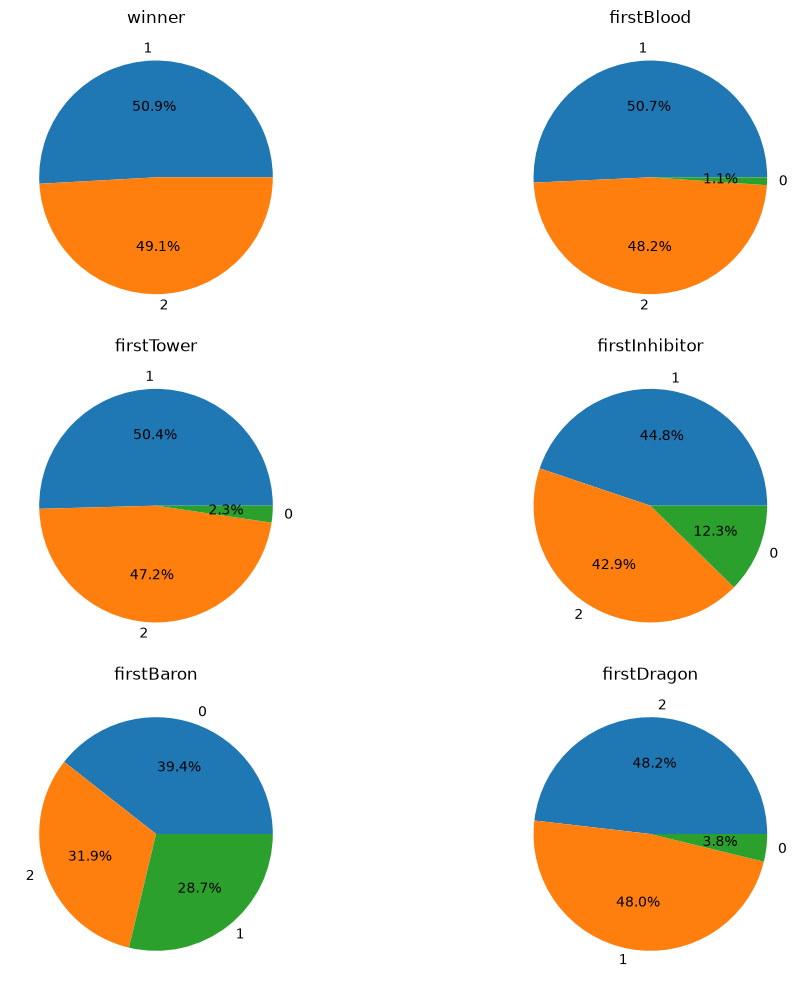

In [7]:
first_features = [
    col for col in df_train.columns
    if 'first' in col or 'winner' in col
]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for col, ax in zip(first_features, axes.flatten()):
    df_train[col].value_counts().plot.pie(
        ax=ax, 
        autopct='%1.1f%%'
    )
    ax.set_title(col)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [8]:
for col in ['firstTower', 'firstBlood']:
    print(f'\n{col}')
    display(df_train[df_train[col] == 0].describe().round(2))


firstTower


,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
count,9.500000e+02,9.500000e+02,950.00,950.0,950.00,950.00,950.0,950.0,950.0,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.0,950.0,950.0,950.00,950.0,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.0,950.0,950.0,950.00,950.00,950.00,950.00,950.00,950.00,950.00
mean,3.304282e+09,1.502796e+12,211.65,9.0,1.48,0.81,0.0,0.0,0.0,0.01,0.00,112.31,6.83,7.24,114.10,6.94,6.95,120.32,6.47,7.21,115.16,6.47,7.27,119.34,6.57,7.26,0.0,0.0,0.0,0.01,0.0,111.79,109.58,114.51,107.24,112.78,117.03,6.70,7.22,118.25,6.57,7.22,111.02,6.42,7.48,124.53,6.34,7.14,111.23,6.39,7.54,0.0,0.0,0.0,0.00,0.00,108.92,111.98,110.04,107.59,108.06
std,3.092328e+07,2.073556e+09,97.18,0.0,0.50,0.83,0.0,0.0,0.0,0.15,0.06,111.80,4.10,4.30,119.26,4.26,4.02,123.24,3.83,4.22,120.55,3.90,4.31,123.21,3.91,4.39,0.0,0.0,0.0,0.10,0.0,107.06,101.55,96.91,103.01,102.43,123.26,4.01,4.25,126.52,4.09,4.18,118.41,3.83,4.44,130.97,3.76,4.07,121.00,3.86,4.45,0.0,0.0,0.0,0.06,0.03,100.95,104.97,94.58,101.55,100.87
min,3.215045e+09,1.496919e+12,190.00,9.0,1.00,0.00,0.0,0.0,0.0,0.00,0.00,1.00,1.00,1.00,1.00,3.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.0,0.0,0.0,0.00,0.0,-1.00,-1.00,-1.00,-1.00,-1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.0,0.0,0.0,0.00,0.00,-1.00,-1.00,-1.00,-1.00,-1.00
25%,3.288222e+09,1.501701e+12,195.00,9.0,1.00,0.00,0.0,0.0,0.0,0.00,0.00,38.00,4.00,4.00,32.25,4.00,4.00,35.25,4.00,4.00,35.00,4.00,4.00,35.00,4.00,4.00,0.0,0.0,0.0,0.00,0.0,38.00,39.00,51.00,39.00,40.00,34.00,4.00,4.00,33.25,4.00,4.00,31.25,4.00,4.00,33.00,4.00,4.00,33.25,4.00,4.00,0.0,0.0,0.0,0.00,0.00,38.00,39.00,40.25,40.00,40.00
50%,3.319385e+09,1.503777e+12,198.00,9.0,1.00,1.00,0.0,0.0,0.0,0.00,0.00,79.50,4.00,4.00,77.00,4.00,4.00,80.50,4.00,4.00,78.00,4.00,4.00,84.00,4.00,4.00,0.0,0.0,0.0,0.00,0.0,90.00,91.00,105.00,89.00,103.00,79.00,4.00,4.00,77.50,4.00,4.00,75.00,4.00,4.00,79.00,4.00,4.00,69.00,4.00,4.00,0.0,0.0,0.0,0.00,0.00,91.50,98.50,103.00,90.00,92.00
75%,3.326350e+09,1.504295e+12,203.00,9.0,2.00,2.00,0.0,0.0,0.0,0.00,0.00,135.50,11.00,11.00,136.00,11.00,11.00,150.00,11.00,11.00,141.00,11.00,11.00,142.50,11.00,11.00,0.0,0.0,0.0,0.00,0.0,141.00,141.00,154.00,139.25,141.00,139.75,11.00,11.00,141.00,11.00,11.00,125.00,11.00,12.00,150.00,11.00,11.00,122.00,11.00,12.00,0.0,0.0,0.0,0.00,0.00,141.00,141.00,141.00,141.00,141.00
max,3.331545e+09,1.504660e+12,1281.00,9.0,2.00,2.00,0.0,0.0,0.0,2.00,2.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,0.0,0.0,0.0,2.00,0.0,516.00,516.00,516.00,516.00,516.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,0.0,0.0,0.0,1.00,1.00,516.00,516.00,516.00,516.00,516.00



firstBlood


,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
count,4.380000e+02,4.380000e+02,438.00,438.0,438.00,438.0,438.0,438.0,438.0,438.0,438.0,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.0,438.0,438.0,438.0,438.0,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.00,438.0,438.0,438.0,438.00,438.0,438.00,438.00,438.00,438.00,438.00
mean,3.302895e+09,1.502703e+12,199.00,9.0,1.46,0.0,0.0,0.0,0.0,0.0,0.0,112.29,6.63,7.34,115.58,6.90,7.02,111.69,6.31,7.16,111.74,6.65,7.04,115.35,6.55,7.05,0.0,0.0,0.0,0.0,0.0,120.26,108.05,116.14,107.36,114.21,111.94,6.44,7.38,125.63,6.75,7.06,119.96,6.26,7.25,118.24,6.40,7.14,111.75,6.24,7.86,0.0,0.0,0.0,0.00,0.0,106.23,117.02,112.45,106.46,101.84
std,3.149987e+07,2.111446e+09,6.02,0.0,0.50,0.0,0.0,0.0,0.0,0.1,0.0,113.17,4.10,4.36,121.39,4.26,4.04,111.04,3.76,4.18,120.41,3.93,4.11,115.94,3.95,4.26,0.0,0.0,0.0,0.0,0.0,114.06,93.82,91.03,103.28,97.16,120.55,3.81,4.29,131.95,4.11,4.08,129.55,3.57,4.31,126.27,3.73,4.00,121.73,3.79,4.55,0.0,0.0,0.0,0.05,0.0,102.80,107.40,95.89,100.99,93.37
min,3.215045e+09,1.496919e+12,191.00,9.0,1.00,0.0,0.0,0.0,0.0,0.0,0.0,5.00,3.00,1.00,1.00,3.00,1.00,1.00,3.00,1.00,1.00,3.00,1.00,1.00,1.00,1.00,0.0,0.0,0.0,0.0,0.0,-1.00,-1.00,-1.00,-1.00,1.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00,3.00,1.00,3.00,1.00,1.00,1.00,1.00,0.0,0.0,0.0,0.00,0.0,-1.00,-1.00,-1.00,-1.00,-1.00
25%,3.283939e+09,1.501418e+12,195.00,9.0,1.00,0.0,0.0,0.0,0.0,0.0,0.0,37.00,4.00,4.00,33.25,4.00,4.00,38.00,4.00,4.00,35.00,4.00,4.00,37.00,4.00,4.00,0.0,0.0,0.0,0.0,0.0,40.00,38.00,53.00,40.00,40.00,33.00,4.00,4.00,35.00,4.00,4.00,35.00,4.00,4.00,31.00,4.00,4.00,36.25,4.00,4.00,0.0,0.0,0.0,0.00,0.0,39.25,40.00,51.00,38.00,38.00
50%,3.318794e+09,1.503735e+12,197.00,9.0,1.00,0.0,0.0,0.0,0.0,0.0,0.0,75.50,4.00,4.00,79.00,4.00,4.00,78.50,4.00,4.00,75.50,4.00,4.00,82.00,4.00,4.00,0.0,0.0,0.0,0.0,0.0,105.00,103.00,114.00,85.00,105.00,75.00,4.00,4.00,82.50,4.00,4.00,75.00,4.00,4.00,79.00,4.00,4.00,69.00,4.00,7.00,0.0,0.0,0.0,0.00,0.0,84.00,104.00,105.00,89.00,90.00
75%,3.326331e+09,1.504293e+12,202.00,9.0,2.00,0.0,0.0,0.0,0.0,0.0,0.0,141.00,11.00,11.00,141.00,11.00,11.00,141.00,7.00,11.00,125.75,11.00,11.00,141.00,11.00,11.00,0.0,0.0,0.0,0.0,0.0,154.00,141.00,157.00,139.25,154.00,118.50,11.00,11.00,142.50,11.00,11.00,141.00,7.00,11.00,139.75,11.00,11.00,125.00,7.00,12.00,0.0,0.0,0.0,0.00,0.0,141.00,150.00,141.00,134.00,122.00
max,3.331545e+09,1.504660e+12,227.00,9.0,2.00,0.0,0.0,0.0,0.0,2.0,0.0,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,0.0,0.0,0.0,0.0,0.0,516.00,516.00,516.00,516.00,516.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,516.00,21.00,21.00,0.0,0.0,0.0,1.00,0.0,516.00,516.00,516.00,516.00,516.00


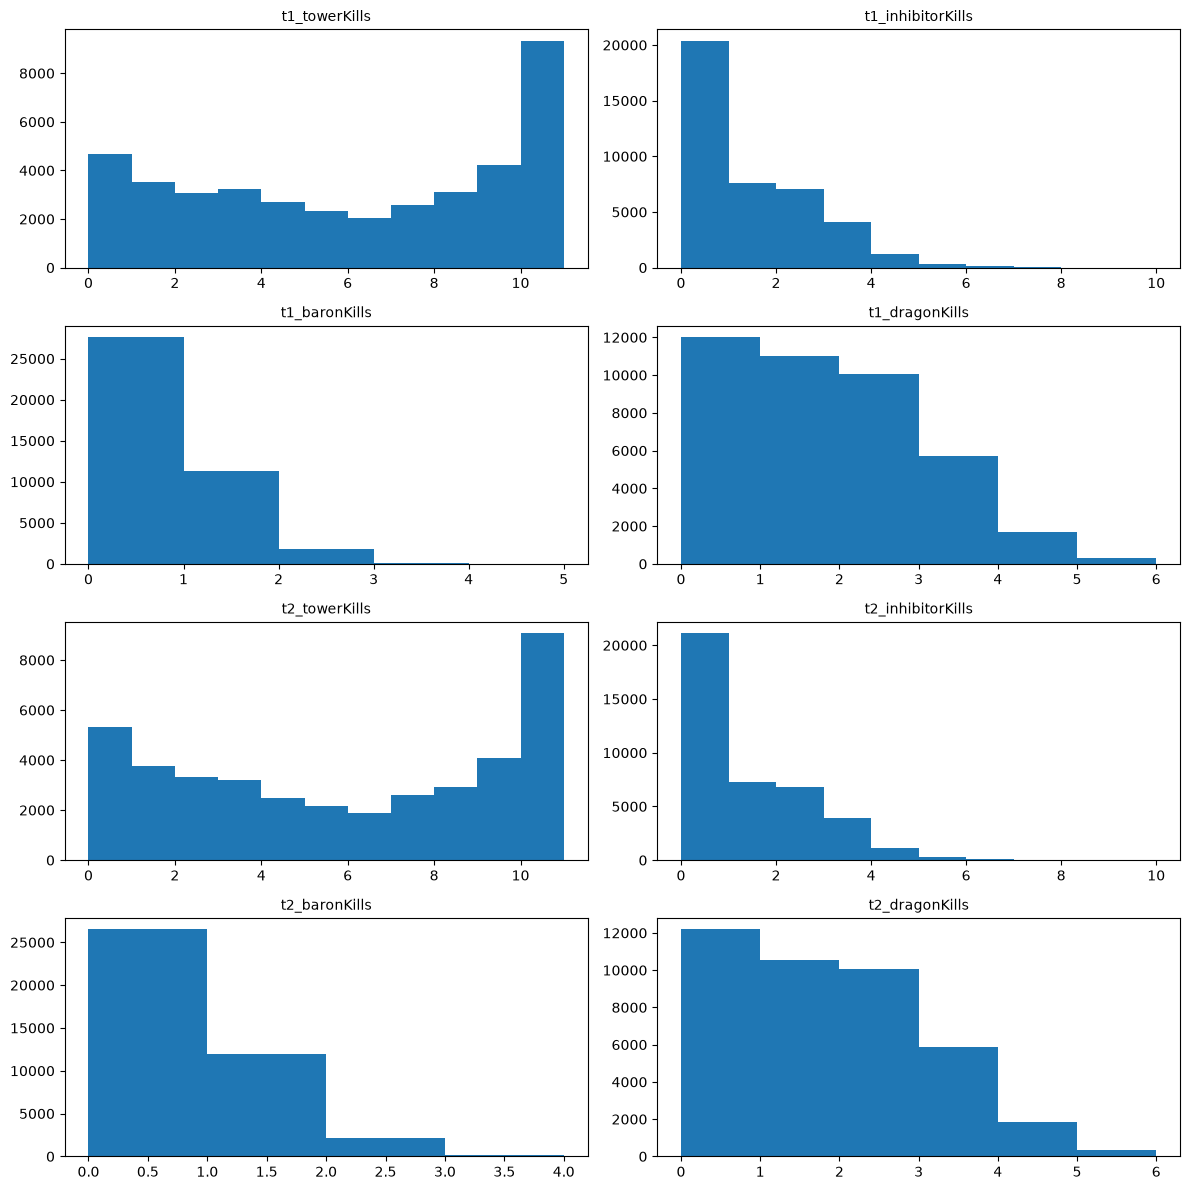

In [9]:
kills_features = [
    col for col in df_train.columns
    if 'Kills' in col and 'Herald' not in col
]

cols = 2
rows = (len(kills_features) + cols - 1) // cols

fig, axes = plt.subplots(rows, 
                         cols, 
                         figsize=(12, 3 * rows)
)
axes = axes.flatten()

for col, ax in zip(kills_features, axes):
    ax.hist(df_train[col], bins = 'auto')
    ax.set_title(col, fontsize=10)
    
for ax in axes[len(kills_features):]:
    ax.remove()
    
plt.tight_layout()
plt.show()

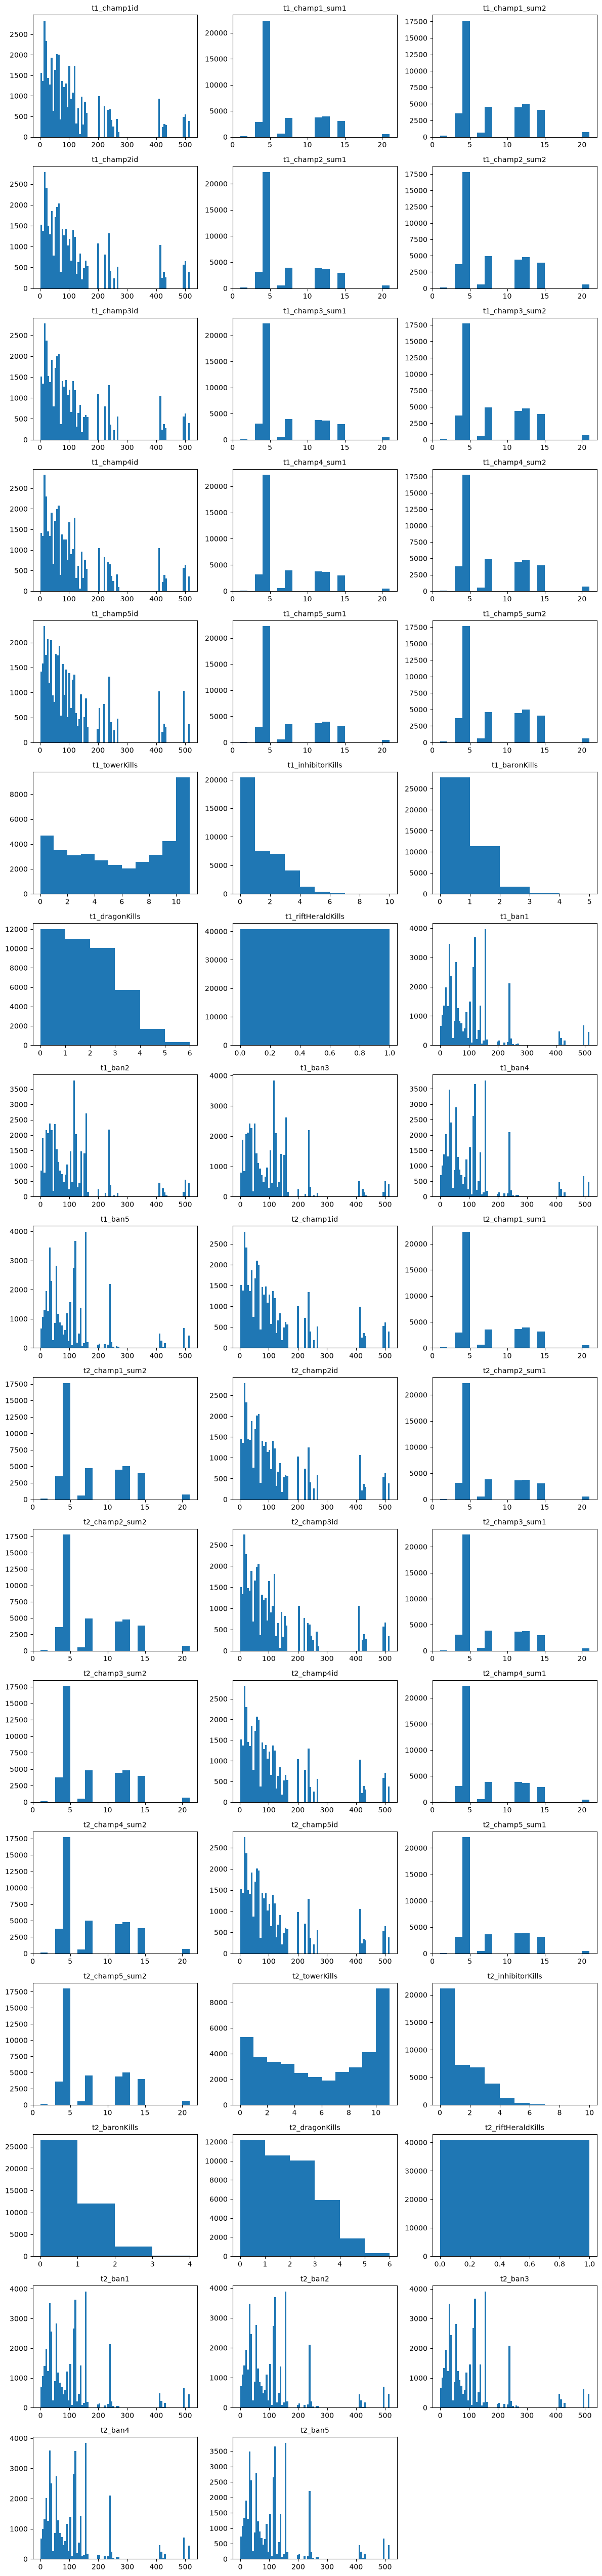

In [10]:
team_features = [
    col for col in df_train.columns
    if 't1' in col or 't2' in col 
]

cols = 3
rows = (len(team_features) + cols - 1) // cols

fig, axes = plt.subplots(rows, 
                         cols, 
                         figsize=(12, 3 * rows)
)
axes = axes.flatten()

for col, ax in zip(team_features, axes):
    ax.hist(df_train[col], bins = 'auto')
    ax.set_title(col, fontsize=10)
    
for ax in axes[len(team_features):]:
    ax.remove()
    
plt.tight_layout()
plt.show()

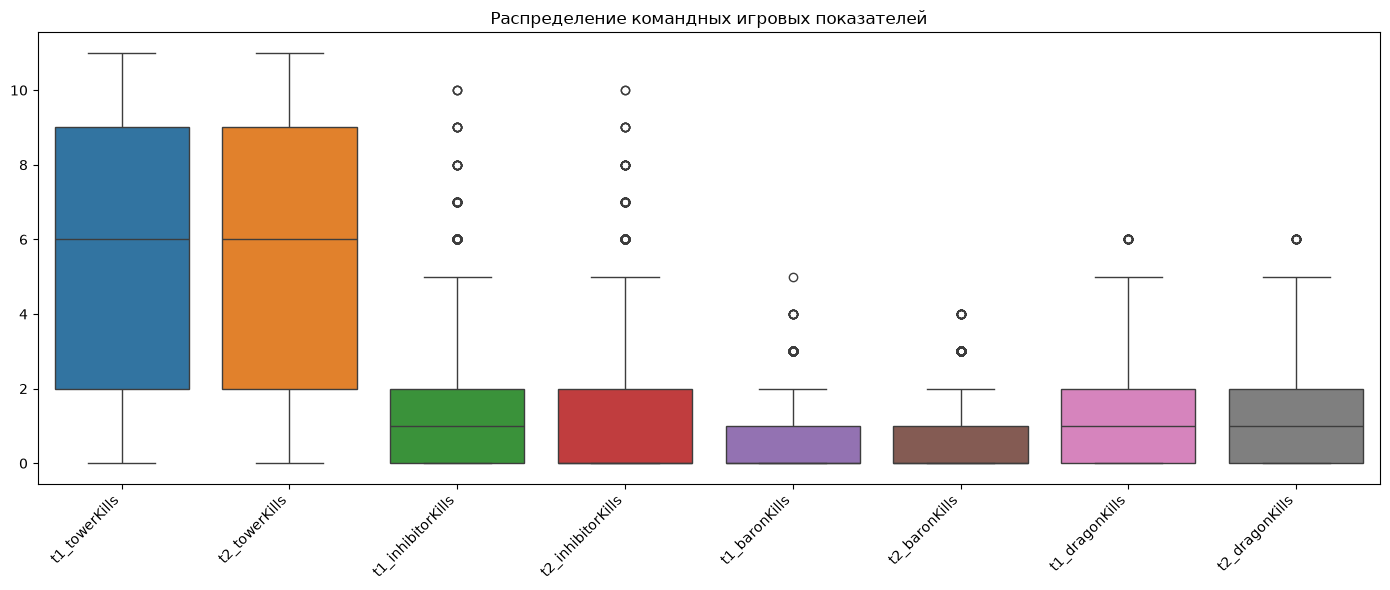

In [11]:
boxplot_features = [
    't1_towerKills',
    't2_towerKills',
    't1_inhibitorKills',
    't2_inhibitorKills',
    't1_baronKills',
    't2_baronKills',
    't1_dragonKills',
    't2_dragonKills'
]

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_train[boxplot_features]
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.title('Распределение командных игровых показателей')

plt.tight_layout()
plt.show()

**Выводы:**
- Пропуски в данных отсутствуют.
- Все дубликаты были удалены до текущего этапа обработки.
- Boxplot показывает редкие высокие значения для числа уничтоженных ингибиторов, баронов и драконов. По правилу IQR они определяются как потенциальные выбросы, однако для игровых счетчиков такие значения являются допустимыми и могут соответствовать реальным матчам, поэтому удалять их не требуется.
- Нулевые значения игровых счетчиков также являются допустимыми и означают отсутствие соответствующего события в матче.
- Дополнительного заполнения пропусков или удаления наблюдений на этом этапе не требуется.

# Создание новых признаков и разбиение датасета по гипотезам

**Набор дополнительных признаков:**
- `heroname_pick` - отдельный признак под каждого героя, со значением пикнувшей его команды
- `t*_spellname_count` - отдельный признак под каждый спелл, с их количеством на команду
- `team_heroname_ban` - отдельный признак под каждого героя, со значением бана от какой команды
- `t*_has_role` - наличие определенной роли в команде
- `t*_full_role_coverage` - покрытие пиком команды всех ролей, хотя бы по одной на игрока
- `t*_full_spell_role_coverage` - покрытие спеллами всех ролей
- `match_*_kills` - сумма признаков обеих команд, характеризующее общее состояние матча
- `diff_*` - разница между признаками команд
- `reldiff_*` - разница между признаками команд относительно состояния матча
- `t*_champ_spell_has_role` - наличие у определенной роли соответсвующих ей спеллов
- `t*_full_champ_spell_role_coverage` - каждая роль в команде имеет соотсвтующей ей спелл
- `t*_full_role_coverage_score` - максимальный пикрейт каждой роли у команды из наборы выбранных героев

Для создания новых признаков дополнительно использую информацию о ролях чемпионов и назначении заклинаний призывателя. В исходном датасете ID чемпионов и заклинаний сами по себе не содержат для модели информации об их игровом назначении, поэтому дополнительные данные позволят перейти от простых идентификаторов к более содержательным признакам состава команды.

In [12]:
champion_roles = pull_data()

In [13]:
with open('summoner_spell_info.json', encoding='utf-8') as f:
    spell_json = json.load(f)

spell_id_to_name = {
    int(spell['id']): spell['name']
    for spell in spell_json['data'].values()
}

In [14]:
with open('champion_info.json', encoding='utf-8') as f:
    champion_json_1 = json.load(f)

with open('champion_info_2.json', encoding='utf-8') as f:
    champion_json_2 = json.load(f)

id_to_name = {}

for champ in champion_json_1['data'].values():
    id_to_name[int(champ['id'])] = champ['name']

for champ in champion_json_2['data'].values():
    if champ['id'] != -1:
        id_to_name[int(champ['id'])] = champ['name']

In [15]:
with open('champion_info.json', encoding='utf-8') as f:
    champion_json_1 = json.load(f)

with open('champion_info_2.json', encoding='utf-8') as f:
    champion_json_2 = json.load(f)

json_ids = {
    int(champ['id'])
    for champ in champion_json_1['data'].values()
}

json_ids.update(
    int(champ['id'])
    for champ in champion_json_2['data'].values()
    if champ['id'] != -1
)

meraki_ids = set(champion_roles.keys())

print('Есть в JSON, но нет в Meraki:')
print(json_ids - meraki_ids)

Есть в JSON, но нет в Meraki:
set()


In [16]:
spell_roles = {
    1: {  # Cleanse
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 1,
        'BOTTOM': 2,
        'UTILITY': 0
    },

    3: {  # Exhaust
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 1,
        'BOTTOM': 0,
        'UTILITY': 2
    },

    4: {  # Flash
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 0,
        'BOTTOM': 0,
        'UTILITY': 0
    },

    6: {  # Ghost
        'TOP': 1,
        'JUNGLE': 1,
        'MIDDLE': 1,
        'BOTTOM': 0,
        'UTILITY': 0
    },

    7: {  # Heal
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 1,
        'BOTTOM': 2,
        'UTILITY': 1
    },

    11: {  # Smite
        'TOP': 0,
        'JUNGLE': 2,
        'MIDDLE': 0,
        'BOTTOM': 0,
        'UTILITY': 0
    },

    12: {  # Teleport
        'TOP': 2,
        'JUNGLE': 0,
        'MIDDLE': 1,
        'BOTTOM': 1,
        'UTILITY': 0
    },

    13: {  # Clarity
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 0,
        'BOTTOM': 0,
        'UTILITY': 0
    },

    14: {  # Ignite
        'TOP': 1,
        'JUNGLE': 0,
        'MIDDLE': 2,
        'BOTTOM': 0,
        'UTILITY': 2
    },

    21: {  # Barrier
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 2,
        'BOTTOM': 1,
        'UTILITY': 0
    },

    30: {  # To the King!
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 0,
        'BOTTOM': 0,
        'UTILITY': 0
    },

    31: {  # Poro Toss
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 0,
        'BOTTOM': 0,
        'UTILITY': 0
    },

    32: {  # Mark
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 0,
        'BOTTOM': 0,
        'UTILITY': 0
    },

    33: {  # Nexus Siege slot 1
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 0,
        'BOTTOM': 0,
        'UTILITY': 0
    },

    34: {  # Nexus Siege slot 2
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 0,
        'BOTTOM': 0,
        'UTILITY': 0
    },

    35: {  # Disabled spell 1
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 0,
        'BOTTOM': 0,
        'UTILITY': 0
    },

    36: {  # Disabled spell 2
        'TOP': 0,
        'JUNGLE': 0,
        'MIDDLE': 0,
        'BOTTOM': 0,
        'UTILITY': 0
    }
}

In [17]:
class LoLFeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(self, champion_roles, id_to_name, spell_roles, spell_id_to_name):
        self.champion_roles = champion_roles
        self.id_to_name = id_to_name
        self.spell_roles = spell_roles
        self.spell_id_to_name = spell_id_to_name
        
        self.first_event_features = [
            'firstBlood',
            'firstTower',
            'firstInhibitor',
            'firstBaron',
            'firstDragon',
            'firstRiftHerald'
        ]

        self.team_stat_features = [
            'towerKills',
            'inhibitorKills',
            'baronKills',
            'dragonKills',
            'riftHeraldKills'
        ]
        
        self.roles = [
            'TOP',
            'JUNGLE',
            'MIDDLE',
            'BOTTOM',
            'UTILITY'
        ]

        self.t1_champ_cols = [
            f't1_champ{i}id'
            for i in range(1, 6)
        ]

        self.t2_champ_cols = [
            f't2_champ{i}id'
            for i in range(1, 6)
        ]


    def fit(self, X, y=None):
        return self


    def transform(self, X):

        X = X.copy()

        X = self._convert_team_values(X)

        X = self._add_pick_features(X)
        X = self._add_has_role_features(X)
        X = self._add_full_role_coverage(X)

        X = self._add_team_ban_features(X)

        X = self._add_spell_count_features(X)
        X = self._add_full_spell_role_coverage(X)
        X = self._add_champ_spell_has_role(X)
        X = self._add_full_champ_spell_role_coverage(X)

        X = self._add_match_features(X)
        X = self._add_diff_features(X)
        X = self._add_reldiff_features(X)

        return X


    def _clean_name(self, name):

        return re.sub(
            r'[^a-z0-9]+',
            '_',
            name.lower()
        ).strip('_')
        
    def _add_match_features(self, X):

        new_features = {}

        for feature in self.team_stat_features:

            t1_col = f't1_{feature}'
            t2_col = f't2_{feature}'

            new_features[
                f'match_{feature}'
            ] = (
                X[t1_col] + X[t2_col]
            )

        return pd.concat(
            [X, pd.DataFrame(new_features, index=X.index)],
            axis=1
        )
        
    def _add_diff_features(self, X):

        new_features = {}

        for feature in self.team_stat_features:

            t1_col = f't1_{feature}'
            t2_col = f't2_{feature}'

            new_features[
                f'diff_{feature}'
            ] = (
                X[t1_col] - X[t2_col]
            )

        return pd.concat(
            [X, pd.DataFrame(new_features, index=X.index)],
            axis=1
        )
      
        
    def _convert_team_values(self, X):

        X = X.copy()

        for col in self.first_event_features:
            if col in X.columns:
                X[col] = X[col].replace({
                    1: 1,
                    2: -1
                })

        return X
        
        
    def _add_reldiff_features(self, X):

        new_features = {}

        for feature in self.team_stat_features:

            t1_col = f't1_{feature}'
            t2_col = f't2_{feature}'

            diff = X[t1_col] - X[t2_col]
            total = X[t1_col] + X[t2_col]

            new_features[
                f'reldiff_{feature}'
            ] = np.where(
                total != 0,
                diff / total,
                0
            )

        return pd.concat(
            [X, pd.DataFrame(new_features, index=X.index)],
            axis=1
        )


    def _best_role_assignment(self, champ_ids):

        best_score = -1
        best_assignment = None

        for permutation in itertools.permutations(champ_ids):

            play_rates = []

            for role, champ_id in zip(
                self.roles,
                permutation
            ):

                rate = self.champion_roles[
                    int(champ_id)
                ][role]

                play_rates.append(rate)

            score = np.prod(play_rates)

            if score > best_score:

                best_score = score

                best_assignment = dict(
                    zip(
                        self.roles,
                        permutation
                    )
                )

        return best_score, best_assignment


    def _add_pick_features(self, X):

        new_features = {}

        for champ_id, champ_name in self.id_to_name.items():

            col_name = (
                f'{self._clean_name(champ_name)}_pick'
            )

            picked_t1 = (
                X[self.t1_champ_cols]
                .eq(champ_id)
                .any(axis=1)
            )

            picked_t2 = (
                X[self.t2_champ_cols]
                .eq(champ_id)
                .any(axis=1)
            )

            values = pd.Series(
                0,
                index=X.index,
                dtype='int8'
            )

            values.loc[picked_t1] = 1
            values.loc[picked_t2] = -1

            new_features[col_name] = values

        new_features = pd.DataFrame(
            new_features,
            index=X.index
        )

        return pd.concat(
            [X, new_features],
            axis=1
        )


    def _add_has_role_features(self, X):

        new_features = {}

        for team, champ_cols in [
            ('t1', self.t1_champ_cols),
            ('t2', self.t2_champ_cols)
        ]:

            for role in self.roles:

                col_name = (
                    f'{team}_has_{role.lower()}'
                )

                new_features[col_name] = (
                    X[champ_cols].apply(
                        lambda row: max(
                            self.champion_roles[
                                int(champ_id)
                            ][role]
                            for champ_id in row
                        ),
                        axis=1
                    )
                )

        new_features = pd.DataFrame(
            new_features,
            index=X.index
        )

        return pd.concat(
            [X, new_features],
            axis=1
        )


    def _add_full_role_coverage(self, X):

        new_features = {}

        for team, champ_cols in [
            ('t1', self.t1_champ_cols),
            ('t2', self.t2_champ_cols)
        ]:

            scores = X[champ_cols].apply(
                lambda row:
                    self._best_role_assignment(
                        row.tolist()
                    )[0],
                axis=1
            )

            new_features[
                f'{team}_full_role_coverage'
            ] = (
                scores > 0
            ).astype('int8')

            new_features[
                f'{team}_full_role_coverage_score'
            ] = scores

        new_features = pd.DataFrame(
            new_features,
            index=X.index
        )

        return pd.concat(
            [X, new_features],
            axis=1
        )


    def _add_team_ban_features(self, X):

        t1_ban_cols = [
            col
            for col in X.columns
            if col.startswith('t1_ban')
        ]

        t2_ban_cols = [
            col
            for col in X.columns
            if col.startswith('t2_ban')
        ]

        new_features = {}

        for champ_id, champ_name in self.id_to_name.items():

            col_name = (
                f'team_{self._clean_name(champ_name)}_ban'
            )

            banned_t1 = (
                X[t1_ban_cols]
                .eq(champ_id)
                .any(axis=1)
            )

            banned_t2 = (
                X[t2_ban_cols]
                .eq(champ_id)
                .any(axis=1)
            )

            values = pd.Series(
                0,
                index=X.index,
                dtype='int8'
            )

            values.loc[banned_t1] = 1
            values.loc[banned_t2] = -1

            new_features[col_name] = values

        new_features = pd.DataFrame(
            new_features,
            index=X.index
        )

        return pd.concat(
            [X, new_features],
            axis=1
        )
    
    def _add_spell_count_features(self, X):

        new_features = {}

        for team in ['t1', 't2']:

            spell_cols = []

            for i in range(1, 6):
                spell_cols.append(f'{team}_champ{i}_sum1')
                spell_cols.append(f'{team}_champ{i}_sum2')

            for spell_id in self.spell_roles.keys():

                spell_name = self._clean_name(
                    self.spell_id_to_name[spell_id]
                )

                col_name = f'{team}_{spell_name}_count'

                new_features[col_name] = (
                    X[spell_cols]
                    .eq(spell_id)
                    .sum(axis=1)
                    .astype('int8')
                )

        return pd.concat(
            [X, pd.DataFrame(new_features, index=X.index)],
            axis=1
        )
    
    def _full_spell_role_coverage(self, spell_ids):

        role_candidates = {
            role: []
            for role in self.roles
        }

        for idx, spell_id in enumerate(spell_ids):

            spell_id = int(spell_id)

            if spell_id not in self.spell_roles:
                continue

            for role in self.roles:

                if self.spell_roles[spell_id][role] > 0:
                    role_candidates[role].append(idx)

        def backtrack(role_idx, used_spells):

            if role_idx == len(self.roles):
                return True

            role = self.roles[role_idx]

            for spell_idx in role_candidates[role]:

                if spell_idx not in used_spells:

                    used_spells.add(spell_idx)

                    if backtrack(role_idx + 1, used_spells):
                        return True

                    used_spells.remove(spell_idx)

            return False

        return int(backtrack(0, set()))

    def _add_full_spell_role_coverage(self, X):

        new_features = {}

        for team in ['t1', 't2']:

            spell_cols = []

            for i in range(1, 6):
                spell_cols.append(f'{team}_champ{i}_sum1')
                spell_cols.append(f'{team}_champ{i}_sum2')

            new_features[
                f'{team}_full_spell_role_coverage'
            ] = X[spell_cols].apply(
                lambda row:
                    self._full_spell_role_coverage(
                        row.tolist()
                    ),
                axis=1
            ).astype('int8')

        return pd.concat(
            [X, pd.DataFrame(new_features, index=X.index)],
            axis=1
        )


    def _champ_spell_role_score(
        self,
        champ_id,
        spell1,
        spell2,
        role
    ):

        champ_score = self.champion_roles[
            int(champ_id)
        ][role]

        spell_score = max(
            self.spell_roles.get(
                int(spell1),
                {}
            ).get(role, 0),

            self.spell_roles.get(
                int(spell2),
                {}
            ).get(role, 0)
        )

        return champ_score * spell_score
    
    
    def _add_champ_spell_has_role(self, X):

        new_features = {}

        for team in ['t1', 't2']:

            for role in self.roles:

                scores = []

                for i in range(1, 6):

                    champ_col = f'{team}_champ{i}id'
                    spell1_col = f'{team}_champ{i}_sum1'
                    spell2_col = f'{team}_champ{i}_sum2'

                    player_score = X.apply(
                        lambda row:
                            self._champ_spell_role_score(
                                row[champ_col],
                                row[spell1_col],
                                row[spell2_col],
                                role
                            ),
                        axis=1
                    )

                    scores.append(player_score)

                scores_df = pd.concat(
                    scores,
                    axis=1
                )

                new_features[
                    f'{team}_champ_spell_has_{role.lower()}'
                ] = scores_df.max(axis=1)

        return pd.concat(
            [X, pd.DataFrame(new_features, index=X.index)],
            axis=1
        )
        
    def _full_champ_spell_role_coverage_row(
        self,
        row,
        team
    ):

        players = []

        for i in range(1, 6):

            champ_id = row[
                f'{team}_champ{i}id'
            ]

            spell1 = row[
                f'{team}_champ{i}_sum1'
            ]

            spell2 = row[
                f'{team}_champ{i}_sum2'
            ]

            players.append(
                (
                    champ_id,
                    spell1,
                    spell2
                )
            )

        for permutation in itertools.permutations(
            range(5)
        ):

            valid = True

            for role, player_idx in zip(
                self.roles,
                permutation
            ):

                champ_id, spell1, spell2 = (
                    players[player_idx]
                )

                score = self._champ_spell_role_score(
                    champ_id,
                    spell1,
                    spell2,
                    role
                )

                if score <= 0:
                    valid = False
                    break

            if valid:
                return 1

        return 0
    
    def _add_full_champ_spell_role_coverage(self, X):

        new_features = {}

        for team in ['t1', 't2']:

            new_features[
                f'{team}_full_champ_spell_role_coverage'
            ] = X.apply(
                lambda row:
                    self._full_champ_spell_role_coverage_row(
                        row,
                        team
                    ),
                axis=1
            ).astype('int8')

        return pd.concat(
            [X, pd.DataFrame(new_features, index=X.index)],
            axis=1
        )
    


In [18]:
feature_engineer = LoLFeatureEngineer(
    champion_roles=champion_roles,
    id_to_name=id_to_name,
    spell_roles=spell_roles,
    spell_id_to_name=spell_id_to_name
)

df_train_features = feature_engineer.fit_transform(df_train)

In [19]:
df_train_features.head()

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5,annie_pick,olaf_pick,galio_pick,twisted_fate_pick,xin_zhao_pick,urgot_pick,leblanc_pick,vladimir_pick,fiddlesticks_pick,kayle_pick,master_yi_pick,alistar_pick,ryze_pick,sion_pick,sivir_pick,soraka_pick,teemo_pick,tristana_pick,warwick_pick,nunu_pick,miss_fortune_pick,ashe_pick,tryndamere_pick,jax_pick,morgana_pick,zilean_pick,singed_pick,evelynn_pick,twitch_pick,karthus_pick,cho_gath_pick,amumu_pick,rammus_pick,anivia_pick,shaco_pick,dr_mundo_pick,sona_pick,kassadin_pick,irelia_pick,janna_pick,gangplank_pick,corki_pick,karma_pick,taric_pick,veigar_pick,trundle_pick,swain_pick,caitlyn_pick,blitzcrank_pick,malphite_pick,katarina_pick,nocturne_pick,maokai_pick,renekton_pick,jarvan_iv_pick,elise_pick,orianna_pick,wukong_pick,brand_pick,lee_sin_pick,vayne_pick,rumble_pick,cassiopeia_pick,skarner_pick,heimerdinger_pick,nasus_pick,nidalee_pick,udyr_pick,poppy_pick,gragas_pick,pantheon_pick,ezreal_pick,mordekaiser_pick,yorick_pick,akali_pick,kennen_pick,garen_pick,leona_pick,malzahar_pick,talon_pick,riven_pick,kog_maw_pick,shen_pick,lux_pick,xerath_pick,shyvana_pick,ahri_pick,graves_pick,fizz_pick,volibear_pick,rengar_pick,varus_pick,nautilus_pick,viktor_pick,sejuani_pick,fiora_pick,ziggs_pick,lulu_pick,draven_pick,hecarim_pick,kha_zix_pick,darius_pick,jayce_pick,lissandra_pick,diana_pick,quinn_pick,syndra_pick,aurelion_sol_pick,kayn_pick,zyra_pick,gnar_pick,zac_pick,yasuo_pick,vel_koz_pick,taliyah_pick,camille_pick,braum_pick,jhin_pick,kindred_pick,jinx_pick,tahm_kench_pick,lucian_pick,zed_pick,kled_pick,ekko_pick,vi_pick,aatrox_pick,nami_pick,azir_pick,thresh_pick,illaoi_pick,rek_sai_pick,ivern_pick,kalista_pick,bard_pick,rakan_pick,xayah_pick,ornn_pick,t1_has_top,t1_has_jungle,t1_has_middle,t1_has_bottom,t1_has_utility,t2_has_top,t2_has_jungle,t2_has_middle,t2_has_bottom,t2_has_utility,t1_full_role_coverage,t1_full_role_coverage_score,t2_full_role_coverage,t2_full_role_coverage_score,team_annie_ban,team_olaf_ban,team_galio_ban,team_twisted_fate_ban,team_xin_zhao_ban,team_urgot_ban,team_leblanc_ban,team_vladimir_ban,team_fiddlesticks_ban,team_kayle_ban,team_master_yi_ban,team_alistar_ban,team_ryze_ban,team_sion_ban,team_sivir_ban,team_soraka_ban,team_teemo_ban,team_tristana_ban,team_warwick_ban,team_nunu_ban,team_miss_fortune_ban,team_ashe_ban,team_tryndamere_ban,team_jax_ban,team_morgana_ban,team_zilean_ban,team_singed_ban,team_evelynn_ban,team_twitch_ban,team_karthus_ban,team_cho_gath_ban,team_amumu_ban,team_rammus_ban,team_anivia_ban,team_shaco_ban,team_dr_mundo_ban,team_sona_ban,team_kassadin_ban,team_irelia_ban,team_janna_ban,team_gangplank_ban,team_corki_ban,team_karma_ban,team_taric_ban,team_veigar_ban,team_trundle_ban,team_swain_ban,team_caitlyn_ban,team_blitzcrank_ban,team_malphite_ban,team_katarina_ban,team_nocturne_ban,team_maokai_ban,team_renekton_ban,team_jarvan_iv_ban,team_elise_ban,team_orianna_ban,team_wukong_ban,team_brand_ban,team_lee_sin_ban,team_vayne_ban,team_rumble_ban,team_cassiopeia_ban,team_skarner_ban,team_heimerdinger_ban,team_nasus_ban,team_nidalee_ban,team_udyr_ban,team_poppy_ban,team_gragas_ban,team_pantheon_ban,team_ezreal_ban,team_mordekaiser_ban,team_yorick_ban,team_akali_ban,team_kennen_ban,team_garen_ban,team_leona_ban,team_mal

**Результат feature engineering:**

Новые признаки успешно добавлены к исходному датасету. При этом исходные данные не заменяются, а сохраняются отдельно, поэтому дальше можно сравнивать качество моделей на первоначальном и расширенном наборах признаков.

Перед обучением моделей дополнительно проверю полученный датафрейм: наличие пустых, константных и почти константных признаков, связь новых признаков с целевой переменной и наличие сильных зависимостей между самими признаками.

In [20]:
df_train_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 40842 entries, 0 to 40841
Columns: 410 entries, gameId to reldiff_riftHeraldKills
dtypes: float64(27), int64(71), int8(312)
memory usage: 42.7 MB


In [21]:
df_train_features.describe().round(2)

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5,annie_pick,olaf_pick,galio_pick,twisted_fate_pick,xin_zhao_pick,urgot_pick,leblanc_pick,vladimir_pick,fiddlesticks_pick,kayle_pick,master_yi_pick,alistar_pick,ryze_pick,sion_pick,sivir_pick,soraka_pick,teemo_pick,tristana_pick,warwick_pick,nunu_pick,miss_fortune_pick,ashe_pick,tryndamere_pick,jax_pick,morgana_pick,zilean_pick,singed_pick,evelynn_pick,twitch_pick,karthus_pick,cho_gath_pick,amumu_pick,rammus_pick,anivia_pick,shaco_pick,dr_mundo_pick,sona_pick,kassadin_pick,irelia_pick,janna_pick,gangplank_pick,corki_pick,karma_pick,taric_pick,veigar_pick,trundle_pick,swain_pick,caitlyn_pick,blitzcrank_pick,malphite_pick,katarina_pick,nocturne_pick,maokai_pick,renekton_pick,jarvan_iv_pick,elise_pick,orianna_pick,wukong_pick,brand_pick,lee_sin_pick,vayne_pick,rumble_pick,cassiopeia_pick,skarner_pick,heimerdinger_pick,nasus_pick,nidalee_pick,udyr_pick,poppy_pick,gragas_pick,pantheon_pick,ezreal_pick,mordekaiser_pick,yorick_pick,akali_pick,kennen_pick,garen_pick,leona_pick,malzahar_pick,talon_pick,riven_pick,kog_maw_pick,shen_pick,lux_pick,xerath_pick,shyvana_pick,ahri_pick,graves_pick,fizz_pick,volibear_pick,rengar_pick,varus_pick,nautilus_pick,viktor_pick,sejuani_pick,fiora_pick,ziggs_pick,lulu_pick,draven_pick,hecarim_pick,kha_zix_pick,darius_pick,jayce_pick,lissandra_pick,diana_pick,quinn_pick,syndra_pick,aurelion_sol_pick,kayn_pick,zyra_pick,gnar_pick,zac_pick,yasuo_pick,vel_koz_pick,taliyah_pick,camille_pick,braum_pick,jhin_pick,kindred_pick,jinx_pick,tahm_kench_pick,lucian_pick,zed_pick,kled_pick,ekko_pick,vi_pick,aatrox_pick,nami_pick,azir_pick,thresh_pick,illaoi_pick,rek_sai_pick,ivern_pick,kalista_pick,bard_pick,rakan_pick,xayah_pick,ornn_pick,t1_has_top,t1_has_jungle,t1_has_middle,t1_has_bottom,t1_has_utility,t2_has_top,t2_has_jungle,t2_has_middle,t2_has_bottom,t2_has_utility,t1_full_role_coverage,t1_full_role_coverage_score,t2_full_role_coverage,t2_full_role_coverage_score,team_annie_ban,team_olaf_ban,team_galio_ban,team_twisted_fate_ban,team_xin_zhao_ban,team_urgot_ban,team_leblanc_ban,team_vladimir_ban,team_fiddlesticks_ban,team_kayle_ban,team_master_yi_ban,team_alistar_ban,team_ryze_ban,team_sion_ban,team_sivir_ban,team_soraka_ban,team_teemo_ban,team_tristana_ban,team_warwick_ban,team_nunu_ban,team_miss_fortune_ban,team_ashe_ban,team_tryndamere_ban,team_jax_ban,team_morgana_ban,team_zilean_ban,team_singed_ban,team_evelynn_ban,team_twitch_ban,team_karthus_ban,team_cho_gath_ban,team_amumu_ban,team_rammus_ban,team_anivia_ban,team_shaco_ban,team_dr_mundo_ban,team_sona_ban,team_kassadin_ban,team_irelia_ban,team_janna_ban,team_gangplank_ban,team_corki_ban,team_karma_ban,team_taric_ban,team_veigar_ban,team_trundle_ban,team_swain_ban,team_caitlyn_ban,team_blitzcrank_ban,team_malphite_ban,team_katarina_ban,team_nocturne_ban,team_maokai_ban,team_renekton_ban,team_jarvan_iv_ban,team_elise_ban,team_orianna_ban,team_wukong_ban,team_brand_ban,team_lee_sin_ban,team_vayne_ban,team_rumble_ban,team_cassiopeia_ban,team_skarner_ban,team_heimerdinger_ban,team_nasus_ban,team_nidalee_ban,team_udyr_ban,team_poppy_ban,team_gragas_ban,team_pantheon_ban,team_ezreal_ban,team_mordekaiser_ban,team_yorick_ban,team_akali_ban,team_kennen_ban,team_garen_ban,team_leona_ban,team_mal

In [22]:
empty_cols = [
    col for col in df_train_features.columns
    if df_train_features[col].isna().all()
]

print('Полностью пустые:')
print(empty_cols)

Полностью пустые:
[]


In [23]:
constant_cols = [
    col for col in df_train_features.columns
    if df_train_features[col].nunique(dropna=False) <= 1
]

print('Константные:')
print(constant_cols)

Константные:
['seasonId', 't1_clarity_count', 't1_to_the_king_count', 't1_poro_toss_count', 't1_mark_count', 't1_nexus_siege_siege_weapon_slot_count', 't1_disabled_summoner_spells_count', 't2_clarity_count', 't2_to_the_king_count', 't2_poro_toss_count', 't2_mark_count', 't2_nexus_siege_siege_weapon_slot_count', 't2_disabled_summoner_spells_count']


In [24]:
almost_constant = []

for col in df_train_features.columns:
    freq = df_train_features[col].value_counts(normalize=True, dropna=False)

    if len(freq) > 0 and freq.iloc[0] > 0.99:
        almost_constant.append(
            (col, freq.iloc[0])
        )

almost_constant[:100]

[('seasonId', np.float64(1.0)),
 ('team_olaf_ban', np.float64(0.9928994662357378)),
 ('team_twisted_fate_ban', np.float64(0.9948092649723324)),
 ('team_fiddlesticks_ban', np.float64(0.9942461191910288)),
 ('team_ryze_ban', np.float64(0.998016747465844)),
 ('team_sion_ban', np.float64(0.9979432936682826)),
 ('team_sivir_ban', np.float64(0.9943440575877773)),
 ('team_nunu_ban', np.float64(0.9926056510454924)),
 ('team_ashe_ban', np.float64(0.9907937907056461)),
 ('team_zilean_ban', np.float64(0.9965966407129915)),
 ('team_singed_ban', np.float64(0.9903285833210911)),
 ('team_karthus_ban', np.float64(0.9976739630772244)),
 ('team_karma_ban', np.float64(0.9957151951422555)),
 ('team_taric_ban', np.float64(0.9958131335390039)),
 ('team_trundle_ban', np.float64(0.995176533960139)),
 ('team_swain_ban', np.float64(0.9911610596934528)),
 ('team_malphite_ban', np.float64(0.9903775525194652)),
 ('team_nocturne_ban', np.float64(0.9948827187698938)),
 ('team_wukong_ban', np.float64(0.99316879682679

**Выводы:**

- Полностью пустые и константные признаки можно удалить, так как они не содержат информации, которая могла бы использоваться моделью.
- Почти константные признаки не буду автоматически удалять только из-за высокой доли одного значения. Для разреженных признаков пиков, банов и заклинаний такое распределение является естественным: конкретный герой или заклинание встречается только в части матчей.
- Поэтому дальнейший отбор признаков будет основываться не только на частоте значений, но и на их связи с целевой переменной и дублировании информации другими признаками.

In [25]:
new_columns = [
    col
    for col in df_train_features.columns
    if col not in df_train.columns
]

old_important_cols = [
    'winner',

    'firstBlood',
    'firstTower',
    'firstInhibitor',
    'firstBaron',
    'firstDragon',
    'firstRiftHerald',

    't1_towerKills',
    't1_inhibitorKills',
    't1_baronKills',
    't1_dragonKills',
    't1_riftHeraldKills',

    't2_towerKills',
    't2_inhibitorKills',
    't2_baronKills',
    't2_dragonKills',
    't2_riftHeraldKills'
]

new_important_cols = [
    col for col in df_train_features.columns
    if (
        'has_' in col
        or 'coverage' in col
        or col.startswith('match_')
        or col.startswith('diff_')
        or col.startswith('reldiff_')
        or col.endswith('_count')
    )
]

analysis_cols = [
    col
    for col in old_important_cols + new_important_cols
    if col in df_train_features.columns
]

print('Количество признаков для анализа:', len(analysis_cols))

df_train_features[analysis_cols].describe().T

Количество признаков для анализа: 90


,count,mean,std,min,25%,50%,75%,max
winner,40842.0,1.491186,0.499928,1.0,1.000000,1.000,2.000000,2.000000
firstBlood,40842.0,0.025219,0.994316,-1.0,-1.000000,1.000,1.000000,1.000000
firstTower,40842.0,0.031879,0.987799,-1.0,-1.000000,1.000,1.000000,1.000000
firstInhibitor,40842.0,0.019710,0.936216,-1.0,-1.000000,0.000,1.000000,1.000000
firstBaron,40842.0,-0.031561,0.777810,-1.0,-1.000000,0.000,1.000000,1.000000
firstDragon,40842.0,-0.001249,0.980765,-1.0,-1.000000,0.000,1.000000,1.000000
firstRiftHerald,40842.0,0.011948,0.701085,-1.0,0.000000,0.000,1.000000,1.000000
t1_towerKills,40842.0,5.710396,3.799576,0.0,2.000000,6.000,9.000000,11.000000
t1_inhibitorKills,40842.0,1.018829,1.263099,0.0,0.000000,1.000,2.000000,10.000000
t1_baronKills,40842.0,0.372484,0.583063,0.0,0.000000,0.000,1.000000,5.000000


In [26]:
df_train_features.groupby('winner')[analysis_cols].mean().T

winner,1,2
winner,1.000000,2.000000
firstBlood,0.201578,-0.157470
firstTower,0.429864,-0.380390
firstInhibitor,0.728310,-0.714321
firstBaron,0.334777,-0.411046
firstDragon,0.337953,-0.352624
firstRiftHerald,0.200135,-0.182992
t1_towerKills,8.592512,2.724839
t1_inhibitorKills,1.826091,0.182593
t1_baronKills,0.584909,0.152435


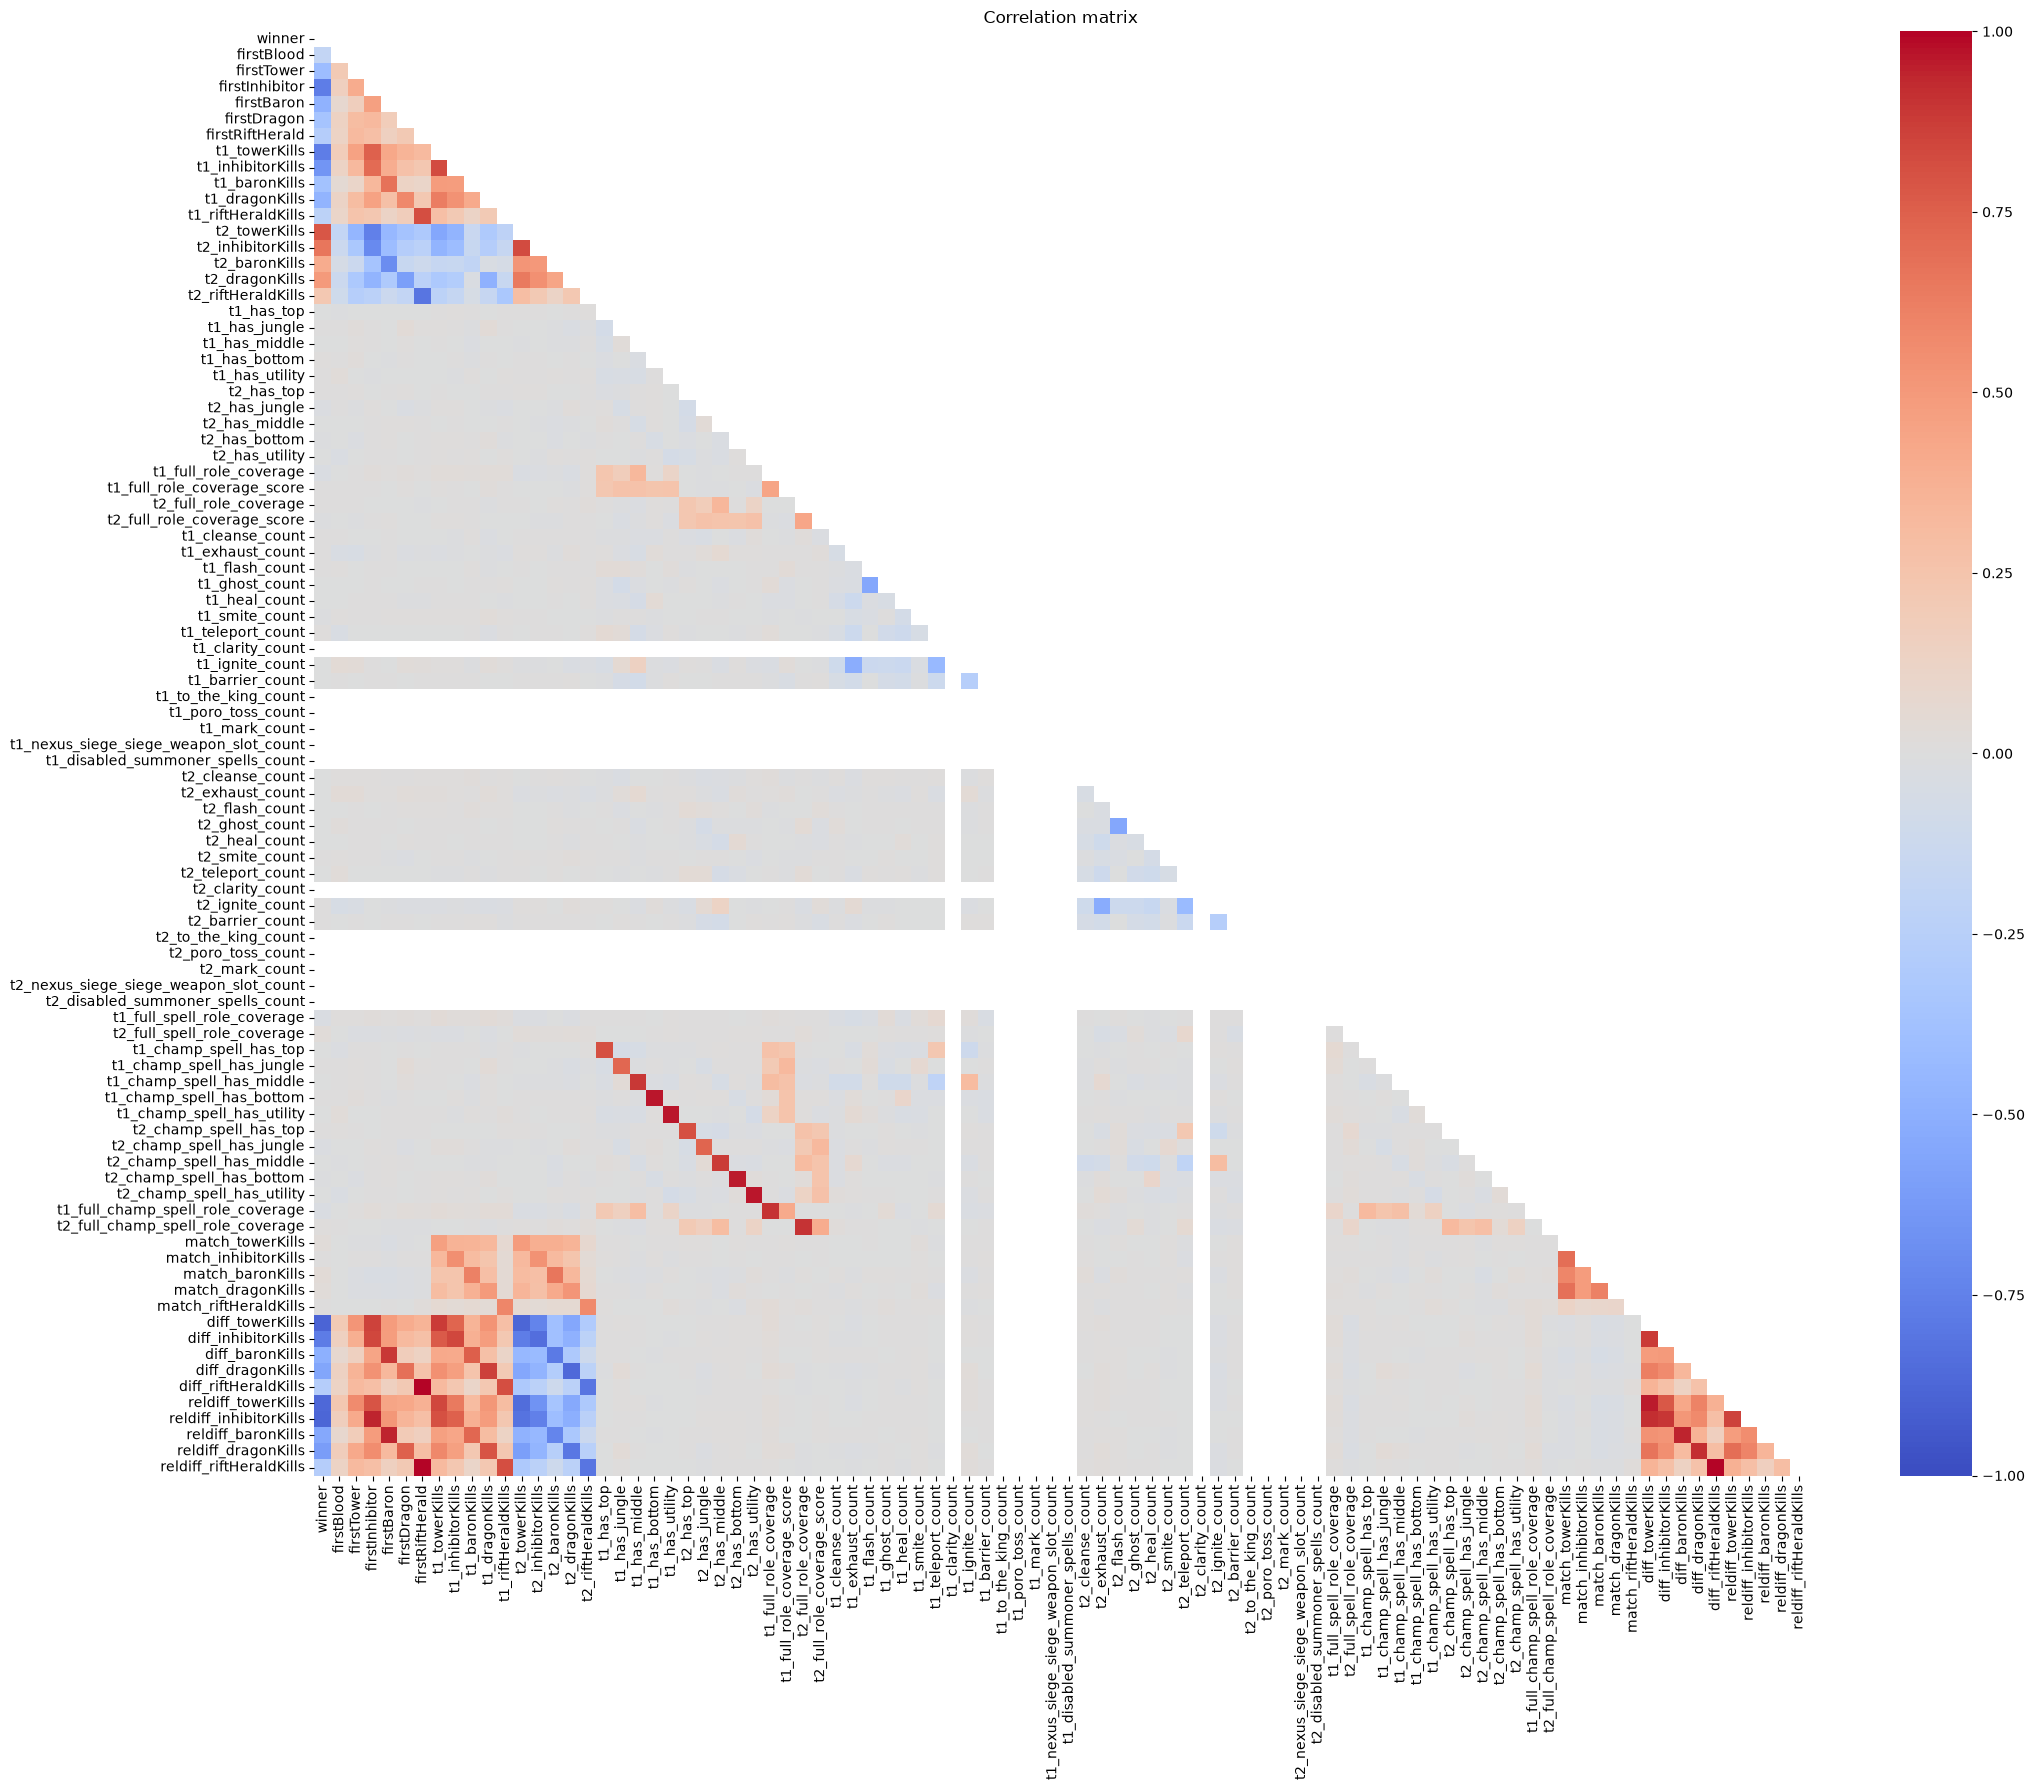

In [27]:
corr = df_train_features[analysis_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(22, 18))

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

In [28]:
target_corr = (
    df_train_features[
        analysis_cols
    ]
    .corr()['winner']
    .drop('winner')
    .sort_values(key=abs, ascending=False)
)

target_corr

diff_towerKills                          -0.884318
reldiff_inhibitorKills                   -0.880190
reldiff_towerKills                       -0.873008
t2_towerKills                             0.784662
diff_inhibitorKills                      -0.780425
t1_towerKills                            -0.772038
firstInhibitor                           -0.770348
t2_inhibitorKills                         0.660426
t1_inhibitorKills                        -0.650488
reldiff_dragonKills                      -0.608634
diff_dragonKills                         -0.562276
reldiff_baronKills                       -0.542124
diff_baronKills                          -0.499220
t2_dragonKills                            0.496461
firstBaron                               -0.479369
t1_dragonKills                           -0.473249
firstTower                               -0.410072
t2_baronKills                             0.398495
t1_baronKills                            -0.370811
firstDragon                    

In [29]:
corr = df_train_features[analysis_cols].corr()

corr_pairs = (
    corr
    .where(
        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    'feature_1',
    'feature_2',
    'correlation'
]

corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()

corr_pairs = corr_pairs.sort_values(
    'abs_correlation',
    ascending=False
)

corr_pairs.head(100)

,feature_1,feature_2,correlation,abs_correlation
629,firstRiftHerald,reldiff_riftHeraldKills,1.000000,1.000000
624,firstRiftHerald,diff_riftHeraldKills,1.000000,1.000000
7649,diff_riftHeraldKills,reldiff_riftHeraldKills,1.000000,1.000000
2412,t2_has_utility,t2_champ_spell_has_utility,0.965242,0.965242
1957,t1_has_utility,t1_champ_spell_has_utility,0.962587,0.962587
1866,t1_has_bottom,t1_champ_spell_has_bottom,0.962073,0.962073
2321,t2_has_bottom,t2_champ_spell_has_bottom,0.960646,0.960646
7285,diff_towerKills,reldiff_towerKills,0.960579,0.960579
447,firstBaron,reldiff_baronKills,0.943696,0.943696
356,firstInhibitor,reldiff_inhibitorKills,0.942197,0.942197


In [30]:
categorical_cols = [
    'firstBlood',
    'firstTower',
    'firstInhibitor',
    'firstBaron',
    'firstDragon',
    'firstRiftHerald'
]

for col in categorical_cols:

    if col in df_train_features.columns:

        print('\n', col)

        display(
            pd.crosstab(
                df_train_features[col],
                df_train_features['winner'],
                normalize='index'
            )
        )


 firstBlood


winner,1,2
firstBlood,,
-1,0.415401,0.584599
0,0.538813,0.461187
1,0.596949,0.403051



 firstTower


winner,1,2
firstTower,,
-1,0.294221,0.705779
0,0.520000,0.480000
1,0.709327,0.290673



 firstInhibitor


...

winner,1,2
firstBaron,,
-1,0.199401,0.800599
0,0.536382,0.463618
1,0.814408,0.185592



 firstDragon


winner,1,2
firstDragon,,
-1,0.328554,0.671446
0,0.535645,0.464355
1,0.687414,0.312586



 firstRiftHerald


winner,1,2
firstRiftHerald,,
-1,0.308187,0.691813
0,0.509777,0.490223
1,0.697977,0.302023


In [31]:
coverage_cols = [
    col for col in df_train_features.columns
    if 'coverage' in col
    and 'score' not in col
]

for col in coverage_cols:

    print('\n', col)

    display(
        pd.crosstab(
            df_train_features[col],
            df_train_features['winner'],
            normalize='index'
        )
    )


 t1_full_role_coverage


winner,1,2
t1_full_role_coverage,,
0,0.495968,0.504032
1,0.522189,0.477811



 t2_full_role_coverage


winner,1,2
t2_full_role_coverage,,
0,0.512565,0.487435
1,0.504978,0.495022



 t1_full_spell_role_coverage


...

winner,1,2
t2_full_spell_role_coverage,,
0,0.628684,0.371316
1,0.507302,0.492698



 t1_full_champ_spell_role_coverage


winner,1,2
t1_full_champ_spell_role_coverage,,
0,0.495425,0.504575
1,0.525989,0.474011



 t2_full_champ_spell_role_coverage


winner,1,2
t2_full_champ_spell_role_coverage,,
0,0.513055,0.486945
1,0.503482,0.496518


In [32]:
spell_count_cols = [
    col for col in df_train_features.columns
    if col.endswith('_count')
]

for col in spell_count_cols:

    print('\n', col)

    display(
        pd.crosstab(
            df_train_features[col],
            df_train_features['winner'],
            normalize='index'
        )
    )


 t1_cleanse_count


winner,1,2
t1_cleanse_count,,
0,0.508921,0.491079
1,0.503741,0.496259
2,0.750000,0.250000
3,0.000000,1.000000



 t1_exhaust_count


winner,1,2
t1_exhaust_count,,
0,0.507778,0.492222
1,0.509954,0.490046
2,0.502720,0.497280
3,0.351351,0.648649
4,0.000000,1.000000



 t1_flash_count


...

winner,1,2
t2_mark_count,,
0,0.508814,0.491186



 t2_nexus_siege_siege_weapon_slot_count


winner,1,2
t2_nexus_siege_siege_weapon_slot_count,,
0,0.508814,0.491186



 t2_disabled_summoner_spells_count


winner,1,2
t2_disabled_summoner_spells_count,,
0,0.508814,0.491186


In [33]:
pick_cols = [
    col for col in df_train_features.columns
    if col.endswith('_pick')
]

pick_frequency = (
    df_train_features[pick_cols]
    .ne(0)
    .mean()
    .sort_values(ascending=False)
)

pick_frequency.head(20)

thresh_pick        0.252093
tristana_pick      0.250796
vayne_pick         0.207874
kayn_pick          0.191739
lee_sin_pick       0.178003
twitch_pick        0.172837
janna_pick         0.169384
lucian_pick        0.160423
jhin_pick          0.156138
jinx_pick          0.154988
xayah_pick         0.152686
yasuo_pick         0.152196
lux_pick           0.139513
blitzcrank_pick    0.133735
rakan_pick         0.132511
caitlyn_pick       0.131972
lulu_pick          0.131752
jax_pick           0.129230
orianna_pick       0.127908
zed_pick           0.124406
dtype: float64

In [34]:
ban_cols = [
    col for col in df_train_features.columns
    if col.startswith('team_')
    and col.endswith('_ban')
]

ban_frequency = (
    df_train_features[ban_cols]
    .ne(0)
    .mean()
    .sort_values(ascending=False)
)

ban_frequency.head(20)

team_yasuo_ban         0.533152
team_zed_ban           0.430268
team_cho_gath_ban      0.410142
team_darius_ban        0.386073
team_draven_ban        0.353998
team_janna_ban         0.332452
team_blitzcrank_ban    0.316782
team_kayn_ban          0.303144
team_twitch_ban        0.276211
team_zac_ban           0.264801
team_fiora_ban         0.262646
team_fizz_ban          0.239337
team_lulu_ban          0.232016
team_tristana_ban      0.227854
team_master_yi_ban     0.202022
team_caitlyn_ban       0.182582
team_vayne_ban         0.168013
team_nasus_ban         0.147936
team_maokai_ban        0.132290
team_lee_sin_ban       0.120636
dtype: float64

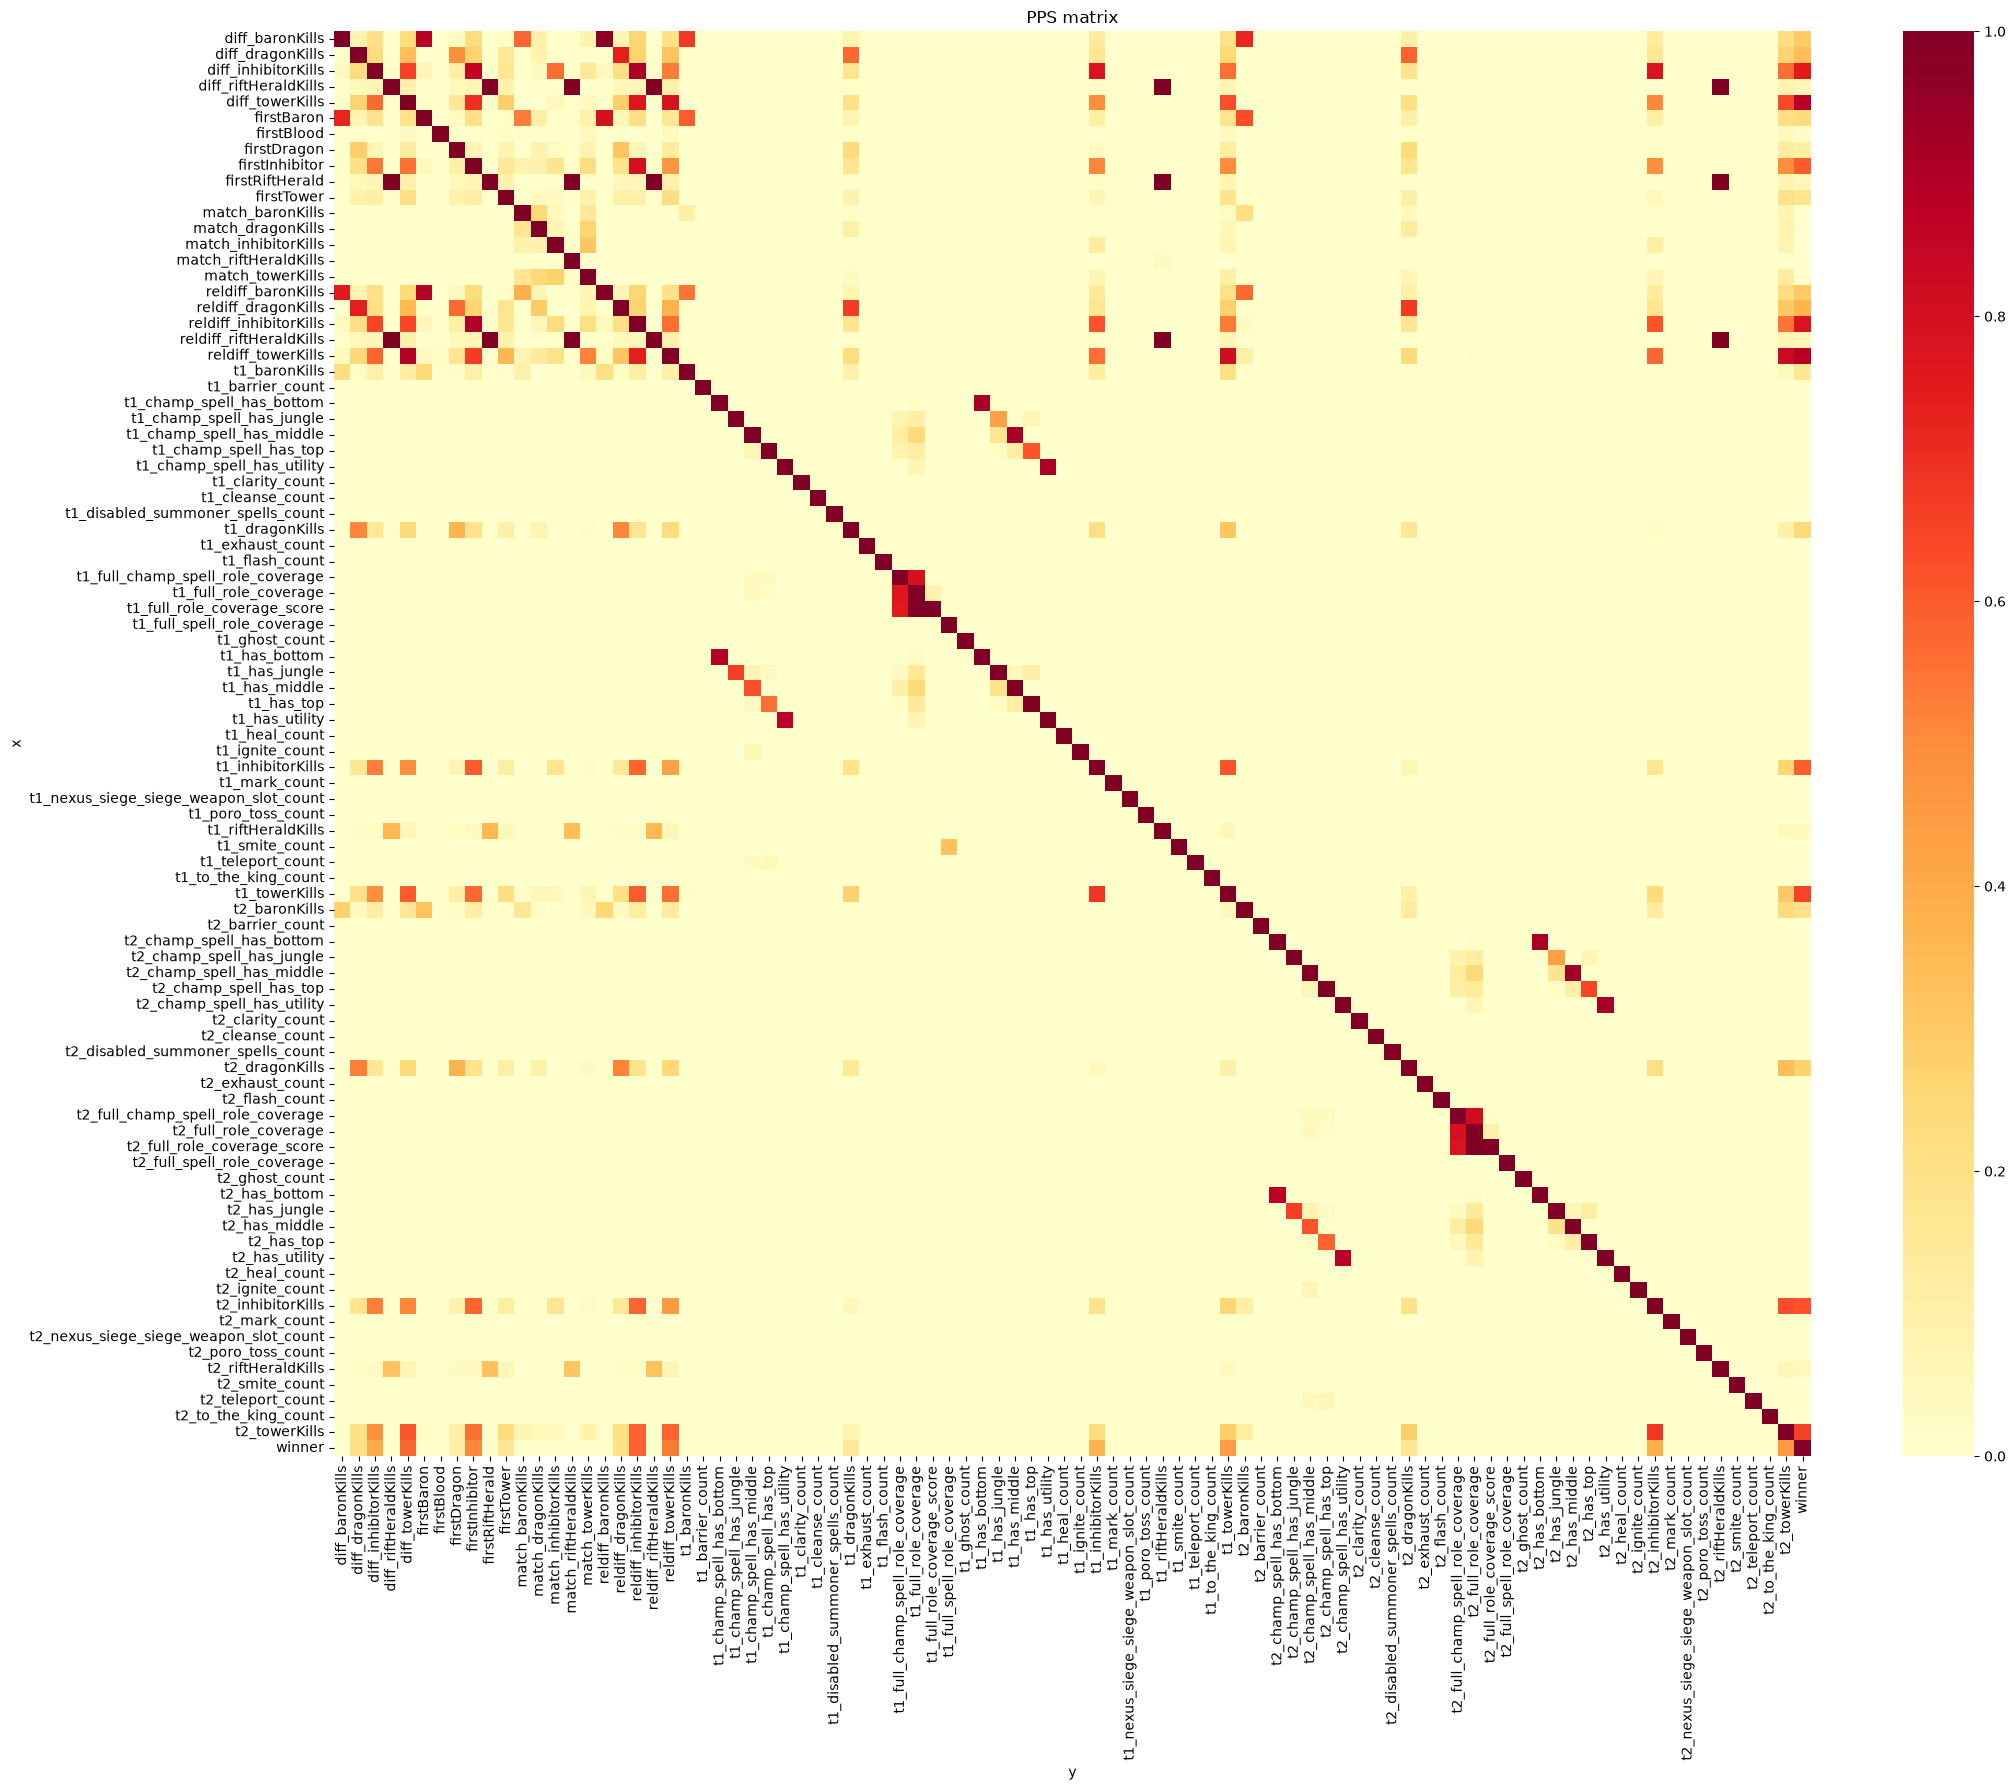

In [35]:
pps_matrix = pps.matrix(
    df_train_features[analysis_cols]
).pivot(
    index='x',
    columns='y',
    values='ppscore'
)

plt.figure(figsize=(22, 18))

sns.heatmap(
    pps_matrix,
    cmap='YlOrRd',
    vmin=0,
    vmax=1
)

plt.title('PPS matrix')
plt.tight_layout()
plt.show()

In [36]:
pps_to_target = (
    pps_matrix['winner']
    .drop('winner')
    .sort_values(ascending=False)
)

pps_to_target.head(30)


x
reldiff_towerKills         0.886090
diff_towerKills            0.880589
reldiff_inhibitorKills     0.780195
diff_inhibitorKills        0.747802
t2_towerKills              0.659623
t1_towerKills              0.652126
t2_inhibitorKills          0.618260
firstInhibitor             0.600517
t1_inhibitorKills          0.591480
reldiff_dragonKills        0.366563
diff_dragonKills           0.339917
reldiff_baronKills         0.297739
diff_baronKills            0.295886
t2_dragonKills             0.272734
t1_dragonKills             0.248117
firstBaron                 0.233282
t2_baronKills              0.192768
firstTower                 0.172378
t1_baronKills              0.160729
firstDragon                0.112371
firstRiftHerald            0.069263
reldiff_riftHeraldKills    0.069263
diff_riftHeraldKills       0.069263
t2_riftHeraldKills         0.047382
t1_riftHeraldKills         0.038640
firstBlood                 0.021733
t1_champ_spell_has_top     0.002077
t1_barrier_count          

In [37]:
pps_pairs = (
    pps_matrix
    .stack()
    .reset_index()
)

pps_pairs.columns = [
    'feature_x',
    'feature_y',
    'pps'
]

pps_pairs = pps_pairs[
    pps_pairs['feature_x'] != pps_pairs['feature_y']
]

pps_pairs = pps_pairs.sort_values(
    'pps',
    ascending=False
)

pps_pairs.head(30)

,feature_x,feature_y,pps
824,firstRiftHerald,match_riftHeraldKills,1.000000
1719,reldiff_riftHeraldKills,firstRiftHerald,1.000000
1713,reldiff_riftHeraldKills,diff_riftHeraldKills,1.000000
1794,reldiff_riftHeraldKills,t2_riftHeraldKills,1.000000
829,firstRiftHerald,reldiff_riftHeraldKills,1.000000
279,diff_riftHeraldKills,firstRiftHerald,1.000000
860,firstRiftHerald,t1_riftHeraldKills,1.000000
1760,reldiff_riftHeraldKills,t1_riftHeraldKills,1.000000
354,diff_riftHeraldKills,t2_riftHeraldKills,1.000000
320,diff_riftHeraldKills,t1_riftHeraldKills,1.000000


**Выводы по анализу новых признаков:**

- Наиболее сильная связь с победителем ожидаемо наблюдается у признаков, непосредственно характеризующих ход матча: получение первых объектов, количество уничтоженных башен, ингибиторов, драконов и других целей.
- Это подтверждает исходную гипотезу о том, что часть признаков содержит информацию уже о фактически сложившемся состоянии матча, поэтому качество модели на полном наборе признаков должно быть значительно выше, чем только по драфту.
- Признаки пиков и банов сильно разрежены, поскольку каждый отдельный чемпион присутствует только в небольшой части матчей. Поэтому небольшая линейная корреляция таких признаков с `winner` сама по себе не означает их бесполезность.
- Признаки покрытия ролей и соответствия заклинаний ролям также имеют слабую индивидуальную связь с таргетом, но могут быть полезны модели в комбинации с конкретными пиками и другими признаками состава.
- Корреляционный анализ позволяет обнаружить признаки, которые практически дублируют друг друга. Дополнительно использую PPS, чтобы учитывать не только линейные зависимости.
- По результатам анализа имеет смысл проверить две стратегии: сохранить практически весь набор созданных признаков и отдельно построить уменьшенную версию, удалив явно слабые и сильно дублирующиеся признаки.

In [ ]:
drop_cols_1a = list(set(
    empty_cols
    + constant_cols
    + ['gameId', 'creationTime', 'seasonId', 'gameDuration']
))

df_start = df_train.drop(
    columns=[
        col for col in drop_cols_1a
        if col in df_train.columns
    ]
).copy()

print('Исходный размер:', df_train.shape)
print('Размер df_start:', df_start.shape)
print('Удалённые признаки:', sorted(drop_cols_1a))

Исходный размер: (40842, 61)
Размер df_start: (40842, 58)
Удалённые признаки: ['creationTime', 'gameId', 'seasonId', 't1_clarity_count', 't1_disabled_summoner_spells_count', 't1_mark_count', 't1_nexus_siege_siege_weapon_slot_count', 't1_poro_toss_count', 't1_to_the_king_count', 't2_clarity_count', 't2_disabled_summoner_spells_count', 't2_mark_count', 't2_nexus_siege_siege_weapon_slot_count', 't2_poro_toss_count', 't2_to_the_king_count']


На основе проведенного анализа создаю несколько вариантов датасета. Это позволит отдельно проверить, действительно ли feature engineering улучшает качество и есть ли смысл в дополнительном сокращении числа признаков.

In [39]:
drop_raw_cols = [
    col for col in df_train_features.columns
    if (
        ('_champ' in col and col.endswith('id'))

        or col.endswith('_sum1')
        or col.endswith('_sum2')

        or col.startswith('t1_ban')
        or col.startswith('t2_ban')
    )
]

drop_cols_1b = list(set(
    empty_cols
    + constant_cols
    + ['gameId', 'creationTime', 'gameDuration']
    + drop_raw_cols
))

df_feature_max = df_train_features.drop(
    columns=[
        col for col in drop_cols_1b
        if col in df_train_features.columns
    ]
).copy()

print('Исходный размер с новыми признаками:', df_train_features.shape)
print('Размер df_feature_max:', df_feature_max.shape)
print('Удалённые признаки:', sorted(drop_cols_1b))

Исходный размер с новыми признаками: (40842, 410)
Размер df_feature_max: (40842, 354)
Удалённые признаки: ['creationTime', 'gameDuration', 'gameId', 'seasonId', 't1_ban1', 't1_ban2', 't1_ban3', 't1_ban4', 't1_ban5', 't1_champ1_sum1', 't1_champ1_sum2', 't1_champ1id', 't1_champ2_sum1', 't1_champ2_sum2', 't1_champ2id', 't1_champ3_sum1', 't1_champ3_sum2', 't1_champ3id', 't1_champ4_sum1', 't1_champ4_sum2', 't1_champ4id', 't1_champ5_sum1', 't1_champ5_sum2', 't1_champ5id', 't1_clarity_count', 't1_disabled_summoner_spells_count', 't1_mark_count', 't1_nexus_siege_siege_weapon_slot_count', 't1_poro_toss_count', 't1_to_the_king_count', 't2_ban1', 't2_ban2', 't2_ban3', 't2_ban4', 't2_ban5', 't2_champ1_sum1', 't2_champ1_sum2', 't2_champ1id', 't2_champ2_sum1', 't2_champ2_sum2', 't2_champ2id', 't2_champ3_sum1', 't2_champ3_sum2', 't2_champ3id', 't2_champ4_sum1', 't2_champ4_sum2', 't2_champ4id', 't2_champ5_sum1', 't2_champ5_sum2', 't2_champ5id', 't2_clarity_count', 't2_disabled_summoner_spells_count', 

In [40]:

TARGET_CORR_THRESHOLD = 0.01
PAIR_CORR_THRESHOLD = 0.95
PAIR_PPS_THRESHOLD = 0.95

df_feature_min = df_feature_max.copy()

drop_cols_feature_min = set()


ban_cols = [
    col for col in df_feature_min.columns
    if (
        col.startswith('t1_ban')
        or col.startswith('t2_ban')
        or col.endswith('_ban')
        or col.startswith('team_') and '_ban' in col
    )
]

drop_cols_feature_min.update(ban_cols)

for feature in df_feature_min.columns:

    if feature == 'winner':
        continue

    if feature not in target_corr.index:
        continue

    corr_with_target = abs(target_corr.loc[feature])

    if (
        feature in pps_matrix.index
        and 'winner' in pps_matrix.columns
    ):
        pps_with_target = pps_matrix.loc[feature, 'winner']
    else:
        continue

    if (
        corr_with_target < TARGET_CORR_THRESHOLD
        and pps_with_target == 0
    ):
        drop_cols_feature_min.add(feature)

def target_score(feature):

    corr_score = 0  
    pps_score = 0

    if feature in target_corr.index:
        corr_score = abs(target_corr.loc[feature])

    if (
        feature in pps_matrix.index
        and 'winner' in pps_matrix.columns
    ):
        pps_score = pps_matrix.loc[feature, 'winner']

    return max(corr_score, pps_score)   

corr_features = [
    col for col in corr.columns
    if col in df_feature_min.columns
]

for i, feature_1 in enumerate(corr_features):

    for feature_2 in corr_features[i + 1:]:

        if (
            feature_1 in drop_cols_feature_min
            or feature_2 in drop_cols_feature_min
        ):
            continue

        pair_corr = abs(
            corr.loc[feature_1, feature_2]
        )

        if pair_corr > PAIR_CORR_THRESHOLD:

            score_1 = target_score(feature_1)
            score_2 = target_score(feature_2)

            if score_1 >= score_2:
                drop_cols_feature_min.add(feature_2)
            else:
                drop_cols_feature_min.add(feature_1)


pps_features = [
    col for col in pps_matrix.index
    if (
        col in df_feature_min.columns
        and col != 'winner'
    )
]

for i, feature_1 in enumerate(pps_features):

    for feature_2 in pps_features[i + 1:]:

        if (
            feature_1 in drop_cols_feature_min
            or feature_2 in drop_cols_feature_min
        ):
            continue

        if (
            feature_2 not in pps_matrix.columns
            or feature_1 not in pps_matrix.columns
        ):
            continue

        pps_1_to_2 = pps_matrix.loc[
            feature_1,
            feature_2
        ]

        pps_2_to_1 = pps_matrix.loc[
            feature_2,  
            feature_1
        ]

        if (
            pps_1_to_2 > PAIR_PPS_THRESHOLD
            and pps_2_to_1 > PAIR_PPS_THRESHOLD
        ):

            score_1 = target_score(feature_1)
            score_2 = target_score(feature_2)

            if score_1 >= score_2:
                drop_cols_feature_min.add(feature_2)
            else:
                drop_cols_feature_min.add(feature_1)


drop_cols_feature_min = [
    col for col in drop_cols_feature_min            
    if col in df_feature_min.columns
]

df_feature_min = df_feature_min.drop(
    columns=drop_cols_feature_min
).copy()


print('Размер df_feature_max:', df_feature_max.shape)
print('Размер df_feature_min:', df_feature_min.shape)

print('\nУдалено признаков:', len(drop_cols_feature_min))

print('\nУдалённые признаки:')
print(sorted(drop_cols_feature_min))

Размер df_feature_max: (40842, 354)
Размер df_feature_min: (40842, 174)

Удалено признаков: 180

Удалённые признаки:
['diff_riftHeraldKills', 'diff_towerKills', 'match_inhibitorKills', 'match_riftHeraldKills', 'reldiff_riftHeraldKills', 't1_barrier_count', 't1_champ_spell_has_bottom', 't1_champ_spell_has_jungle', 't1_champ_spell_has_middle', 't1_champ_spell_has_utility', 't1_cleanse_count', 't1_exhaust_count', 't1_flash_count', 't1_full_role_coverage_score', 't1_ghost_count', 't1_has_jungle', 't1_has_middle', 't1_has_top', 't1_has_utility', 't1_heal_count', 't1_ignite_count', 't1_smite_count', 't1_teleport_count', 't2_barrier_count', 't2_champ_spell_has_bottom', 't2_champ_spell_has_middle', 't2_champ_spell_has_top', 't2_champ_spell_has_utility', 't2_cleanse_count', 't2_exhaust_count', 't2_flash_count', 't2_full_champ_spell_role_coverage', 't2_full_role_coverage', 't2_full_role_coverage_score', 't2_ghost_count', 't2_has_middle', 't2_has_top', 't2_has_utility', 't2_heal_count', 't2_ignit

In [41]:
datasets = {
    'df_start': df_start,
    'df_feature_max': df_feature_max,
    'df_feature_min': df_feature_min
}

check = []

for name, df in datasets.items():
    check.append({
        'dataset': name,
        'rows': df.shape[0],
        'columns': df.shape[1],
        'features': df.shape[1] - 1 if 'winner' in df.columns else df.shape[1],
    })

pd.DataFrame(check)

,dataset,rows,columns,features
0,df_start,40842,58,57
1,df_feature_max,40842,354,353
2,df_feature_min,40842,174,173


**Полученные наборы данных:**

- `df_start` - практически исходный датасет после удаления технических и константных признаков.
- `df_feature_max` - полный набор после feature engineering. Из него удалены исходные ID чемпионов, заклинаний и банов, информация которых уже представлена новыми признаками.
- `df_feature_min` - сокращенная версия полного набора. Из нее дополнительно удаляются слабые относительно таргета и сильно дублирующиеся признаки.

Таким образом, сначала можно проверить сам эффект feature engineering, сравнив `df_start` и `df_feature_max`, а затем понять, дает ли дополнительный отбор признаков преимущество над сохранением максимально полного набора.

In [42]:
df_start.head(5)

,gameDuration,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,1677,2,2,2,2,0,2,2,24,4,11,412,4,3,222,7,4,86,12,4,161,21,4,3,0,0,0,0,23,114,37,75,122,17,21,4,498,7,4,89,4,14,5,11,6,61,4,21,10,3,0,3,1,11,31,119,67,84
1,1223,1,1,1,0,0,2,0,81,4,7,266,12,4,16,3,4,105,4,11,91,4,14,5,0,0,0,0,164,53,29,45,75,157,4,14,22,4,7,516,4,3,6,4,12,64,4,11,0,0,0,1,0,1,238,40,498,31
2,1371,2,2,1,2,0,2,2,202,7,4,420,12,4,34,14,4,412,4,14,35,14,11,1,0,0,0,0,122,117,1,38,40,16,3,4,157,4,12,29,4,7,32,4,11,17,4,14,8,1,0,2,1,31,113,40,12,53
3,1607,1,1,1,1,0,1,0,412,3,4,86,4,12,24,4,11,29,4,7,7,4,12,11,3,0,2,0,25,157,11,122,53,238,4,14,104,4,11,516,12,3,18,4,7,44,4,3,0,0,0,0,0,17,103,23,5,91
4,1414,1,2,1,1,0,1,0,23,4,14,17,3,4,111,6,11,134,4,14,202,7,4,11,3,0,1,0,157,64,67,38,122,81,4,7,24,4,12,223,3,4,56,4,11,50,14,4,0,0,0,0,0,64,157,122,6,119


In [43]:
df_feature_max.head(5)

,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,annie_pick,olaf_pick,galio_pick,twisted_fate_pick,xin_zhao_pick,urgot_pick,leblanc_pick,vladimir_pick,fiddlesticks_pick,kayle_pick,master_yi_pick,alistar_pick,ryze_pick,sion_pick,sivir_pick,soraka_pick,teemo_pick,tristana_pick,warwick_pick,nunu_pick,miss_fortune_pick,ashe_pick,tryndamere_pick,jax_pick,morgana_pick,zilean_pick,singed_pick,evelynn_pick,twitch_pick,karthus_pick,cho_gath_pick,amumu_pick,rammus_pick,anivia_pick,shaco_pick,dr_mundo_pick,sona_pick,kassadin_pick,irelia_pick,janna_pick,gangplank_pick,corki_pick,karma_pick,taric_pick,veigar_pick,trundle_pick,swain_pick,caitlyn_pick,blitzcrank_pick,malphite_pick,katarina_pick,nocturne_pick,maokai_pick,renekton_pick,jarvan_iv_pick,elise_pick,orianna_pick,wukong_pick,brand_pick,lee_sin_pick,vayne_pick,rumble_pick,cassiopeia_pick,skarner_pick,heimerdinger_pick,nasus_pick,nidalee_pick,udyr_pick,poppy_pick,gragas_pick,pantheon_pick,ezreal_pick,mordekaiser_pick,yorick_pick,akali_pick,kennen_pick,garen_pick,leona_pick,malzahar_pick,talon_pick,riven_pick,kog_maw_pick,shen_pick,lux_pick,xerath_pick,shyvana_pick,ahri_pick,graves_pick,fizz_pick,volibear_pick,rengar_pick,varus_pick,nautilus_pick,viktor_pick,sejuani_pick,fiora_pick,ziggs_pick,lulu_pick,draven_pick,hecarim_pick,kha_zix_pick,darius_pick,jayce_pick,lissandra_pick,diana_pick,quinn_pick,syndra_pick,aurelion_sol_pick,kayn_pick,zyra_pick,gnar_pick,zac_pick,yasuo_pick,vel_koz_pick,taliyah_pick,camille_pick,braum_pick,jhin_pick,kindred_pick,jinx_pick,tahm_kench_pick,lucian_pick,zed_pick,kled_pick,ekko_pick,vi_pick,aatrox_pick,nami_pick,azir_pick,thresh_pick,illaoi_pick,rek_sai_pick,ivern_pick,kalista_pick,bard_pick,rakan_pick,xayah_pick,ornn_pick,t1_has_top,t1_has_jungle,t1_has_middle,t1_has_bottom,t1_has_utility,t2_has_top,t2_has_jungle,t2_has_middle,t2_has_bottom,t2_has_utility,t1_full_role_coverage,t1_full_role_coverage_score,t2_full_role_coverage,t2_full_role_coverage_score,team_annie_ban,team_olaf_ban,team_galio_ban,team_twisted_fate_ban,team_xin_zhao_ban,team_urgot_ban,team_leblanc_ban,team_vladimir_ban,team_fiddlesticks_ban,team_kayle_ban,team_master_yi_ban,team_alistar_ban,team_ryze_ban,team_sion_ban,team_sivir_ban,team_soraka_ban,team_teemo_ban,team_tristana_ban,team_warwick_ban,team_nunu_ban,team_miss_fortune_ban,team_ashe_ban,team_tryndamere_ban,team_jax_ban,team_morgana_ban,team_zilean_ban,team_singed_ban,team_evelynn_ban,team_twitch_ban,team_karthus_ban,team_cho_gath_ban,team_amumu_ban,team_rammus_ban,team_anivia_ban,team_shaco_ban,team_dr_mundo_ban,team_sona_ban,team_kassadin_ban,team_irelia_ban,team_janna_ban,team_gangplank_ban,team_corki_ban,team_karma_ban,team_taric_ban,team_veigar_ban,team_trundle_ban,team_swain_ban,team_caitlyn_ban,team_blitzcrank_ban,team_malphite_ban,team_katarina_ban,team_nocturne_ban,team_maokai_ban,team_renekton_ban,team_jarvan_iv_ban,team_elise_ban,team_orianna_ban,team_wukong_ban,team_brand_ban,team_lee_sin_ban,team_vayne_ban,team_rumble_ban,team_cassiopeia_ban,team_skarner_ban,team_heimerdinger_ban,team_nasus_ban,team_nidalee_ban,team_udyr_ban,team_poppy_ban,team_gragas_ban,team_pantheon_ban,team_ezreal_ban,team_mordekaiser_ban,team_yorick_ban,team_akali_ban,team_kennen_ban,team_garen_ban,team_leona_ban,team_malzahar_ban,team_talon_ban,team_riven_ban,team_kog_maw_ban,team_shen_ban,team_lux_ban,team_xerath_ban,team_shyvana_ban,team_ahri_ban,team_graves_ban,team_fizz_ban,team_volibear_ban,team_rengar_ban,team_varus_ban,team_nautilus_ban,team_viktor_ban,team_sejuani_ban,team_fiora_ban,team_ziggs_ban,team_lulu_ban,team_draven_ban,team_hecarim_ban,team_kha_zix_ban,team_darius_ban,team_jayce_ban,team_lissandra_ban,team_diana_ban,team_quinn_ban,team_syndra_ban,team_aurelion_sol_ban,team_kayn_ban,team_zyra_ban,team_gnar_ban,team_zac_ban,team_yasuo_ban

In [44]:
df_feature_min.head(5)

,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,annie_pick,olaf_pick,galio_pick,twisted_fate_pick,xin_zhao_pick,urgot_pick,leblanc_pick,vladimir_pick,fiddlesticks_pick,kayle_pick,master_yi_pick,alistar_pick,ryze_pick,sion_pick,sivir_pick,soraka_pick,teemo_pick,tristana_pick,warwick_pick,nunu_pick,miss_fortune_pick,ashe_pick,tryndamere_pick,jax_pick,morgana_pick,zilean_pick,singed_pick,evelynn_pick,twitch_pick,karthus_pick,cho_gath_pick,amumu_pick,rammus_pick,anivia_pick,shaco_pick,dr_mundo_pick,sona_pick,kassadin_pick,irelia_pick,janna_pick,gangplank_pick,corki_pick,karma_pick,taric_pick,veigar_pick,trundle_pick,swain_pick,caitlyn_pick,blitzcrank_pick,malphite_pick,katarina_pick,nocturne_pick,maokai_pick,renekton_pick,jarvan_iv_pick,elise_pick,orianna_pick,wukong_pick,brand_pick,lee_sin_pick,vayne_pick,rumble_pick,cassiopeia_pick,skarner_pick,heimerdinger_pick,nasus_pick,nidalee_pick,udyr_pick,poppy_pick,gragas_pick,pantheon_pick,ezreal_pick,mordekaiser_pick,yorick_pick,akali_pick,kennen_pick,garen_pick,leona_pick,malzahar_pick,talon_pick,riven_pick,kog_maw_pick,shen_pick,lux_pick,xerath_pick,shyvana_pick,ahri_pick,graves_pick,fizz_pick,volibear_pick,rengar_pick,varus_pick,nautilus_pick,viktor_pick,sejuani_pick,fiora_pick,ziggs_pick,lulu_pick,draven_pick,hecarim_pick,kha_zix_pick,darius_pick,jayce_pick,lissandra_pick,diana_pick,quinn_pick,syndra_pick,aurelion_sol_pick,kayn_pick,zyra_pick,gnar_pick,zac_pick,yasuo_pick,vel_koz_pick,taliyah_pick,camille_pick,braum_pick,jhin_pick,kindred_pick,jinx_pick,tahm_kench_pick,lucian_pick,zed_pick,kled_pick,ekko_pick,vi_pick,aatrox_pick,nami_pick,azir_pick,thresh_pick,illaoi_pick,rek_sai_pick,ivern_pick,kalista_pick,bard_pick,rakan_pick,xayah_pick,ornn_pick,t1_has_bottom,t2_has_jungle,t2_has_bottom,t1_full_role_coverage,t1_full_spell_role_coverage,t2_full_spell_role_coverage,t1_champ_spell_has_top,t2_champ_spell_has_jungle,t1_full_champ_spell_role_coverage,match_towerKills,match_baronKills,match_dragonKills,diff_inhibitorKills,diff_baronKills,diff_dragonKills,reldiff_towerKills,reldiff_inhibitorKills,reldiff_baronKills,reldiff_dragonKills
0,2,-1,-1,-1,0,-1,-1,3,0,0,0,0,10,3,0,3,1,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,-1,0,7.259,1.151,1.580,0,1,1,6.284,2.302,0,13,0,3,-3,0,-3,-0.538462,-1.0,0.0,-1.0
1,1,1,1,0,0,-1,0,5,0,0,0,0,0,0,0,1,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,-1,5.785,4.960,3.349,1,1,1,6.386,9.920,0,5,0,1,0,0,-1,1.000000,0.0,0.0,-1.0
2,2,-1,1,-1,0,-1,-1,1,0,0,0,0,8,1,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,-1,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,6.527,1.436,2.762,1,1,1,2.020,2.872,1,9,0,2,-1,0,-2,-0.777778,-1.0,0.0,-1.0
3,1,1,1,1,0,1,0,11,3,0,2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,-1,2.762,3.000,2.134,1,1,1,6.284,3.952,1,11,0,2,3,0,2,1.000000,1.0,0.0,1.0
4,1,-1,1,1,0,1,0,11,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,

## Baseline

Сначала сравню простой линейный алгоритм и одиночное дерево решений. Для каждой модели гиперпараметры подбираются внутри `RandomizedSearchCV`, а итоговое качество оценивается на внешней 5-fold кросс-валидации.

Основной метрикой использую `F1 macro`, так как она одновременно учитывает precision и recall обоих классов. Дополнительно сохраняю accuracy, balanced accuracy, precision, recall и ROC-AUC.

На этом этапе сравниваются `df_start`, `df_feature_max` и `df_feature_min`, чтобы определить, дает ли созданный feature engineering преимущество и необходимо ли сильное сокращение числа признаков.

In [45]:
datasets = {
    'start': df_start,
    'feature_max': df_feature_max,
    'feature_min': df_feature_min
}

models = {
    'LogisticRegression': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                max_iter=2000,
                random_state=42
            ))
        ]),
        'params': {
            'model__C': np.logspace(-2, 2, 20),
            'model__l1_ratio': [0.0, 1.0],
            'model__solver': ['liblinear']
        }
    },

    'DecisionTree': {
        'model': DecisionTreeClassifier(
            random_state=42
        ),
        'params': {
            'max_depth': [3, 5, 7, 10, 15, None],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    }
}

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

results = []

for dataset_name, df in datasets.items():

    X = df.drop(columns='winner')
    y = df['winner']

    for model_name, config in models.items():

        fold_metrics = []

        start_time = time.time()

        for fold, (train_idx, valid_idx) in enumerate(
            outer_cv.split(X, y),
            start=1
        ):

            print(
                f'Dataset: {dataset_name} | '
                f'Model: {model_name} | '
                f'Fold: {fold}/5'
            )

            X_train = X.iloc[train_idx]
            X_valid = X.iloc[valid_idx]

            y_train = y.iloc[train_idx]
            y_valid = y.iloc[valid_idx]

            search = RandomizedSearchCV(
                estimator=config['model'],
                param_distributions=config['params'],
                n_iter=8,
                scoring='f1_macro',
                cv=inner_cv,
                n_jobs=-1,
                random_state=42
            )

            search.fit(X_train, y_train)

            best_model = search.best_estimator_

            y_pred = best_model.predict(X_valid)
            y_proba = best_model.predict_proba(X_valid)[:, 1]

            fold_metrics.append({
                'accuracy': accuracy_score(
                    y_valid,
                    y_pred
                ),

                'balanced_accuracy': balanced_accuracy_score(
                    y_valid,
                    y_pred
                ),

                'precision': precision_score(
                    y_valid,
                    y_pred,
                    average='macro'
                ),

                'recall': recall_score(
                    y_valid,
                    y_pred,
                    average='macro'
                ),

                'f1': f1_score(
                    y_valid,
                    y_pred,
                    average='macro'
                ),

                'roc_auc': roc_auc_score(
                    y_valid,
                    y_proba
                )
            })

        training_time = time.time() - start_time

        fold_metrics = pd.DataFrame(fold_metrics)

        results.append({
            'dataset': dataset_name,
            'model': model_name,

            'accuracy_mean': fold_metrics['accuracy'].mean(),
            'accuracy_std': fold_metrics['accuracy'].std(),

            'balanced_accuracy_mean': fold_metrics['balanced_accuracy'].mean(),
            'balanced_accuracy_std': fold_metrics['balanced_accuracy'].std(),

            'precision_mean': fold_metrics['precision'].mean(),
            'precision_std': fold_metrics['precision'].std(),

            'recall_mean': fold_metrics['recall'].mean(),
            'recall_std': fold_metrics['recall'].std(),

            'f1_mean': fold_metrics['f1'].mean(),
            'f1_std': fold_metrics['f1'].std(),

            'roc_auc_mean': fold_metrics['roc_auc'].mean(),
            'roc_auc_std': fold_metrics['roc_auc'].std(),

            'training_time': training_time
        })

baseline_results = pd.DataFrame(results)

baseline_results = baseline_results.sort_values(
    'f1_mean',
    ascending=False
).reset_index(drop=True)

baseline_results.round(4)

Dataset: start | Model: LogisticRegression | Fold: 1/5
Dataset: start | Model: LogisticRegression | Fold: 2/5
Dataset: start | Model: LogisticRegression | Fold: 3/5
Dataset: start | Model: LogisticRegression | Fold: 4/5
Dataset: start | Model: LogisticRegression | Fold: 5/5
Dataset: start | Model: DecisionTree | Fold: 1/5
Dataset: start | Model: DecisionTree | Fold: 2/5
Dataset: start | Model: DecisionTree | Fold: 3/5
Dataset: start | Model: DecisionTree | Fold: 4/5
Dataset: start | Model: DecisionTree | Fold: 5/5
Dataset: feature_max | Model: LogisticRegression | Fold: 1/5
Dataset: feature_max | Model: LogisticRegression | Fold: 2/5
Dataset: feature_max | Model: LogisticRegression | Fold: 3/5
Dataset: feature_max | Model: LogisticRegression | Fold: 4/5
Dataset: feature_max | Model: LogisticRegression | Fold: 5/5
Dataset: feature_max | Model: DecisionTree | Fold: 1/5
Dataset: feature_max | Model: DecisionTree | Fold: 2/5
Dataset: feature_max | Model: DecisionTree | Fold: 3/5
Dataset: f

,dataset,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,training_time
0,feature_min,LogisticRegression,0.9698,0.0025,0.9698,0.0025,0.9698,0.0024,0.9698,0.0025,0.9698,0.0025,0.9973,0.0003,116.4265
1,feature_max,LogisticRegression,0.9690,0.0017,0.9690,0.0017,0.9690,0.0016,0.9690,0.0017,0.9690,0.0017,0.9971,0.0003,250.3148
2,feature_min,DecisionTree,0.9684,0.0013,0.9683,0.0013,0.9686,0.0012,0.9683,0.0013,0.9684,0.0013,0.9955,0.0002,9.7739
3,feature_max,DecisionTree,0.9680,0.0014,0.9679,0.0014,0.9682,0.0013,0.9679,0.0014,0.9680,0.0014,0.9950,0.0004,19.4128
4,start,DecisionTree,0.9677,0.0020,0.9677,0.0020,0.9677,0.0020,0.9677,0.0020,0.9677,0.0020,0.9948,0.0007,6.5555
5,start,LogisticRegression,0.9612,0.0012,0.9612,0.0012,0.9612,0.0012,0.9612,0.0012,0.9612,0.0012,0.9946,0.0004,37.0691


**Выводы по baseline:**

Feature engineering заметно улучшил Logistic Regression: `F1` вырос с `0.9612` на `df_start` до `0.9690` на `df_feature_max` и `0.9698` на `df_feature_min`. Для Decision Tree разница намного меньше: `0.9677` → `0.9680` → `0.9684`.

`df_feature_min` формально показывает лучший результат, но преимущество над `df_feature_max` меньше `0.001 F1` и сопоставимо с разбросом между фолдами. При этом сокращённый набор заметно быстрее: для Logistic Regression около `116` секунд против `250`, для Decision Tree - около `10` против `19`.

Дальше использую `df_feature_max`: по качеству он практически не уступает сокращённой версии, но сохраняет весь созданный набор признаков.


## Разбиение данных по этапам матча

Для основной гипотезы проекта одного полного набора данных недостаточно. Часть признаков известна еще до начала матча, часть появляется во время игры, а некоторые фактически отражают уже почти итоговое состояние матча.

Поэтому создаю три уровня доступной информации:

- `draft` - только информация, известная до начала игры: пики, баны, роли и заклинания;
- `early_game` - драфт и события, происходящие во время матча, но без итоговых количеств уничтоженных объектов и созданных из них разностей;
- `full` - весь доступный набор признаков.

Такое разделение позволит проверить, насколько предсказуем исход матча на разных этапах и какая часть качества модели появляется именно за счет информации о ходе игры.

In [46]:
end_game_cols = [
    't1_towerKills',
    't1_inhibitorKills',
    't1_baronKills',
    't1_dragonKills',
    't1_riftHeraldKills',
    't2_towerKills',
    't2_inhibitorKills',
    't2_baronKills',
    't2_dragonKills',
    't2_riftHeraldKills'
]

end_game_engineered = [
    col for col in df_feature_max.columns
    if (
        col.startswith('match_')
        or col.startswith('diff_')
        or col.startswith('reldiff_')
    )
]

df_early_game = df_feature_max.drop(
    columns=end_game_cols + end_game_engineered,
    errors='ignore'
).copy()

print('df_feature_max:', df_feature_max.shape)
print('df_early_game:', df_early_game.shape)

df_feature_max: (40842, 354)
df_early_game: (40842, 329)


In [47]:
draft_cols = [
    col for col in df_feature_max.columns
    if (
        col.endswith('_pick')
        or col.endswith('_ban')
        or '_has_' in col
        or col.endswith('_count')
        or 'full_role_coverage' in col
        or 'full_spell_role_coverage' in col
        or 'champ_spell_has_' in col
        or 'full_champ_spell_role_coverage' in col
    )
]

df_draft = df_feature_max[
    ['winner'] + draft_cols
].copy()

print('df_feature_max:', df_feature_max.shape)
print('df_draft:', df_draft.shape)

df_feature_max: (40842, 354)
df_draft: (40842, 323)


In [48]:
df_early_game.head(5)

,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,annie_pick,olaf_pick,galio_pick,twisted_fate_pick,xin_zhao_pick,urgot_pick,leblanc_pick,vladimir_pick,fiddlesticks_pick,kayle_pick,master_yi_pick,alistar_pick,ryze_pick,sion_pick,sivir_pick,soraka_pick,teemo_pick,tristana_pick,warwick_pick,nunu_pick,miss_fortune_pick,ashe_pick,tryndamere_pick,jax_pick,morgana_pick,zilean_pick,singed_pick,evelynn_pick,twitch_pick,karthus_pick,cho_gath_pick,amumu_pick,rammus_pick,anivia_pick,shaco_pick,dr_mundo_pick,sona_pick,kassadin_pick,irelia_pick,janna_pick,gangplank_pick,corki_pick,karma_pick,taric_pick,veigar_pick,trundle_pick,swain_pick,caitlyn_pick,blitzcrank_pick,malphite_pick,katarina_pick,nocturne_pick,maokai_pick,renekton_pick,jarvan_iv_pick,elise_pick,orianna_pick,wukong_pick,brand_pick,lee_sin_pick,vayne_pick,rumble_pick,cassiopeia_pick,skarner_pick,heimerdinger_pick,nasus_pick,nidalee_pick,udyr_pick,poppy_pick,gragas_pick,pantheon_pick,ezreal_pick,mordekaiser_pick,yorick_pick,akali_pick,kennen_pick,garen_pick,leona_pick,malzahar_pick,talon_pick,riven_pick,kog_maw_pick,shen_pick,lux_pick,xerath_pick,shyvana_pick,ahri_pick,graves_pick,fizz_pick,volibear_pick,rengar_pick,varus_pick,nautilus_pick,viktor_pick,sejuani_pick,fiora_pick,ziggs_pick,lulu_pick,draven_pick,hecarim_pick,kha_zix_pick,darius_pick,jayce_pick,lissandra_pick,diana_pick,quinn_pick,syndra_pick,aurelion_sol_pick,kayn_pick,zyra_pick,gnar_pick,zac_pick,yasuo_pick,vel_koz_pick,taliyah_pick,camille_pick,braum_pick,jhin_pick,kindred_pick,jinx_pick,tahm_kench_pick,lucian_pick,zed_pick,kled_pick,ekko_pick,vi_pick,aatrox_pick,nami_pick,azir_pick,thresh_pick,illaoi_pick,rek_sai_pick,ivern_pick,kalista_pick,bard_pick,rakan_pick,xayah_pick,ornn_pick,t1_has_top,t1_has_jungle,t1_has_middle,t1_has_bottom,t1_has_utility,t2_has_top,t2_has_jungle,t2_has_middle,t2_has_bottom,t2_has_utility,t1_full_role_coverage,t1_full_role_coverage_score,t2_full_role_coverage,t2_full_role_coverage_score,team_annie_ban,team_olaf_ban,team_galio_ban,team_twisted_fate_ban,team_xin_zhao_ban,team_urgot_ban,team_leblanc_ban,team_vladimir_ban,team_fiddlesticks_ban,team_kayle_ban,team_master_yi_ban,team_alistar_ban,team_ryze_ban,team_sion_ban,team_sivir_ban,team_soraka_ban,team_teemo_ban,team_tristana_ban,team_warwick_ban,team_nunu_ban,team_miss_fortune_ban,team_ashe_ban,team_tryndamere_ban,team_jax_ban,team_morgana_ban,team_zilean_ban,team_singed_ban,team_evelynn_ban,team_twitch_ban,team_karthus_ban,team_cho_gath_ban,team_amumu_ban,team_rammus_ban,team_anivia_ban,team_shaco_ban,team_dr_mundo_ban,team_sona_ban,team_kassadin_ban,team_irelia_ban,team_janna_ban,team_gangplank_ban,team_corki_ban,team_karma_ban,team_taric_ban,team_veigar_ban,team_trundle_ban,team_swain_ban,team_caitlyn_ban,team_blitzcrank_ban,team_malphite_ban,team_katarina_ban,team_nocturne_ban,team_maokai_ban,team_renekton_ban,team_jarvan_iv_ban,team_elise_ban,team_orianna_ban,team_wukong_ban,team_brand_ban,team_lee_sin_ban,team_vayne_ban,team_rumble_ban,team_cassiopeia_ban,team_skarner_ban,team_heimerdinger_ban,team_nasus_ban,team_nidalee_ban,team_udyr_ban,team_poppy_ban,team_gragas_ban,team_pantheon_ban,team_ezreal_ban,team_mordekaiser_ban,team_yorick_ban,team_akali_ban,team_kennen_ban,team_garen_ban,team_leona_ban,team_malzahar_ban,team_talon_ban,team_riven_ban,team_kog_maw_ban,team_shen_ban,team_lux_ban,team_xerath_ban,team_shyvana_ban,team_ahri_ban,team_graves_ban,team_fizz_ban,team_volibear_ban,team_rengar_ban,team_varus_ban,team_nautilus_ban,team_viktor_ban,team_sejuani_ban,team_fiora_ban,team_ziggs_ban,team_lulu_ban,team_draven_ban,team_hecarim_ban,team_kha_zix_ban,team_darius_ban,team_jayce_ban,team_lissandra_ban,team_diana_ban,team_quinn_ban,team_syndra_ban,team_aurelion_sol_ban,team_kayn_ban,team_zyra_ban,team_gnar_ban,team_zac_ban,team_yasuo_ban,team_vel_koz_ban,team_taliyah_ban,team_camille_ban,team_braum_ban,team_jhin_ban,team_kindred_ban,team_jinx_ban,team_tahm_kench_ban,team_lucian_ban,team_zed_ban

In [49]:
df_draft.head(5)

,winner,annie_pick,olaf_pick,galio_pick,twisted_fate_pick,xin_zhao_pick,urgot_pick,leblanc_pick,vladimir_pick,fiddlesticks_pick,kayle_pick,master_yi_pick,alistar_pick,ryze_pick,sion_pick,sivir_pick,soraka_pick,teemo_pick,tristana_pick,warwick_pick,nunu_pick,miss_fortune_pick,ashe_pick,tryndamere_pick,jax_pick,morgana_pick,zilean_pick,singed_pick,evelynn_pick,twitch_pick,karthus_pick,cho_gath_pick,amumu_pick,rammus_pick,anivia_pick,shaco_pick,dr_mundo_pick,sona_pick,kassadin_pick,irelia_pick,janna_pick,gangplank_pick,corki_pick,karma_pick,taric_pick,veigar_pick,trundle_pick,swain_pick,caitlyn_pick,blitzcrank_pick,malphite_pick,katarina_pick,nocturne_pick,maokai_pick,renekton_pick,jarvan_iv_pick,elise_pick,orianna_pick,wukong_pick,brand_pick,lee_sin_pick,vayne_pick,rumble_pick,cassiopeia_pick,skarner_pick,heimerdinger_pick,nasus_pick,nidalee_pick,udyr_pick,poppy_pick,gragas_pick,pantheon_pick,ezreal_pick,mordekaiser_pick,yorick_pick,akali_pick,kennen_pick,garen_pick,leona_pick,malzahar_pick,talon_pick,riven_pick,kog_maw_pick,shen_pick,lux_pick,xerath_pick,shyvana_pick,ahri_pick,graves_pick,fizz_pick,volibear_pick,rengar_pick,varus_pick,nautilus_pick,viktor_pick,sejuani_pick,fiora_pick,ziggs_pick,lulu_pick,draven_pick,hecarim_pick,kha_zix_pick,darius_pick,jayce_pick,lissandra_pick,diana_pick,quinn_pick,syndra_pick,aurelion_sol_pick,kayn_pick,zyra_pick,gnar_pick,zac_pick,yasuo_pick,vel_koz_pick,taliyah_pick,camille_pick,braum_pick,jhin_pick,kindred_pick,jinx_pick,tahm_kench_pick,lucian_pick,zed_pick,kled_pick,ekko_pick,vi_pick,aatrox_pick,nami_pick,azir_pick,thresh_pick,illaoi_pick,rek_sai_pick,ivern_pick,kalista_pick,bard_pick,rakan_pick,xayah_pick,ornn_pick,t1_has_top,t1_has_jungle,t1_has_middle,t1_has_bottom,t1_has_utility,t2_has_top,t2_has_jungle,t2_has_middle,t2_has_bottom,t2_has_utility,t1_full_role_coverage,t1_full_role_coverage_score,t2_full_role_coverage,t2_full_role_coverage_score,team_annie_ban,team_olaf_ban,team_galio_ban,team_twisted_fate_ban,team_xin_zhao_ban,team_urgot_ban,team_leblanc_ban,team_vladimir_ban,team_fiddlesticks_ban,team_kayle_ban,team_master_yi_ban,team_alistar_ban,team_ryze_ban,team_sion_ban,team_sivir_ban,team_soraka_ban,team_teemo_ban,team_tristana_ban,team_warwick_ban,team_nunu_ban,team_miss_fortune_ban,team_ashe_ban,team_tryndamere_ban,team_jax_ban,team_morgana_ban,team_zilean_ban,team_singed_ban,team_evelynn_ban,team_twitch_ban,team_karthus_ban,team_cho_gath_ban,team_amumu_ban,team_rammus_ban,team_anivia_ban,team_shaco_ban,team_dr_mundo_ban,team_sona_ban,team_kassadin_ban,team_irelia_ban,team_janna_ban,team_gangplank_ban,team_corki_ban,team_karma_ban,team_taric_ban,team_veigar_ban,team_trundle_ban,team_swain_ban,team_caitlyn_ban,team_blitzcrank_ban,team_malphite_ban,team_katarina_ban,team_nocturne_ban,team_maokai_ban,team_renekton_ban,team_jarvan_iv_ban,team_elise_ban,team_orianna_ban,team_wukong_ban,team_brand_ban,team_lee_sin_ban,team_vayne_ban,team_rumble_ban,team_cassiopeia_ban,team_skarner_ban,team_heimerdinger_ban,team_nasus_ban,team_nidalee_ban,team_udyr_ban,team_poppy_ban,team_gragas_ban,team_pantheon_ban,team_ezreal_ban,team_mordekaiser_ban,team_yorick_ban,team_akali_ban,team_kennen_ban,team_garen_ban,team_leona_ban,team_malzahar_ban,team_talon_ban,team_riven_ban,team_kog_maw_ban,team_shen_ban,team_lux_ban,team_xerath_ban,team_shyvana_ban,team_ahri_ban,team_graves_ban,team_fizz_ban,team_volibear_ban,team_rengar_ban,team_varus_ban,team_nautilus_ban,team_viktor_ban,team_sejuani_ban,team_fiora_ban,team_ziggs_ban,team_lulu_ban,team_draven_ban,team_hecarim_ban,team_kha_zix_ban,team_darius_ban,team_jayce_ban,team_lissandra_ban,team_diana_ban,team_quinn_ban,team_syndra_ban,team_aurelion_sol_ban,team_kayn_ban,team_zyra_ban,team_gnar_ban,team_zac_ban,team_yasuo_ban,team_vel_koz_ban,team_taliyah_ban,team_camille_ban,team_braum_ban,team_jhin_ban,team_kindred_ban,team_jinx_ban,team_tahm_kench_ban,team_lucian_ban,team_zed_ban,team_kled_ban,team_ekko_ban,team_vi_ban,team_aatrox_ban,team_nami_ban,team_

In [50]:
datasets = {
    'early_game': df_early_game,
    'draft': df_draft
}

models = {
    'LogisticRegression': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                max_iter=2000,
                random_state=42,
                solver='liblinear'
            ))
        ]),
        'params': {
            'model__C': np.logspace(-2, 2, 20),
            'model__l1_ratio': [0.0, 1.0]
        }
    },

    'DecisionTree': {
        'model': DecisionTreeClassifier(
            random_state=42
        ),
        'params': {
            'max_depth': [3, 5, 7, 10, 15, None],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    }
}

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

results = []

for dataset_name, df in datasets.items():

    X = df.drop(columns='winner')
    y = df['winner']

    for model_name, config in models.items():

        fold_metrics = []

        start_time = time.time()

        for fold, (train_idx, valid_idx) in enumerate(
            outer_cv.split(X, y),
            start=1
        ):

            print(
                f'Dataset: {dataset_name} | '
                f'Model: {model_name} | '
                f'Fold: {fold}/5'
            )

            X_train = X.iloc[train_idx]
            X_valid = X.iloc[valid_idx]

            y_train = y.iloc[train_idx]
            y_valid = y.iloc[valid_idx]

            search = RandomizedSearchCV(
                estimator=config['model'],
                param_distributions=config['params'],
                n_iter=8,
                scoring='f1_macro',
                cv=inner_cv,
                n_jobs=-1,
                random_state=42
            )

            search.fit(X_train, y_train)

            best_model = search.best_estimator_

            y_pred = best_model.predict(X_valid)
            y_proba = best_model.predict_proba(X_valid)[:, 1]

            fold_metrics.append({
                'accuracy': accuracy_score(
                    y_valid,
                    y_pred
                ),

                'balanced_accuracy': balanced_accuracy_score(
                    y_valid,
                    y_pred
                ),

                'precision': precision_score(
                    y_valid,
                    y_pred,
                    average='macro'
                ),

                'recall': recall_score(
                    y_valid,
                    y_pred,
                    average='macro'
                ),

                'f1': f1_score(
                    y_valid,
                    y_pred,
                    average='macro'
                ),

                'roc_auc': roc_auc_score(
                    y_valid,
                    y_proba
                )
            })

        training_time = time.time() - start_time

        fold_metrics = pd.DataFrame(fold_metrics)

        results.append({
            'dataset': dataset_name,
            'model': model_name,

            'accuracy_mean': fold_metrics['accuracy'].mean(),
            'accuracy_std': fold_metrics['accuracy'].std(),

            'balanced_accuracy_mean': fold_metrics['balanced_accuracy'].mean(),
            'balanced_accuracy_std': fold_metrics['balanced_accuracy'].std(),

            'precision_mean': fold_metrics['precision'].mean(),
            'precision_std': fold_metrics['precision'].std(),

            'recall_mean': fold_metrics['recall'].mean(),
            'recall_std': fold_metrics['recall'].std(),

            'f1_mean': fold_metrics['f1'].mean(),
            'f1_std': fold_metrics['f1'].std(),

            'roc_auc_mean': fold_metrics['roc_auc'].mean(),
            'roc_auc_std': fold_metrics['roc_auc'].std(),

            'training_time': training_time
        })

new_baseline_results = pd.DataFrame(results)

new_baseline_results = new_baseline_results.sort_values(
    'f1_mean',
    ascending=False
).reset_index(drop=True)

new_baseline_results.round(4)

Dataset: early_game | Model: LogisticRegression | Fold: 1/5
Dataset: early_game | Model: LogisticRegression | Fold: 2/5
Dataset: early_game | Model: LogisticRegression | Fold: 3/5
Dataset: early_game | Model: LogisticRegression | Fold: 4/5
Dataset: early_game | Model: LogisticRegression | Fold: 5/5
Dataset: early_game | Model: DecisionTree | Fold: 1/5
Dataset: early_game | Model: DecisionTree | Fold: 2/5
Dataset: early_game | Model: DecisionTree | Fold: 3/5
Dataset: early_game | Model: DecisionTree | Fold: 4/5
Dataset: early_game | Model: DecisionTree | Fold: 5/5
Dataset: draft | Model: LogisticRegression | Fold: 1/5
Dataset: draft | Model: LogisticRegression | Fold: 2/5
Dataset: draft | Model: LogisticRegression | Fold: 3/5
Dataset: draft | Model: LogisticRegression | Fold: 4/5
Dataset: draft | Model: LogisticRegression | Fold: 5/5
Dataset: draft | Model: DecisionTree | Fold: 1/5
Dataset: draft | Model: DecisionTree | Fold: 2/5
Dataset: draft | Model: DecisionTree | Fold: 3/5
Dataset:

,dataset,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,training_time
0,early_game,DecisionTree,0.8955,0.0018,0.8956,0.0018,0.8955,0.0018,0.8956,0.0018,0.8955,0.0018,0.9537,0.0014,22.5977
1,early_game,LogisticRegression,0.8936,0.0018,0.8935,0.0018,0.8936,0.0018,0.8935,0.0018,0.8935,0.0018,0.9435,0.0021,183.3506
2,draft,LogisticRegression,0.5495,0.0038,0.5488,0.0038,0.5491,0.0039,0.5488,0.0038,0.5485,0.0038,0.5721,0.0023,321.2288
3,draft,DecisionTree,0.5130,0.0046,0.5133,0.0050,0.5141,0.0055,0.5133,0.0050,0.5072,0.0111,0.5185,0.0083,34.3339


**Выводы по разным этапам матча:**

На `draft` обе модели работают слабо. Logistic Regression показывает `F1 = 0.5485` и `ROC-AUC = 0.5721`, Decision Tree - `F1 = 0.5072` и `ROC-AUC = 0.5185`. То есть только по пикам, банам, ролям и заклинаниям исход конкретного матча предсказывается лишь немного лучше случайного уровня.

После добавления первых игровых событий качество резко растёт: на `early_game` Decision Tree получает `F1 = 0.8955`, Logistic Regression - `0.8935`.

Получается, что основная предсказательная информация появляется уже в процессе матча, а не на этапе одного только драфта.


## Более сложные классические модели

После baseline проверяю ансамблевые модели: CatBoost, XGBoost и Random Forest.

Для каждой модели использую nested cross-validation: на внутренней 3-fold кросс-валидации подбираются гиперпараметры, а на внешней 5-fold оценивается итоговое качество. Такой подход позволяет оценивать модель на данных, которые не участвовали в подборе ее параметров.

Каждая модель проверяется на `draft`, `early_game` и `full`, чтобы сравнение алгоритмов одновременно показывало влияние количества доступной информации о матче.

In [51]:
datasets = {
    'full': df_feature_max,
    'early_game': df_early_game,
    'draft': df_draft
}

model = CatBoostClassifier(
    verbose=0,
    random_state=42,
    thread_count=-1
)

params = {
    'iterations': [300, 500, 700, 1000],

    'depth': [4, 5, 6, 7, 8],

    'learning_rate': np.logspace(
        np.log10(0.02),
        np.log10(0.15),
        10
    ),

    'l2_leaf_reg': np.logspace(
        np.log10(1),
        np.log10(20),
        10
    ),

    'random_strength': np.linspace(
        0,
        5,
        10
    ),

    'bagging_temperature': np.linspace(
        0,
        3,
        10
    )
}

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

results = []

for dataset_name, df in datasets.items():

    X = df.drop(columns='winner')
    y = df['winner']

    fold_metrics = []
    fold_best_params = []

    start_time = time.time()

    for fold, (train_idx, valid_idx) in enumerate(
        outer_cv.split(X, y),
        start=1
    ):

        print(
            f'Dataset: {dataset_name} | '
            f'Model: CatBoost | '
            f'Fold: {fold}/5'
        )

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=params,
            n_iter=12,
            scoring='f1_macro',
            cv=inner_cv,
            n_jobs=1,
            random_state=42
        )

        search.fit(
            X_train,
            y_train
        )

        best_model = search.best_estimator_

        y_pred = best_model.predict(X_valid).ravel()
        y_proba = best_model.predict_proba(X_valid)[:, 1]

        fold_best_params.append(
            search.best_params_
        )

        fold_metrics.append({
            'accuracy': accuracy_score(
                y_valid,
                y_pred
            ),

            'balanced_accuracy': balanced_accuracy_score(
                y_valid,
                y_pred
            ),

            'precision': precision_score(
                y_valid,
                y_pred,
                average='macro'
            ),

            'recall': recall_score(
                y_valid,
                y_pred,
                average='macro'
            ),

            'f1': f1_score(
                y_valid,
                y_pred,
                average='macro'
            ),

            'roc_auc': roc_auc_score(
                y_valid,
                y_proba
            )
        })

    training_time = time.time() - start_time

    fold_metrics = pd.DataFrame(
        fold_metrics
    )

    results.append({
        'dataset': dataset_name,
        'model': 'CatBoost',

        'accuracy_mean':
            fold_metrics['accuracy'].mean(),

        'accuracy_std':
            fold_metrics['accuracy'].std(),

        'balanced_accuracy_mean':
            fold_metrics['balanced_accuracy'].mean(),

        'balanced_accuracy_std':
            fold_metrics['balanced_accuracy'].std(),

        'precision_mean':
            fold_metrics['precision'].mean(),

        'precision_std':
            fold_metrics['precision'].std(),

        'recall_mean':
            fold_metrics['recall'].mean(),

        'recall_std':
            fold_metrics['recall'].std(),

        'f1_mean':
            fold_metrics['f1'].mean(),

        'f1_std':
            fold_metrics['f1'].std(),

        'roc_auc_mean':
            fold_metrics['roc_auc'].mean(),

        'roc_auc_std':
            fold_metrics['roc_auc'].std(),

        'training_time': training_time
    })

    print(f'\nBest params for {dataset_name}:')

    for fold, best_params in enumerate(
        fold_best_params,
        start=1
    ):
        print(
            f'Fold {fold}: {best_params}'
        )

    print()

catboost_results = pd.DataFrame(
    results
)

catboost_results = (
    catboost_results
    .sort_values(
        'f1_mean',
        ascending=False
    )
    .reset_index(drop=True)
)

catboost_results.round(4)

Dataset: full | Model: CatBoost | Fold: 1/5
Dataset: full | Model: CatBoost | Fold: 2/5
Dataset: full | Model: CatBoost | Fold: 3/5
Dataset: full | Model: CatBoost | Fold: 4/5
Dataset: full | Model: CatBoost | Fold: 5/5

Best params for full:
Fold 1: {'random_strength': np.float64(5.0), 'learning_rate': np.float64(0.09585906762968312), 'l2_leaf_reg': np.float64(14.337423288737734), 'iterations': 1000, 'depth': 8, 'bagging_temperature': np.float64(1.6666666666666665)}
Fold 2: {'random_strength': np.float64(4.444444444444445), 'learning_rate': np.float64(0.0766309432393553), 'l2_leaf_reg': np.float64(1.945887717576389), 'iterations': 700, 'depth': 6, 'bagging_temperature': np.float64(1.6666666666666665)}
Fold 3: {'random_strength': np.float64(3.3333333333333335), 'learning_rate': np.float64(0.0766309432393553), 'l2_leaf_reg': np.float64(1.945887717576389), 'iterations': 300, 'depth': 6, 'bagging_temperature': np.float64(2.6666666666666665)}
Fold 4: {'random_strength': np.float64(2.222222

,dataset,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,training_time
0,full,CatBoost,0.9702,0.0008,0.9702,0.0008,0.9702,0.0007,0.9702,0.0008,0.9702,0.0008,0.9974,0.0002,1890.7982
1,early_game,CatBoost,0.8986,0.0032,0.8986,0.0032,0.8987,0.0032,0.8986,0.0032,0.8986,0.0032,0.9569,0.0023,1867.3731
2,draft,CatBoost,0.5441,0.0018,0.5430,0.0019,0.5437,0.0018,0.5430,0.0019,0.5416,0.0022,0.5643,0.0020,1890.5643


In [52]:
model = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

params = {
    'n_estimators': [300, 500, 700, 1000],

    'max_depth': [3, 4, 5, 6, 8],

    'learning_rate': np.logspace(
        np.log10(0.02),
        np.log10(0.15),
        10
    ),

    'min_child_weight': [1, 3, 5, 7, 10],

    'subsample': np.linspace(
        0.6,
        1.0,
        5
    ),

    'colsample_bytree': np.linspace(
        0.6,
        1.0,
        5
    ),

    'reg_alpha': np.logspace(
        -3,
        1,
        10
    ),

    'reg_lambda': np.logspace(
        -1,
        2,
        10
    )
}

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

results = []

for dataset_name, df in datasets.items():

    X = df.drop(columns='winner')
    y = df['winner'] - 1

    fold_metrics = []
    fold_best_params = []

    start_time = time.time()

    for fold, (train_idx, valid_idx) in enumerate(
        outer_cv.split(X, y),
        start=1
    ):

        print(
            f'Dataset: {dataset_name} | '
            f'Model: XGBoost | '
            f'Fold: {fold}/5'
        )

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=params,
            n_iter=12,
            scoring='f1_macro',
            cv=inner_cv,
            n_jobs=-1,
            random_state=42
        )

        search.fit(
            X_train,
            y_train
        )

        best_model = search.best_estimator_

        y_pred = best_model.predict(X_valid)
        y_proba = best_model.predict_proba(X_valid)[:, 1]

        fold_best_params.append(
            search.best_params_
        )

        fold_metrics.append({
            'accuracy': accuracy_score(
                y_valid,
                y_pred
            ),

            'balanced_accuracy': balanced_accuracy_score(
                y_valid,
                y_pred
            ),

            'precision': precision_score(
                y_valid,
                y_pred,
                average='macro'
            ),

            'recall': recall_score(
                y_valid,
                y_pred,
                average='macro'
            ),

            'f1': f1_score(
                y_valid,
                y_pred,
                average='macro'
            ),

            'roc_auc': roc_auc_score(
                y_valid,
                y_proba
            )
        })

    training_time = time.time() - start_time

    fold_metrics = pd.DataFrame(
        fold_metrics
    )

    results.append({
        'dataset': dataset_name,
        'model': 'XGBoost',

        'accuracy_mean':
            fold_metrics['accuracy'].mean(),

        'accuracy_std':
            fold_metrics['accuracy'].std(),

        'balanced_accuracy_mean':
            fold_metrics['balanced_accuracy'].mean(),

        'balanced_accuracy_std':
            fold_metrics['balanced_accuracy'].std(),

        'precision_mean':
            fold_metrics['precision'].mean(),

        'precision_std':
            fold_metrics['precision'].std(),

        'recall_mean':
            fold_metrics['recall'].mean(),

        'recall_std':
            fold_metrics['recall'].std(),

        'f1_mean':
            fold_metrics['f1'].mean(),

        'f1_std':
            fold_metrics['f1'].std(),

        'roc_auc_mean':
            fold_metrics['roc_auc'].mean(),

        'roc_auc_std':
            fold_metrics['roc_auc'].std(),

        'training_time': training_time
    })

    print(f'\nBest params for {dataset_name}:')

    for fold, best_params in enumerate(
        fold_best_params,
        start=1
    ):
        print(
            f'Fold {fold}: {best_params}'
        )

    print()

xgboost_results = pd.DataFrame(
    results
)

xgboost_results = (
    xgboost_results
    .sort_values(
        'f1_mean',
        ascending=False
    )
    .reset_index(drop=True)
)

xgboost_results.round(4)

Dataset: full | Model: XGBoost | Fold: 1/5
Dataset: full | Model: XGBoost | Fold: 2/5
Dataset: full | Model: XGBoost | Fold: 3/5
Dataset: full | Model: XGBoost | Fold: 4/5
Dataset: full | Model: XGBoost | Fold: 5/5

Best params for full:
Fold 1: {'subsample': np.float64(1.0), 'reg_lambda': np.float64(21.54434690031882), 'reg_alpha': np.float64(10.0), 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': np.float64(0.04897180513671846), 'colsample_bytree': np.float64(1.0)}
Fold 2: {'subsample': np.float64(1.0), 'reg_lambda': np.float64(21.54434690031882), 'reg_alpha': np.float64(10.0), 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': np.float64(0.04897180513671846), 'colsample_bytree': np.float64(1.0)}
Fold 3: {'subsample': np.float64(1.0), 'reg_lambda': np.float64(21.54434690031882), 'reg_alpha': np.float64(10.0), 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': np.float64(0.04897180513671846), 'colsample_by

,dataset,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,training_time
0,full,XGBoost,0.9705,0.0015,0.9705,0.0016,0.9705,0.0015,0.9705,0.0016,0.9705,0.0015,0.9974,0.0001,378.7796
1,early_game,XGBoost,0.9005,0.0019,0.9004,0.0019,0.9005,0.0019,0.9004,0.0019,0.9004,0.0019,0.9580,0.0016,321.0114
2,draft,XGBoost,0.5473,0.0018,0.5463,0.0020,0.5469,0.0018,0.5463,0.0020,0.5454,0.0025,0.5662,0.0022,264.1586


In [53]:
model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

params = {
    'n_estimators': [200, 300, 500, 700],

    'max_depth': [None, 8, 12, 16, 20],

    'min_samples_split': [2, 5, 10, 20],

    'min_samples_leaf': [1, 2, 5, 10],

    'max_features': ['sqrt', 'log2', 0.5, 0.8],

    'bootstrap': [True, False],

    'class_weight': [None, 'balanced']
}

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

results = []

for dataset_name, df in datasets.items():

    X = df.drop(columns='winner')
    y = df['winner']

    fold_metrics = []
    fold_best_params = []

    start_time = time.time()

    for fold, (train_idx, valid_idx) in enumerate(
        outer_cv.split(X, y),
        start=1
    ):

        print(
            f'Dataset: {dataset_name} | '
            f'Model: RandomForest | '
            f'Fold: {fold}/5'
        )

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=params,
            n_iter=12,
            scoring='f1_macro',
            cv=inner_cv,
            n_jobs=-1,
            random_state=42
        )

        search.fit(
            X_train,
            y_train
        )

        best_model = search.best_estimator_

        y_pred = best_model.predict(X_valid)
        y_proba = best_model.predict_proba(X_valid)[:, 1]

        fold_best_params.append(
            search.best_params_
        )

        fold_metrics.append({
            'accuracy': accuracy_score(
                y_valid,
                y_pred
            ),

            'balanced_accuracy': balanced_accuracy_score(
                y_valid,
                y_pred
            ),

            'precision': precision_score(
                y_valid,
                y_pred,
                average='macro'
            ),

            'recall': recall_score(
                y_valid,
                y_pred,
                average='macro'
            ),

            'f1': f1_score(
                y_valid,
                y_pred,
                average='macro'
            ),

            'roc_auc': roc_auc_score(
                y_valid,
                y_proba
            )
        })

    training_time = time.time() - start_time

    fold_metrics = pd.DataFrame(
        fold_metrics
    )

    results.append({
        'dataset': dataset_name,
        'model': 'RandomForest',

        'accuracy_mean':
            fold_metrics['accuracy'].mean(),

        'accuracy_std':
            fold_metrics['accuracy'].std(),

        'balanced_accuracy_mean':
            fold_metrics['balanced_accuracy'].mean(),

        'balanced_accuracy_std':
            fold_metrics['balanced_accuracy'].std(),

        'precision_mean':
            fold_metrics['precision'].mean(),

        'precision_std':
            fold_metrics['precision'].std(),

        'recall_mean':
            fold_metrics['recall'].mean(),

        'recall_std':
            fold_metrics['recall'].std(),

        'f1_mean':
            fold_metrics['f1'].mean(),

        'f1_std':
            fold_metrics['f1'].std(),

        'roc_auc_mean':
            fold_metrics['roc_auc'].mean(),

        'roc_auc_std':
            fold_metrics['roc_auc'].std(),

        'training_time': training_time
    })

    print(f'\nBest params for {dataset_name}:')

    for fold, best_params in enumerate(
        fold_best_params,
        start=1
    ):
        print(
            f'Fold {fold}: {best_params}'
        )

    print()

random_forest_results = pd.DataFrame(
    results
)

random_forest_results = (
    random_forest_results
    .sort_values(
        'f1_mean',
        ascending=False
    )
    .reset_index(drop=True)
)

random_forest_results.round(4)

Dataset: full | Model: RandomForest | Fold: 1/5
Dataset: full | Model: RandomForest | Fold: 2/5
Dataset: full | Model: RandomForest | Fold: 3/5
Dataset: full | Model: RandomForest | Fold: 4/5
Dataset: full | Model: RandomForest | Fold: 5/5

Best params for full:
Fold 1: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 8, 'class_weight': None, 'bootstrap': True}
Fold 2: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 8, 'class_weight': None, 'bootstrap': True}
Fold 3: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 8, 'class_weight': None, 'bootstrap': True}
Fold 4: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 8, 'class_weight': 'balanced', 'bootstrap': True}
Fold 5: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 

,dataset,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,training_time
0,full,RandomForest,0.9702,0.0023,0.9701,0.0024,0.9702,0.0023,0.9701,0.0024,0.9701,0.0023,0.9971,0.0001,1608.8162
1,early_game,RandomForest,0.8998,0.0030,0.8997,0.0030,0.8999,0.0030,0.8997,0.0030,0.8997,0.0030,0.9565,0.0016,2986.2643
2,draft,RandomForest,0.5426,0.0023,0.5424,0.0023,0.5424,0.0023,0.5424,0.0023,0.5424,0.0023,0.5605,0.0044,2650.8070


**Выводы по классическим моделям:**

На `full` все три ансамбля показывают практически одинаковое качество: XGBoost - `F1 = 0.9705`, CatBoost - `0.9702`, Random Forest - `0.9701`. Различия меньше разброса между фолдами, поэтому существенного преимущества одной модели здесь нет.

На `early_game` лучший результат также у XGBoost (`F1 = 0.9004`), далее Random Forest (`0.8997`) и CatBoost (`0.8986`). На `draft` усложнение модели почти не помогает: лучший результат остаётся у Logistic Regression из baseline (`F1 = 0.5485`).

По времени XGBoost оказался наиболее удобным ансамблем. На `full` nested CV занял около `379` секунд, тогда как CatBoost - около `1891`, Random Forest - около `1609`. На `early_game` XGBoost занял около `321` секунды против `1867` у CatBoost и `2986` у Random Forest.

Итог по классическим моделям: Logistic Regression лучше всего подходит для `draft`, XGBoost - для `early_game` и `full`. При этом разница между этапами матча намного больше, чем разница между алгоритмами.


## Многослойный перцептрон

В качестве нейросетевой модели использую MLP. Все признаки перед обучением стандартизируются, а задача переводится в бинарную классификацию с таргетом `0/1`.

Последний слой сети содержит один выход без отдельной sigmoid-активации, так как используется `BCEWithLogitsLoss`, которая уже включает sigmoid внутри вычисления функции потерь.

Подбор MLP буду проводить последовательно, чтобы не перебирать сразу огромное количество комбинаций параметров:
1. архитектура сети и функция активации;
2. регуляризация;
3. более точный подбор dropout;
4. learning rate и batch size;
5. итоговая 5-fold оценка выбранной конфигурации.

In [54]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('Device:', device)

Device: cuda


Сеть строится динамически по списку `hidden_layers`, поэтому одной реализацией можно проверить как один скрытый слой, так и более глубокие архитектуры. Между линейными слоями используется выбранная функция активации, а после нее при необходимости применяется Dropout.

In [55]:
class MLP(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_layers,
        activation='relu',
        dropout=0.0
    ):
        super().__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_layers:

            layers.append(
                nn.Linear(
                    prev_size,
                    hidden_size
                )
            )

            if activation == 'relu':
                layers.append(nn.ReLU())

            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU())

            elif activation == 'elu':
                layers.append(nn.ELU())

            else:
                raise ValueError(
                    f'Unknown activation: {activation}'
                )

            if dropout > 0:
                layers.append(
                    nn.Dropout(dropout)
                )

            prev_size = hidden_size

        layers.append(
            nn.Linear(
                prev_size,
                1
            )
        )

        self.network = nn.Sequential(
            *layers
        )

    def forward(self, x):
        return self.network(x)

In [56]:
def train_epoch(model, loader, criterion, optimizer):

    model.train()

    total_loss = 0
    all_preds = []
    all_targets = []

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch).squeeze(1)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).int()

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

    return (
        total_loss / len(loader),
        f1_score(all_targets, all_preds, average='macro')
    )

In [57]:
def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch).squeeze(1)
            loss = criterion(logits, y_batch)

            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).int()

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return {
        'loss': total_loss / len(loader),
        'accuracy': accuracy_score(all_targets, all_preds),
        'balanced_accuracy': balanced_accuracy_score(all_targets, all_preds),
        'precision': precision_score(all_targets, all_preds, average='macro'),
        'recall': recall_score(all_targets, all_preds, average='macro'),
        'f1': f1_score(all_targets, all_preds, average='macro'),
        'roc_auc': roc_auc_score(all_targets, all_probs)
    }

Для каждого обучения `StandardScaler` обучается только на тренировочной части выборки и затем применяется к validation, что предотвращает утечку информации.

Во время обучения сохраняются `F1 macro` и loss для train и validation. Early stopping производится по validation F1: если качество не улучшается в течение заданного числа эпох, обучение прекращается, после чего восстанавливаются веса лучшей эпохи.

In [58]:
def fit_mlp(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers,
    activation='relu',
    dropout=0.0,
    weight_decay=0.0,
    lr=1e-3,
    batch_size=128,
    max_epochs=100,
    patience=10
):

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(
                X_train,
                dtype=torch.float32
            ),
            torch.tensor(
                y_train.to_numpy(),
                dtype=torch.float32
            )
        ),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(
            torch.tensor(
                X_val,
                dtype=torch.float32
            ),
            torch.tensor(
                y_val.to_numpy(),
                dtype=torch.float32
            )
        ),
        batch_size=batch_size,
        shuffle=False
    )

    torch.manual_seed(42)

    model = MLP(
        input_size=X_train.shape[1],
        hidden_layers=hidden_layers,
        activation=activation,
        dropout=dropout
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = {
        'train_f1': [],
        'val_f1': [],
        'train_loss': [],
        'val_loss': []
    }

    best_f1 = -1
    best_epoch = 0
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):

        train_loss, train_f1 = train_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_metrics = evaluate(
            model,
            val_loader,
            criterion
        )

        history['train_f1'].append(
            train_f1
        )

        history['val_f1'].append(
            val_metrics['f1']
        )

        history['train_loss'].append(
            train_loss
        )

        history['val_loss'].append(
            val_metrics['loss']
        )

        if val_metrics['f1'] > best_f1:

            best_f1 = val_metrics['f1']
            best_epoch = epoch + 1

            best_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(
        best_state
    )

    history['best_epoch'] = best_epoch

    return model, scaler, history

In [59]:
def config_key(config):

    return (
        str(config['hidden_layers']),
        config['activation'],
        config['dropout'],
        config['weight_decay'],
        config['lr'],
        config['batch_size']
    )

Для подбора параметров MLP также использую вложенную кросс-валидацию. Внутренние фолды используются для сравнения конфигураций, а внешний фолд остается независимым для оценки выбранного варианта.

Дополнительное train/validation-разбиение внутри обучающей части требуется только для early stopping и не пересекается с тестовой частью соответствующего фолда.

In [60]:
def mlp_search_cv(
    df,
    configs,
    outer_splits=3,
    inner_splits=3,
    max_epochs=100,
    patience=10
):

    X = df.drop(columns='winner')
    y = df['winner'].map({1: 0, 2: 1})

    outer_cv = StratifiedKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=42
    )

    config_scores = {
        config_key(config): []
        for config in configs
    }

    histories = {}
    outer_results = []
    outer_best_configs = []

    start_time = time.time()

    for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(
        outer_cv.split(X, y),
        start=1
    ):

        print(
            f'Outer fold {outer_fold}/{outer_splits}'
        )

        X_outer_train = X.iloc[
            outer_train_idx
        ]

        y_outer_train = y.iloc[
            outer_train_idx
        ]

        X_outer_test = X.iloc[
            outer_test_idx
        ]

        y_outer_test = y.iloc[
            outer_test_idx
        ]

        inner_cv = StratifiedKFold(
            n_splits=inner_splits,
            shuffle=True,
            random_state=42
        )

        current_scores = {}

        for config in configs:

            key = config_key(config)
            inner_scores = []

            for inner_fold, (
                inner_train_idx,
                inner_test_idx
            ) in enumerate(
                inner_cv.split(
                    X_outer_train,
                    y_outer_train
                ),
                start=1
            ):

                X_inner_train_full = (
                    X_outer_train.iloc[
                        inner_train_idx
                    ]
                )

                y_inner_train_full = (
                    y_outer_train.iloc[
                        inner_train_idx
                    ]
                )

                X_inner_test = (
                    X_outer_train.iloc[
                        inner_test_idx
                    ]
                )

                y_inner_test = (
                    y_outer_train.iloc[
                        inner_test_idx
                    ]
                )

                X_inner_train, X_inner_val, y_inner_train, y_inner_val = train_test_split(
                    X_inner_train_full,
                    y_inner_train_full,
                    test_size=0.2,
                    stratify=y_inner_train_full,
                    random_state=42
                )

                model, scaler, history = fit_mlp(
                    X_inner_train,
                    y_inner_train,
                    X_inner_val,
                    y_inner_val,
                    **config,
                    max_epochs=max_epochs,
                    patience=patience
                )

                X_inner_test_scaled = (
                    scaler.transform(
                        X_inner_test
                    )
                )

                inner_test_loader = DataLoader(
                    TensorDataset(
                        torch.tensor(
                            X_inner_test_scaled,
                            dtype=torch.float32
                        ),
                        torch.tensor(
                            y_inner_test.to_numpy(),
                            dtype=torch.float32
                        )
                    ),
                    batch_size=config[
                        'batch_size'
                    ],
                    shuffle=False
                )

                inner_metrics = evaluate(
                    model,
                    inner_test_loader,
                    nn.BCEWithLogitsLoss()
                )

                inner_scores.append(
                    inner_metrics['f1']
                )

                config_scores[
                    key
                ].append(
                    inner_metrics['f1']
                )

                if (
                    outer_fold == 1
                    and inner_fold == 1
                ):
                    histories[key] = history

            current_scores[key] = np.mean(
                inner_scores
            )

        best_key = max(
            current_scores,
            key=current_scores.get
        )

        best_config = next(
            config
            for config in configs
            if config_key(config) == best_key
        )

        outer_best_configs.append({
            **best_config,
            'inner_f1': current_scores[
                best_key
            ]
        })

        print(
            'Best:',
            best_config,
            '| Inner F1:',
            round(
                current_scores[
                    best_key
                ],
                4
            )
        )

        X_train, X_val, y_train, y_val = train_test_split(
            X_outer_train,
            y_outer_train,
            test_size=0.2,
            stratify=y_outer_train,
            random_state=42
        )

        model, scaler, _ = fit_mlp(
            X_train,
            y_train,
            X_val,
            y_val,
            **best_config,
            max_epochs=max_epochs,
            patience=patience
        )

        X_outer_test_scaled = (
            scaler.transform(
                X_outer_test
            )
        )

        outer_test_loader = DataLoader(
            TensorDataset(
                torch.tensor(
                    X_outer_test_scaled,
                    dtype=torch.float32
                ),
                torch.tensor(
                    y_outer_test.to_numpy(),
                    dtype=torch.float32
                )
            ),
            batch_size=best_config[
                'batch_size'
            ],
            shuffle=False
        )

        outer_metrics = evaluate(
            model,
            outer_test_loader,
            nn.BCEWithLogitsLoss()
        )

        outer_results.append(
            outer_metrics
        )

        print(
            'Outer F1:',
            round(
                outer_metrics['f1'],
                4
            )
        )

        print()

    training_time = (
        time.time() - start_time
    )

    config_results = []

    for config in configs:

        key = config_key(config)
        scores = config_scores[key]

        config_results.append({
            'architecture': str(
                config['hidden_layers']
            ),
            'activation': config[
                'activation'
            ],
            'dropout': config[
                'dropout'
            ],
            'weight_decay': config[
                'weight_decay'
            ],
            'lr': config['lr'],
            'batch_size': config[
                'batch_size'
            ],
            'f1_mean': np.mean(
                scores
            ),
            'f1_std': np.std(
                scores
            )
        })

    config_results = pd.DataFrame(
        config_results
    )

    config_results = (
        config_results
        .sort_values(
            'f1_mean',
            ascending=False
        )
        .reset_index(drop=True)
    )

    outer_results = pd.DataFrame(
        outer_results
    )

    nested_result = {
        'accuracy_mean': outer_results[
            'accuracy'
        ].mean(),

        'accuracy_std': outer_results[
            'accuracy'
        ].std(),

        'balanced_accuracy_mean':
            outer_results[
                'balanced_accuracy'
            ].mean(),

        'balanced_accuracy_std':
            outer_results[
                'balanced_accuracy'
            ].std(),

        'precision_mean': outer_results[
            'precision'
        ].mean(),

        'precision_std': outer_results[
            'precision'
        ].std(),

        'recall_mean': outer_results[
            'recall'
        ].mean(),

        'recall_std': outer_results[
            'recall'
        ].std(),

        'f1_mean': outer_results[
            'f1'
        ].mean(),

        'f1_std': outer_results[
            'f1'
        ].std(),

        'roc_auc_mean': outer_results[
            'roc_auc'
        ].mean(),

        'roc_auc_std': outer_results[
            'roc_auc'
        ].std(),

        'training_time': training_time
    }

    return (
        config_results,
        nested_result,
        pd.DataFrame(
            outer_best_configs
        ),
        histories
    )

### Подбор архитектуры и функции активации

На первом этапе одновременно проверяю ширину и глубину сети и три функции активации: `ReLU`, `LeakyReLU` и `ELU`.

Все остальные параметры фиксируются, а Dropout и weight decay отключены. Это позволяет сначала сравнить именно базовую способность разных архитектур обучаться на данных, не смешивая эффект архитектуры с регуляризацией.

In [61]:
architectures = [
    [64],
    [128],
    [256],
    [512],

    [128, 64],
    [256, 128],
    [512, 256],

    [256, 128, 64],
    [512, 256, 128],

    [512, 256, 128, 64],

    [512, 256, 128, 64, 32],

    [512, 256, 128, 64, 32, 16]
]

activations = [
    'relu',
    'leaky_relu',
    'elu'
]

architecture_configs = []

for architecture in architectures:

    for activation in activations:

        architecture_configs.append({
            'hidden_layers': architecture,
            'activation': activation,
            'dropout': 0.0,
            'weight_decay': 0.0,
            'lr': 1e-3,
            'batch_size': 128
        })

In [62]:
architecture_results, architecture_nested_result, architecture_best_configs, architecture_histories = mlp_search_cv(
    df_early_game,
    architecture_configs
)

Outer fold 1/3
Best: {'hidden_layers': [64], 'activation': 'elu', 'dropout': 0.0, 'weight_decay': 0.0, 'lr': 0.001, 'batch_size': 128} | Inner F1: 0.8876
Outer F1: 0.888

Outer fold 2/3
Best: {'hidden_layers': [128], 'activation': 'elu', 'dropout': 0.0, 'weight_decay': 0.0, 'lr': 0.001, 'batch_size': 128} | Inner F1: 0.8891
Outer F1: 0.8858

Outer fold 3/3
Best: {'hidden_layers': [256, 128], 'activation': 'elu', 'dropout': 0.0, 'weight_decay': 0.0, 'lr': 0.001, 'batch_size': 128} | Inner F1: 0.8881
Outer F1: 0.8911



In [63]:
architecture_results.round(4)

,architecture,activation,dropout,weight_decay,lr,batch_size,f1_mean,f1_std
0,[128],elu,0.0,0.0,0.001,128,0.8879,0.0026
1,"[256, 128]",elu,0.0,0.0,0.001,128,0.8875,0.0037
2,[64],elu,0.0,0.0,0.001,128,0.8872,0.0021
3,"[512, 256]",elu,0.0,0.0,0.001,128,0.8863,0.0030
4,"[128, 64]",elu,0.0,0.0,0.001,128,0.8861,0.0024
5,"[256, 128, 64]",elu,0.0,0.0,0.001,128,0.8860,0.0025
6,[512],elu,0.0,0.0,0.001,128,0.8860,0.0034
7,"[512, 256, 128, 64]",elu,0.0,0.0,0.001,128,0.8856,0.0040
8,[256],elu,0.0,0.0,0.001,128,0.8855,0.0027
9,"[512, 256, 128]",elu,0.0,0.0,0.001,128,0.8854,0.0029


In [64]:
pd.DataFrame([
    {
        'model': 'MLP',
        **architecture_nested_result
    }
]).round(4)

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,training_time
0,MLP,0.8883,0.0026,0.8883,0.0027,0.8883,0.0026,0.8883,0.0027,0.8883,0.0026,0.9393,0.0009,3069.9807


In [65]:
best_architecture_configs = (
    architecture_results
    .sort_values(
        'f1_mean',
        ascending=False
    )
    .groupby(
        'architecture',
        as_index=False
    )
    .first()
    .sort_values(
        'f1_mean',
        ascending=False
    )
    .reset_index(drop=True)
)

best_architecture_configs.round(4)

,architecture,activation,dropout,weight_decay,lr,batch_size,f1_mean,f1_std
0,[128],elu,0.0,0.0,0.001,128,0.8879,0.0026
1,"[256, 128]",elu,0.0,0.0,0.001,128,0.8875,0.0037
2,[64],elu,0.0,0.0,0.001,128,0.8872,0.0021
3,"[512, 256]",elu,0.0,0.0,0.001,128,0.8863,0.0030
4,"[128, 64]",elu,0.0,0.0,0.001,128,0.8861,0.0024
5,"[256, 128, 64]",elu,0.0,0.0,0.001,128,0.8860,0.0025
6,[512],elu,0.0,0.0,0.001,128,0.8860,0.0034
7,"[512, 256, 128, 64]",elu,0.0,0.0,0.001,128,0.8856,0.0040
8,[256],elu,0.0,0.0,0.001,128,0.8855,0.0027
9,"[512, 256, 128]",elu,0.0,0.0,0.001,128,0.8854,0.0029


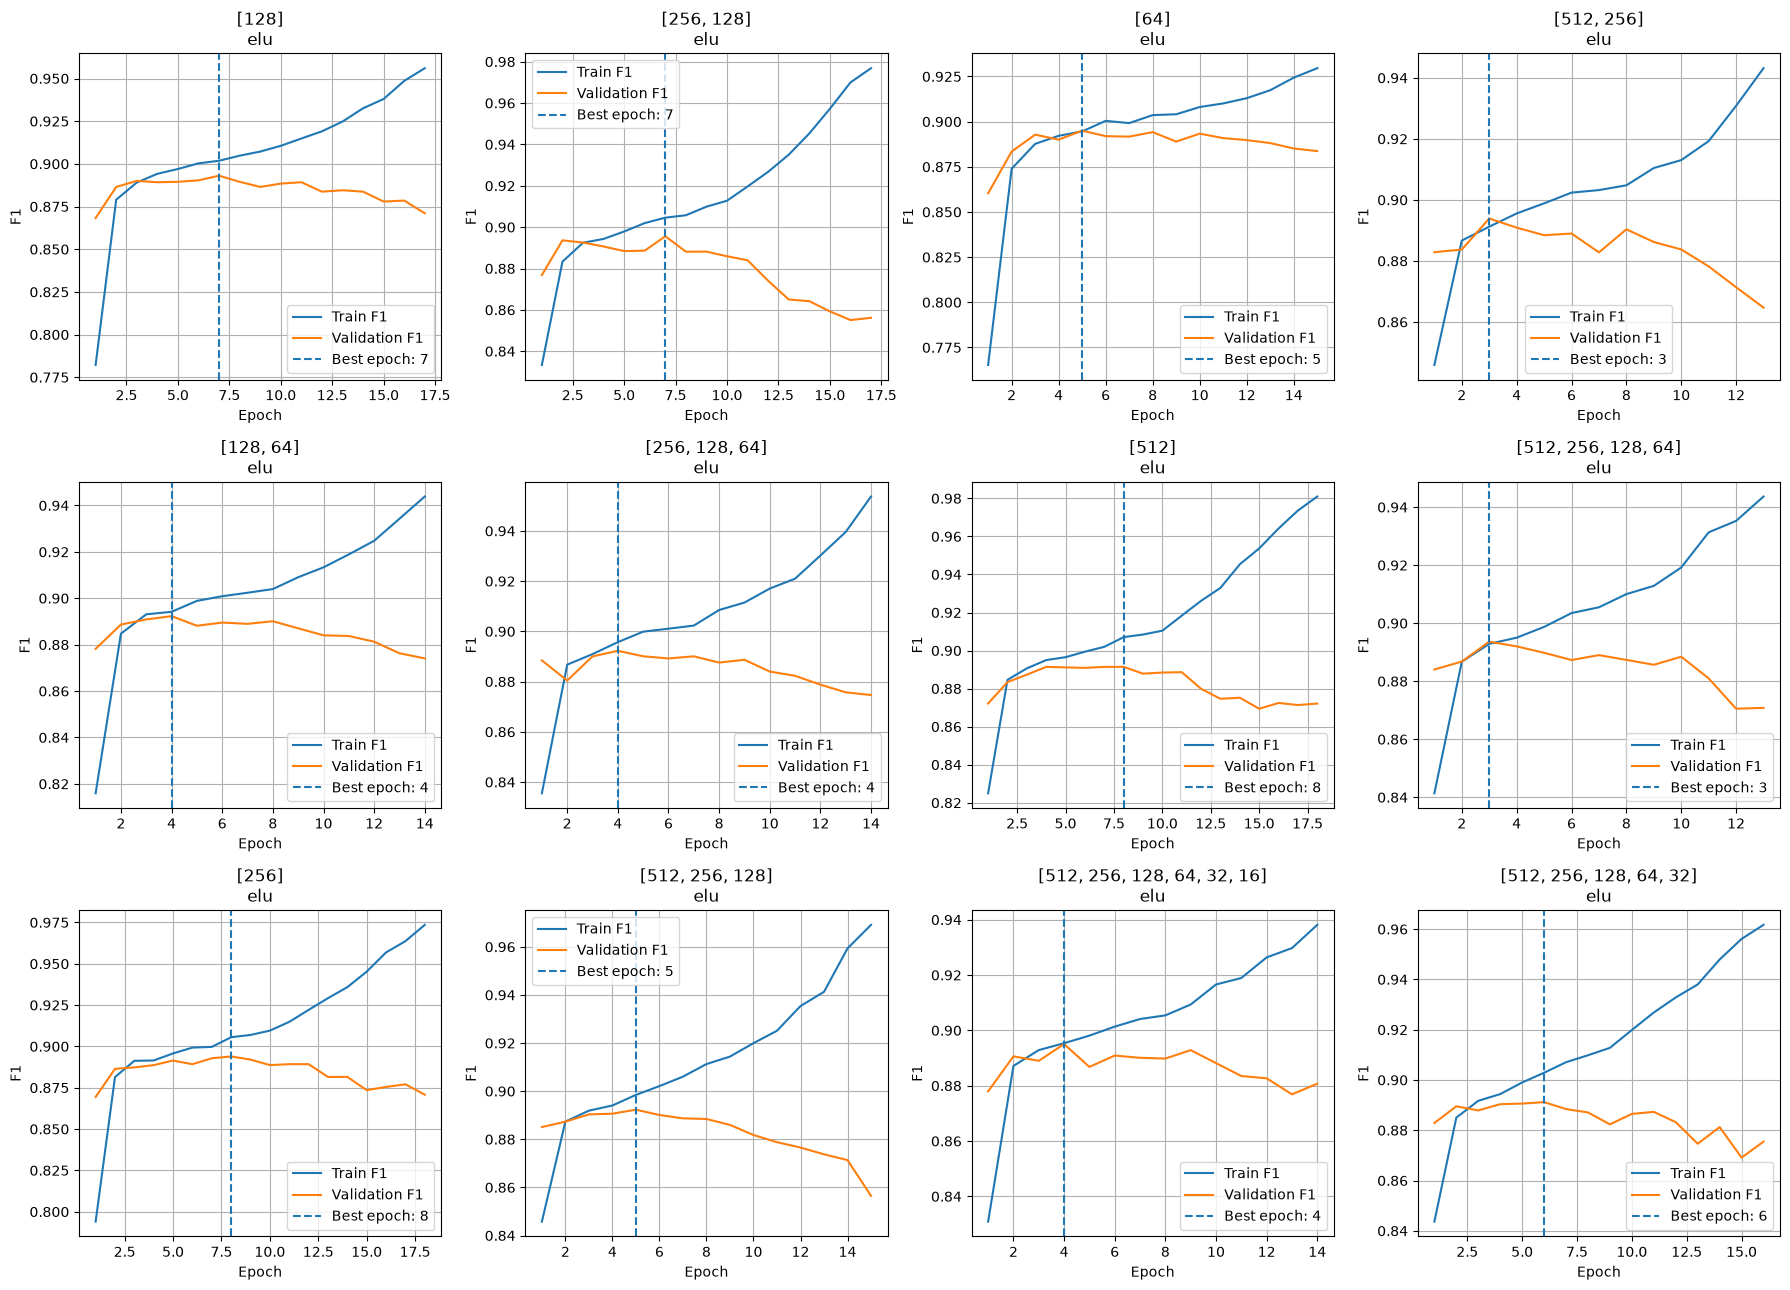

In [66]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(18, 13)
)

axes = axes.flatten()

for ax, (_, row) in zip(
    axes,
    best_architecture_configs.iterrows()
):

    config = next(
        config
        for config in architecture_configs
        if (
            str(config['hidden_layers'])
            == row['architecture']
            and config['activation']
            == row['activation']
        )
    )

    history = architecture_histories[
        config_key(config)
    ]

    epochs = range(
        1,
        len(
            history['train_f1']
        ) + 1
    )

    ax.plot(
        epochs,
        history['train_f1'],
        label='Train F1'
    )

    ax.plot(
        epochs,
        history['val_f1'],
        label='Validation F1'
    )

    ax.axvline(
        history['best_epoch'],
        linestyle='--',
        label=(
            f'Best epoch: '
            f'{history["best_epoch"]}'
        )
    )

    ax.set_title(
        f'{config["hidden_layers"]}\n'
        f'{config["activation"]}'
    )

    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

**Выводы по архитектуре и функции активации:**

- Лучший средний результат показала архитектура `[128]` с `ELU`: `F1 = 0.8879`.
- Архитектуры `[256, 128]` и `[64]` с `ELU` показали очень близкое качество, поэтому однозначного преимущества более сложной сети не наблюдается.
- `ELU` оказалась лучшей функцией активации практически для всех рассмотренных архитектур: конфигурации с ней заняли верхние позиции рейтинга.
- Увеличение глубины и числа нейронов само по себе не улучшает качество. Более глубокие сети без регуляризации в большинстве случаев уступают простой архитектуре с одним скрытым слоем.
- Для следующего этапа оставляю несколько архитектур разной сложности с `ELU`, чтобы проверить, изменится ли их соотношение после добавления регуляризации.

In [67]:
architecture_shortlist = [
    {
        'hidden_layers': [128],
        'activation': 'elu'
    },
    {
        'hidden_layers': [256, 128],
        'activation': 'elu'
    },
    {
        'hidden_layers': [512, 256, 128, 64],
        'activation': 'elu'
    }
]

Для проверки регуляризации оставляю три архитектуры разной сложности: простую `[128]`, среднюю `[256, 128]` и глубокую `[512, 256, 128, 64]`. Это позволит проверить, помогает ли регуляризация более сложным сетям сильнее, чем простой модели.

### Подбор регуляризации

Проверяю два способа регуляризации:
- `Dropout`, случайно отключающий часть нейронов во время обучения;
- `weight decay`, добавляющий L2-штраф на величину весов.

Остальные параметры пока остаются фиксированными. Для каждой из выбранных архитектур сравниваются одинаковые значения регуляризации.

In [68]:
dropout_values = [
    0.3,
    0.5,
    0.8
]

weight_decay_values = [
    0.0,
    1e-4
]

In [69]:
regularization_configs = []

for architecture_config in architecture_shortlist:

    for dropout in dropout_values:

        for weight_decay in weight_decay_values:

            regularization_configs.append({
                'hidden_layers':
                    architecture_config[
                        'hidden_layers'
                    ],
                'activation':
                    architecture_config[
                        'activation'
                    ],
                'dropout': dropout,
                'weight_decay':
                    weight_decay,
                'lr': 1e-3,
                'batch_size': 128
            })

In [70]:
regularization_results, regularization_nested_result, regularization_best_configs, regularization_histories = mlp_search_cv(
    df_early_game,
    regularization_configs
)

Outer fold 1/3
Best: {'hidden_layers': [256, 128], 'activation': 'elu', 'dropout': 0.8, 'weight_decay': 0.0, 'lr': 0.001, 'batch_size': 128} | Inner F1: 0.8913
Outer F1: 0.8926

Outer fold 2/3
Best: {'hidden_layers': [256, 128], 'activation': 'elu', 'dropout': 0.8, 'weight_decay': 0.0001, 'lr': 0.001, 'batch_size': 128} | Inner F1: 0.8918
Outer F1: 0.8921

Outer fold 3/3
Best: {'hidden_layers': [128], 'activation': 'elu', 'dropout': 0.8, 'weight_decay': 0.0001, 'lr': 0.001, 'batch_size': 128} | Inner F1: 0.8915
Outer F1: 0.8931



In [71]:
regularization_results.head(15).round(4)

,architecture,activation,dropout,weight_decay,lr,batch_size,f1_mean,f1_std
0,[128],elu,0.8,0.0001,0.001,128,0.8914,0.0023
1,"[256, 128]",elu,0.8,0.0001,0.001,128,0.8913,0.0021
2,"[256, 128]",elu,0.8,0.0000,0.001,128,0.8912,0.0022
3,"[512, 256, 128, 64]",elu,0.8,0.0000,0.001,128,0.8912,0.0025
4,"[512, 256, 128, 64]",elu,0.8,0.0001,0.001,128,0.8911,0.0022
5,[128],elu,0.8,0.0000,0.001,128,0.8911,0.0021
6,"[256, 128]",elu,0.5,0.0001,0.001,128,0.8898,0.0023
7,"[256, 128]",elu,0.5,0.0000,0.001,128,0.8896,0.0025
8,[128],elu,0.5,0.0000,0.001,128,0.8896,0.0024
9,[128],elu,0.5,0.0001,0.001,128,0.8893,0.0025


In [72]:
best_by_architecture = (
    regularization_results
    .sort_values(
        'f1_mean',
        ascending=False
    )
    .groupby(
        [
            'architecture',
            'activation'
        ],
        as_index=False
    )
    .first()
    .sort_values(
        'f1_mean',
        ascending=False
    )
    .reset_index(drop=True)
)

best_by_architecture.round(4)

,architecture,activation,dropout,weight_decay,lr,batch_size,f1_mean,f1_std
0,[128],elu,0.8,0.0001,0.001,128,0.8914,0.0023
1,"[256, 128]",elu,0.8,0.0001,0.001,128,0.8913,0.0021
2,"[512, 256, 128, 64]",elu,0.8,0.0000,0.001,128,0.8912,0.0025


In [73]:
regularization_best_configs.round(4)

,hidden_layers,activation,dropout,weight_decay,lr,batch_size,inner_f1
0,"[256, 128]",elu,0.8,0.0000,0.001,128,0.8913
1,"[256, 128]",elu,0.8,0.0001,0.001,128,0.8918
2,[128],elu,0.8,0.0001,0.001,128,0.8915


In [74]:
pd.DataFrame([
    {
        'model': 'MLP + regularization',
        **regularization_nested_result
    }
]).round(4)

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,training_time
0,MLP + regularization,0.8926,0.0005,0.8926,0.0005,0.8926,0.0005,0.8926,0.0005,0.8926,0.0005,0.9423,0.0014,2570.8638


In [75]:
best_regularization_configs = []

for _, row in best_by_architecture.iterrows():

    architecture = next(
        config['hidden_layers']
        for config in regularization_configs
        if (
            str(config['hidden_layers'])
            == row['architecture']
            and config['activation']
            == row['activation']
        )
    )

    best_regularization_configs.append({
        'hidden_layers': architecture,
        'activation': row[
            'activation'
        ],
        'dropout': row[
            'dropout'
        ],
        'weight_decay': row[
            'weight_decay'
        ],
        'lr': row['lr'],
        'batch_size': int(
            row['batch_size']
        )
    })

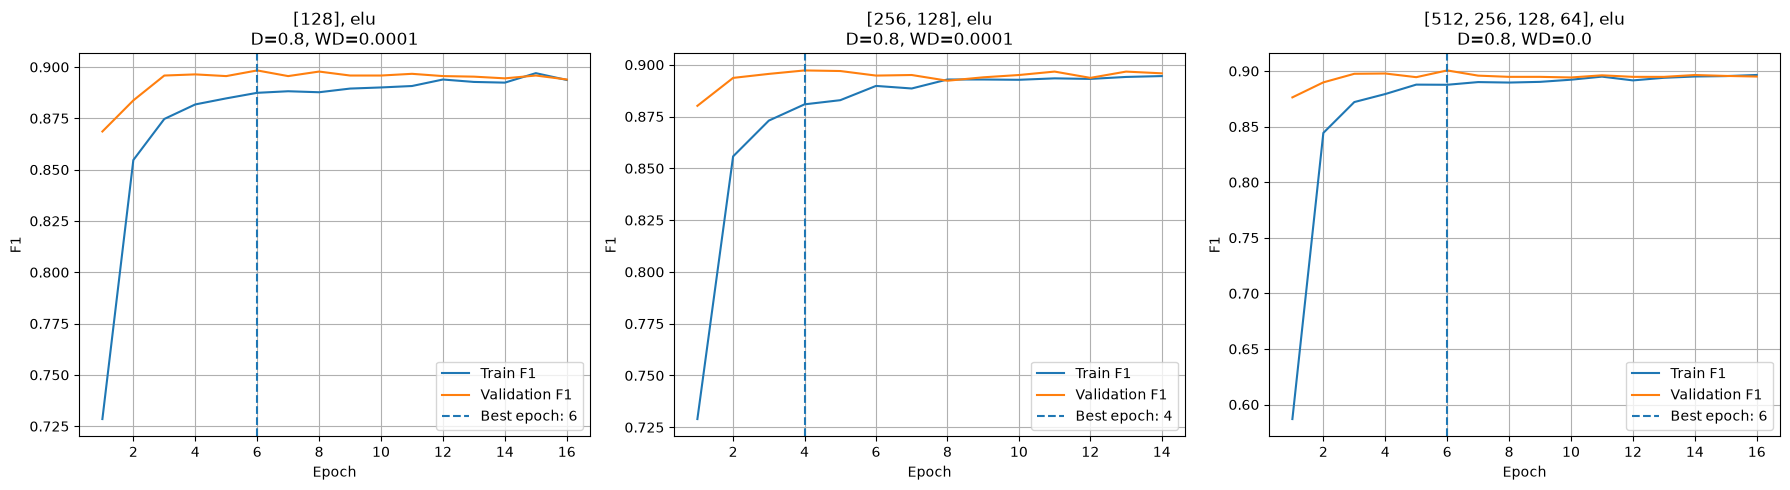

In [76]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, config in zip(
    axes,
    best_regularization_configs
):

    history = regularization_histories[
        config_key(config)
    ]

    epochs = range(
        1,
        len(
            history['train_f1']
        ) + 1
    )

    ax.plot(
        epochs,
        history['train_f1'],
        label='Train F1'
    )

    ax.plot(
        epochs,
        history['val_f1'],
        label='Validation F1'
    )

    ax.axvline(
        history['best_epoch'],
        linestyle='--',
        label=(
            f'Best epoch: '
            f'{history["best_epoch"]}'
        )
    )

    ax.set_title(
        f'{config["hidden_layers"]}, '
        f'{config["activation"]}\n'
        f'D={config["dropout"]}, '
        f'WD={config["weight_decay"]}'
    )

    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

**Выводы по регуляризации:**

Лучший средний результат показала конфигурация `[128] + ELU + Dropout 0.8 + weight decay 1e-4`: `F1 = 0.8914 ± 0.0023`. Почти такие же результаты получили `[256, 128]` (`0.8913`) и `[512, 256, 128, 64]` (`0.8912`).

Основной прирост даёт именно `Dropout = 0.8`: все лучшие варианты используют это значение, тогда как `0.5` и `0.3` располагаются ниже. Weight decay влияет слабее, разница между `0` и `1e-4` находится на уровне тысячных долей.

Nested CV после добавления регуляризации дал `F1 = 0.8926 ± 0.0005` против `0.8883 ± 0.0026` на этапе выбора архитектуры. То есть регуляризация дала небольшой, но стабильный прирост. Для следующих этапов фиксирую `[128]`, `ELU`, `Dropout = 0.8` и `weight_decay = 1e-4`.


### Подбор параметров оптимизации

После фиксации структуры сети и регуляризации проверяю `learning rate` и `batch size`.

Learning rate определяет величину обновления весов на каждом шаге оптимизатора, а batch size - количество объектов, используемых для одного такого обновления. Эти параметры могут заметно влиять как на качество, так и на скорость и стабильность обучения.

In [79]:
best_dropout = 0.8

optimization_configs = []

for lr in [
    3e-4,
    1e-3,
    3e-3
]:

    for batch_size in [
        64,
        128,
        256
    ]:

        optimization_configs.append({
            'hidden_layers': [128],
            'activation': 'elu',
            'dropout': best_dropout,
            'weight_decay': 1e-4,
            'lr': lr,
            'batch_size': batch_size
        })

In [83]:
optimization_results, optimization_nested_result, optimization_best_configs, optimization_histories = mlp_search_cv(
    df_early_game,
    optimization_configs
)

Outer fold 1/3
Best: {'hidden_layers': [128], 'activation': 'elu', 'dropout': 0.8, 'weight_decay': 0.0001, 'lr': 0.003, 'batch_size': 128} | Inner F1: 0.8913
Outer F1: 0.89

Outer fold 2/3
Best: {'hidden_layers': [128], 'activation': 'elu', 'dropout': 0.8, 'weight_decay': 0.0001, 'lr': 0.001, 'batch_size': 128} | Inner F1: 0.8917
Outer F1: 0.8899

Outer fold 3/3
Best: {'hidden_layers': [128], 'activation': 'elu', 'dropout': 0.8, 'weight_decay': 0.0001, 'lr': 0.001, 'batch_size': 128} | Inner F1: 0.8915
Outer F1: 0.8931



In [84]:
optimization_results.round(4)

,architecture,activation,dropout,weight_decay,lr,batch_size,f1_mean,f1_std
0,[128],elu,0.8,0.0001,0.0010,128,0.8914,0.0023
1,[128],elu,0.8,0.0001,0.0003,128,0.8910,0.0029
2,[128],elu,0.8,0.0001,0.0030,128,0.8909,0.0032
3,[128],elu,0.8,0.0001,0.0010,64,0.8907,0.0022
4,[128],elu,0.8,0.0001,0.0003,64,0.8907,0.0021
5,[128],elu,0.8,0.0001,0.0010,256,0.8906,0.0022
6,[128],elu,0.8,0.0001,0.0030,256,0.8904,0.0026
7,[128],elu,0.8,0.0001,0.0003,256,0.8903,0.0020
8,[128],elu,0.8,0.0001,0.0030,64,0.8893,0.0025


In [85]:
optimization_best_configs.round(4)

,hidden_layers,activation,dropout,weight_decay,lr,batch_size,inner_f1
0,[128],elu,0.8,0.0001,0.003,128,0.8913
1,[128],elu,0.8,0.0001,0.001,128,0.8917
2,[128],elu,0.8,0.0001,0.001,128,0.8915


In [86]:
pd.DataFrame([
    {
        'model': 'MLP optimization search',
        **optimization_nested_result
    }
]).round(4)

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,training_time
0,MLP optimization search,0.891,0.0018,0.891,0.0018,0.891,0.0018,0.891,0.0018,0.891,0.0018,0.942,0.0018,1604.7995


**Вывод по параметрам оптимизации:**

Лучший средний результат получен при `learning rate = 0.001` и `batch size = 128`: `F1 = 0.8914 ± 0.0023`. Остальные комбинации отличаются совсем немного: весь диапазон результатов находится примерно между `0.8893` и `0.8914`.

На внешних фолдах два раза выбирался `lr = 0.001`, один раз - `0.003`, при этом итоговая nested CV оценка составила `F1 = 0.8910 ± 0.0018`. Значит, после подбора архитектуры и регуляризации параметры оптимизации уже не дают заметного прироста.

Для финального прогона используется зафиксированная конфигурация `[128] + ELU + Dropout 0.8 + weight decay 1e-4 + lr 0.001 + batch size 64`. Вариант с batch size 64 отстаёт от лучшего всего на `0.0007 F1`, то есть разница находится внутри обычного разброса между фолдами.


На основе последовательных экспериментов фиксирую итоговую конфигурацию MLP. После этого гиперпараметры больше не подбираются, а выбранная сеть оценивается одинаково на трех наборах данных.

In [87]:
final_config = {
    'hidden_layers': [128],
    'activation': 'elu',
    'dropout': 0.8,
    'weight_decay': 1e-4,
    'lr': 1e-3,
    'batch_size': 64
}

### Итоговая оценка MLP

Для финального сравнения MLP использую 5-fold кросс-валидацию - столько же внешних фолдов, сколько использовалось для классических моделей.

Одна и та же выбранная конфигурация проверяется на `draft`, `early_game` и `full`. Это важно для основной гипотезы проекта: меняется только объем информации о матче, а не сама архитектура сети.

In [88]:
def final_mlp_cv(
    df,
    config,
    n_splits=5,
    max_epochs=100,
    patience=10
):

    X = df.drop(columns='winner')
    y = df['winner'].map({1: 0, 2: 1})

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    fold_results = []
    histories = []

    start_time = time.time()

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y),
        start=1
    ):

        print(f'Fold {fold}/{n_splits}')

        X_train_full = X.iloc[train_idx]
        y_train_full = y.iloc[train_idx]

        X_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full,
            y_train_full,
            test_size=0.2,
            stratify=y_train_full,
            random_state=42
        )

        model, scaler, history = fit_mlp(
            X_train,
            y_train,
            X_val,
            y_val,
            **config,
            max_epochs=max_epochs,
            patience=patience
        )

        X_test_scaled = scaler.transform(X_test)

        test_loader = DataLoader(
            TensorDataset(
                torch.tensor(X_test_scaled, dtype=torch.float32),
                torch.tensor(y_test.to_numpy(), dtype=torch.float32)
            ),
            batch_size=config['batch_size'],
            shuffle=False
        )

        metrics = evaluate(
            model,
            test_loader,
            nn.BCEWithLogitsLoss()
        )

        fold_results.append(metrics)
        histories.append(history)

    training_time = time.time() - start_time

    fold_results = pd.DataFrame(fold_results)

    result = {
        'accuracy_mean': fold_results['accuracy'].mean(),
        'accuracy_std': fold_results['accuracy'].std(),

        'balanced_accuracy_mean': fold_results['balanced_accuracy'].mean(),
        'balanced_accuracy_std': fold_results['balanced_accuracy'].std(),

        'precision_mean': fold_results['precision'].mean(),
        'precision_std': fold_results['precision'].std(),

        'recall_mean': fold_results['recall'].mean(),
        'recall_std': fold_results['recall'].std(),

        'f1_mean': fold_results['f1'].mean(),
        'f1_std': fold_results['f1'].std(),

        'roc_auc_mean': fold_results['roc_auc'].mean(),
        'roc_auc_std': fold_results['roc_auc'].std(),

        'training_time': training_time
    }

    return result, histories

In [89]:
mlp_draft_result, mlp_draft_histories = final_mlp_cv(
    df_draft,
    final_config
)

mlp_early_result, mlp_early_histories = final_mlp_cv(
    df_early_game,
    final_config
)

mlp_full_result, mlp_full_histories = final_mlp_cv(
    df_feature_max,
    final_config
)

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5


In [90]:
mlp_final_results = pd.DataFrame([
    {
        'dataset': 'draft',
        **mlp_draft_result
    },
    {
        'dataset': 'early_game',
        **mlp_early_result
    },
    {
        'dataset': 'full',
        **mlp_full_result
    }
])

mlp_final_results.round(4)

,dataset,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,training_time
0,draft,0.5458,0.0023,0.5450,0.0023,0.5454,0.0023,0.5450,0.0023,0.5444,0.0023,0.5682,0.0030,213.4141
1,early_game,0.8933,0.0014,0.8933,0.0014,0.8933,0.0014,0.8933,0.0014,0.8933,0.0014,0.9429,0.0022,244.9373
2,full,0.9675,0.0021,0.9675,0.0022,0.9676,0.0021,0.9675,0.0022,0.9675,0.0021,0.9969,0.0002,395.3828


In [91]:
final_history = mlp_early_histories[0]

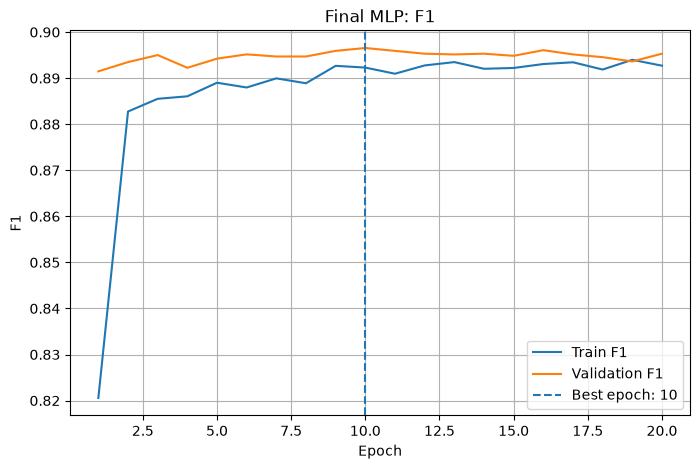

In [92]:
epochs = range(
    1,
    len(final_history['train_f1']) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    final_history['train_f1'],
    label='Train F1'
)

plt.plot(
    epochs,
    final_history['val_f1'],
    label='Validation F1'
)

plt.axvline(
    final_history['best_epoch'],
    linestyle='--',
    label=f'Best epoch: {final_history["best_epoch"]}'
)

plt.xlabel('Epoch')
plt.ylabel('F1')
plt.title('Final MLP: F1')
plt.legend()
plt.grid()

plt.show()

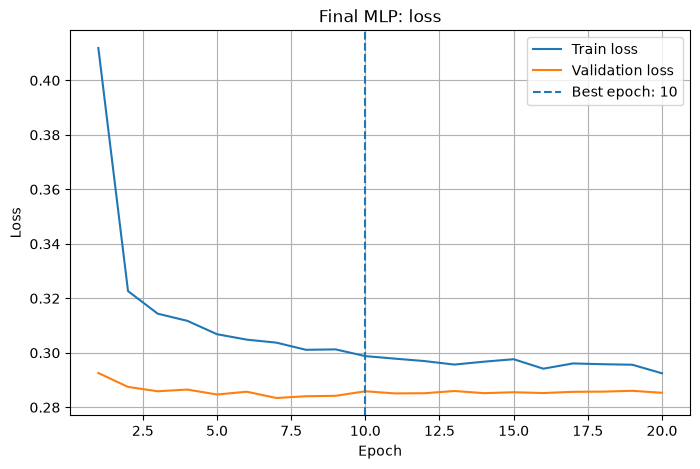

In [93]:
epochs = range(
    1,
    len(final_history['train_loss']) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    final_history['train_loss'],
    label='Train loss'
)

plt.plot(
    epochs,
    final_history['val_loss'],
    label='Validation loss'
)

plt.axvline(
    final_history['best_epoch'],
    linestyle='--',
    label=f'Best epoch: {final_history["best_epoch"]}'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final MLP: loss')
plt.legend()
plt.grid()

plt.show()

**Вывод по кривым обучения:**

На выбранном фолде лучший результат достигается примерно на `10` эпохе. После этого validation F1 остаётся почти на одном уровне около `0.895`, а validation loss также практически не растёт.

Сильного разрыва между train и validation нет, поэтому выраженного переобучения по этим кривым не видно. Validation F1 местами даже немного выше train F1, что нормально при сильном Dropout: во время обучения часть нейронов отключается, а на validation сеть работает целиком.

В целом выбранная регуляризация хорошо контролирует переобучение, а early stopping не даёт продолжать обучение после того, как качество перестаёт заметно улучшаться.


**Выводы по итоговой MLP:**

На `draft` MLP получает `F1 = 0.5444` и `ROC-AUC = 0.5682`, на `early_game` - `F1 = 0.8933` и `ROC-AUC = 0.9429`, на `full` - `F1 = 0.9675` и `ROC-AUC = 0.9969`.

Картина такая же, как у классических моделей: по одному драфту исход предсказывается слабо, после появления первых игровых событий качество резко растёт, а на полном наборе статистики становится близким к `0.97 F1`.

При этом MLP не стала лучшей ни на одном этапе. На `draft` Logistic Regression показывает `0.5485`, на `early_game` XGBoost - `0.9004`, на `full` XGBoost - `0.9705`. То есть для этих табличных данных более сложная нейросеть не дала преимущества над классическими моделями.


## Сравнение всех моделей

Объединяю уже полученные результаты в одну таблицу и выбираю лучшую модель отдельно для `draft`, `early_game` и `full`.

Главная метрика - `F1 macro`. ROC-AUC используется как дополнительная метрика. `RMSE` добавляю из-за требования задания и считаю по hard labels; для бинарной классификации он фактически равен корню из доли ошибок.

Время обучения в таблице нужно воспринимать как ориентир вычислительной стоимости: у классических моделей оно включает nested CV с подбором гиперпараметров, а у финальной MLP - только оценку уже фиксированной конфигурации, поэтому напрямую сравнивать эти значения как скорость самих алгоритмов некорректно.


In [94]:
baseline_full = baseline_results[
    baseline_results['dataset'] == 'feature_max'
].copy()
baseline_full['dataset'] = 'full'

comparison_parts = [
    baseline_full,
    new_baseline_results,
    catboost_results,
    xgboost_results,
    random_forest_results
]

if 'mlp_final_results' in globals():
    mlp_compare = mlp_final_results.copy()
    mlp_compare['model'] = 'MLP'
    comparison_parts.append(mlp_compare)

comparison_results = pd.concat(
    comparison_parts,
    ignore_index=True
)

comparison_results['rmse_mean'] = np.sqrt(
    1 - comparison_results['accuracy_mean']
)

comparison_results = comparison_results[
    [
        'dataset',
        'model',
        'accuracy_mean',
        'accuracy_std',
        'f1_mean',
        'f1_std',
        'rmse_mean',
        'roc_auc_mean',
        'roc_auc_std',
        'training_time'
    ]
].sort_values(
    ['dataset', 'f1_mean'],
    ascending=[True, False]
).reset_index(drop=True)

display(comparison_results.round(4))

best_models_cv = (
    comparison_results
    .sort_values(['dataset', 'f1_mean'], ascending=[True, False])
    .groupby('dataset', as_index=False)
    .first()
)

best_models_cv[
    ['dataset', 'model', 'f1_mean', 'roc_auc_mean', 'training_time']
].round(4)


,dataset,model,accuracy_mean,accuracy_std,f1_mean,f1_std,rmse_mean,roc_auc_mean,roc_auc_std,training_time
0,draft,LogisticRegression,0.5495,0.0038,0.5485,0.0038,0.6712,0.5721,0.0023,321.2288
1,draft,XGBoost,0.5473,0.0018,0.5454,0.0025,0.6729,0.5662,0.0022,264.1586
2,draft,MLP,0.5458,0.0023,0.5444,0.0023,0.6739,0.5682,0.0030,213.4141
3,draft,RandomForest,0.5426,0.0023,0.5424,0.0023,0.6763,0.5605,0.0044,2650.8070
4,draft,CatBoost,0.5441,0.0018,0.5416,0.0022,0.6752,0.5643,0.0020,1890.5643
5,draft,DecisionTree,0.5130,0.0046,0.5072,0.0111,0.6979,0.5185,0.0083,34.3339
6,early_game,XGBoost,0.9005,0.0019,0.9004,0.0019,0.3155,0.9580,0.0016,321.0114
7,early_game,RandomForest,0.8998,0.0030,0.8997,0.0030,0.3166,0.9565,0.0016,2986.2643
8,early_game,CatBoost,0.8986,0.0032,0.8986,0.0032,0.3184,0.9569,0.0023,1867.3731
9,early_game,DecisionTree,0.8955,0.0018,0.8955,0.0018,0.3232,0.9537,0.0014,22.5977


,dataset,model,f1_mean,roc_auc_mean,training_time
0,draft,LogisticRegression,0.5485,0.5721,321.2288
1,early_game,XGBoost,0.9004,0.9580,321.0114
2,full,XGBoost,0.9705,0.9974,378.7796


**Выводы по сравнению моделей:**

Для каждого этапа лучшая модель своя:
- `draft` - Logistic Regression, `F1 = 0.5485`, `ROC-AUC = 0.5721`;
- `early_game` - XGBoost, `F1 = 0.9004`, `ROC-AUC = 0.9580`;
- `full` - XGBoost, `F1 = 0.9705`, `ROC-AUC = 0.9974`.

MLP не выигрывает ни на одном из трёх наборов. На `early_game` она отстаёт от XGBoost примерно на `0.007 F1`, на `full` - на `0.003`, а на `draft` результат также немного ниже Logistic Regression.

Главный вывод из общей таблицы - выбор этапа матча влияет намного сильнее, чем выбор алгоритма. Переход от `draft` к `early_game` даёт прирост примерно на `0.35 F1`, тогда как разница между сильными моделями внутри одного этапа обычно составляет только тысячные доли.


## Финальная проверка на отложенной тестовой выборке

До этого момента `df_test` не используется для выбора признаков, моделей или гиперпараметров.

На финальном этапе ничего больше не подбирается. Для каждого набора используется своя заранее выбранная модель:
- `draft` - Logistic Regression;
- `early_game` - XGBoost;
- `full` - XGBoost.

Для XGBoost используются уже выбранные по nested CV конфигурации. Для Logistic Regression фиксируется тот же pipeline с `C = 1.0`, `L2`-регуляризацией и `liblinear`.

Каждая модель обучается один раз на всём соответствующем train-наборе и один раз проверяется на untouched test.


In [95]:
df_test_features = feature_engineer.transform(df_test)

df_test_draft = df_test_features.reindex(
    columns=df_draft.columns,
    fill_value=0
)

df_test_early_game = df_test_features.reindex(
    columns=df_early_game.columns,
    fill_value=0
)

df_test_full = df_test_features.reindex(
    columns=df_feature_max.columns,
    fill_value=0
)

assert list(df_test_draft.columns) == list(df_draft.columns)
assert list(df_test_early_game.columns) == list(df_early_game.columns)
assert list(df_test_full.columns) == list(df_feature_max.columns)

final_models = {
    'draft': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            C=1.0,
            penalty='l2',
            solver='liblinear',
            max_iter=2000,
            random_state=42
        ))
    ]),

    'early_game': XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.0312959438703224,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=0.6,
        reg_alpha=0.1668100537200059,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ),

    'full': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.04897180513671846,
        min_child_weight=5,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_alpha=10.0,
        reg_lambda=21.54434690031882,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
}

train_sets = {
    'draft': df_draft,
    'early_game': df_early_game,
    'full': df_feature_max
}

test_sets = {
    'draft': df_test_draft,
    'early_game': df_test_early_game,
    'full': df_test_full
}

cv_f1 = {
    'draft': 0.5485,
    'early_game': 0.9004,
    'full': 0.9705
}

model_names = {
    'draft': 'LogisticRegression',
    'early_game': 'XGBoost',
    'full': 'XGBoost'
}

final_results = []

for dataset_name in ['draft', 'early_game', 'full']:

    train_df = train_sets[dataset_name]
    test_df = test_sets[dataset_name]
    model = final_models[dataset_name]

    X_train = train_df.drop(columns='winner')
    y_train = train_df['winner'].map({1: 0, 2: 1})

    X_test = test_df.drop(columns='winner')
    y_test = test_df['winner'].map({1: 0, 2: 1})

    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    final_results.append({
        'dataset': dataset_name,
        'model': model_names[dataset_name],
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro'),
        'f1': f1_score(y_test, y_pred, average='macro'),
        'rmse': np.sqrt(np.mean((y_test.to_numpy() - y_pred) ** 2)),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'training_time': training_time,
        'cv_f1': cv_f1[dataset_name]
    })

final_test_results = pd.DataFrame(final_results)

final_test_results['f1_difference'] = (
    final_test_results['f1']
    - final_test_results['cv_f1']
)

final_test_results.round(4)


,dataset,model,accuracy,balanced_accuracy,precision,recall,f1,rmse,roc_auc,training_time,cv_f1,f1_difference
0,draft,LogisticRegression,0.5507,0.5509,0.5513,0.5509,0.5500,0.6703,0.5697,3.7089,0.5485,0.0015
1,early_game,XGBoost,0.8987,0.8988,0.8989,0.8988,0.8987,0.3182,0.9597,2.6579,0.9004,-0.0017
2,full,XGBoost,0.9711,0.9711,0.9711,0.9711,0.9711,0.1700,0.9976,3.5740,0.9705,0.0006


## Итоговый вывод

Финальная проверка на untouched test практически полностью подтвердила результаты кросс-валидации. Для `draft` Logistic Regression получила `F1 = 0.5500` против `0.5485` на CV (`+0.0015`). Для `early_game` XGBoost получила `0.8987` против `0.9004` (`-0.0017`), для `full` - `0.9711` против `0.9705` (`+0.0006`). Все отклонения меньше `0.002 F1`, поэтому оценка по CV получилась стабильной.

Основная гипотеза проекта подтвердилась. По одному `draft` исход матча предсказывается слабо: `F1 = 0.5500`, `ROC-AUC = 0.5697`. После появления первых игровых событий качество резко возрастает до `F1 = 0.8987` и `ROC-AUC = 0.9597`. На полном наборе статистики результат достигает `F1 = 0.9711` и `ROC-AUC = 0.9976`.

Финальными моделями стали Logistic Regression для `draft` и XGBoost для `early_game` и `full`. Более сложные модели внутри одного этапа давали очень близкие результаты, а MLP не смогла превзойти лучшие классические алгоритмы. Поэтому в этой задаче основное влияние на качество оказывает не сложность модели, а объём информации о ходе матча.

Финальное переобучение уже выбранных моделей на всём train заняло несколько секунд: около `3.7` секунды для Logistic Regression, `2.7` для XGBoost на `early_game` и `3.6` для XGBoost на `full`.
